# Modeling Spotify Track Hit Status

## 1. Introduction

Millions of tracks are streamed on Spotify every day, yet only a small fraction rise to broad popularity. With so much music competing for attention, it is often unclear why some tracks break through while others do not. Exploratory analysis identified audio traits, artist context, and categorical signals that are individually associated with hit outcomes. The next question is practical: when these features are combined, how well can we predict whether a track will be a hit?

This notebook builds on EDA by training and comparing multiple classification models on a binary hit target (top 20% popularity). Models are trained on a stratified split and compared across model families. Results are evaluated with ranking and classification metrics, threshold tuning, and error analysis to clarify where models are strong, where they degrade, and which signals remain most useful in practice.

## 2. Libraries

The libraries below support the full modeling workflow in this notebook, including data preparation, feature engineering, model training, evaluation, visualization, and experiment tracking.

In [1]:
# Standard library (Python built-ins)
# Purpose: file I/O, timing, serialization, warnings, and object copying
import os
import time
import json
import warnings
from copy import deepcopy

# Core data stack
# Purpose: arrays and dataframes
import numpy as np
import pandas as pd

# Serialization / caching
# Purpose: save and load models/objects
import joblib

# Visualization
# Purpose: plots, evaluation curves, and legend elements
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# Experiment tracking (MLflow)
# Purpose: log params, metrics, artifacts, and models
import mlflow
import mlflow.sklearn

# scikit-learn: data splitting & tuning
# Purpose: train/val splits, CV, hyperparameter search
from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    ParameterSampler
)

# scikit-learn: preprocessing & feature engineering
# Purpose: numeric scaling, categorical encoding, combined pipelines,
#          and text -> TF-IDF -> SVD embeddings (genre_doc)
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.base import clone

# scikit-learn: baseline + classical ML models
# Purpose: baselines and strong tabular benchmarks
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Gradient boosting
# Purpose: strong non-linear tabular model
from xgboost import XGBClassifier

# Deep Learning (PyTorch)
# Purpose: custom MLPs + tensor datasets/loaders
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler

# pytorch-tabular (TabNet + training wrapper)
# Purpose: TabNet model training with dataframe inputs
from pytorch_tabular import TabularModel
from pytorch_tabular.config import (
    DataConfig,
    TrainerConfig,
    OptimizerConfig
)
from pytorch_tabular.models.tabnet.config import TabNetModelConfig

# Optuna
# Purpose: hyperparameter optimization for deep learning
import optuna

# Evaluation metrics & diagnostics
# Purpose: classification metrics, ROC/PR curves, calibration checks
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    balanced_accuracy_score,
    auc,
    classification_report,
    confusion_matrix,
    f1_score,
    RocCurveDisplay,
    average_precision_score,
    PrecisionRecallDisplay,
    precision_score,
    brier_score_loss,
    precision_recall_curve,
    recall_score
)

# Calibration & probability analysis
# Purpose: calibrate predicted probabilities + reliability curves
from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve
)

# Model interpretation
# Purpose: permutation feature importance, global effect plots, and SHAP values
import shap
from sklearn.inspection import (
    permutation_importance,
    PartialDependenceDisplay
)

# Warning control
# Purpose: reduce noise during experiments
warnings.filterwarnings("ignore", module="sklearn")
warnings.filterwarnings("ignore", category=pd.errors.ChainedAssignmentError)
warnings.filterwarnings("ignore", ".*LeafSpec.*")
warnings.filterwarnings("ignore", ".*litlogger.*")

## 3. Configuration

This section defines global settings used throughout the notebook, including reproducibility controls, split settings, model defaults, and MLflow experiment setup.

In [2]:
# Reproducibility
RANDOM_STATE = 42          

# Data splitting
TEST_SIZE = 0.2            

# Target variable column name
TARGET_COL = "is_hit"

# Cross-validation
N_SPLITS = 3               

# Genre feature engineering
GENRE_COL = "artist_genres"  
N_COMPONENTS = 300       

# Evaluation & Threshold Tuning
DEFAULT_THRESHOLD = 0.5
THRESHOLDS = np.linspace(0.1, 0.9, 81)

# Model tracking parameters
MODEL_KEYS = {
    "logreg": ["model__solver", "model__max_iter", "model__class_weight"],
    "rf": ["model__n_estimators", "model__max_depth", "model__class_weight"],
    "xgb": ["model__n_estimators", "model__max_depth", "model__learning_rate", "model__scale_pos_weight"]
}

# Deep learning batch sizes
BATCH_SIZE_TRAIN = 256
BATCH_SIZE_EVAL = 512

In [3]:
# Initialize MLflow experiment
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("spotify-hit-modeling")

<Experiment: artifact_location='/Users/itssel/Desktop/spotify-popularity-prediction/mlruns/1', creation_time=1772162313856, experiment_id='1', last_update_time=1772162313856, lifecycle_stage='active', name='spotify-hit-modeling', tags={}, workspace='default'>

## 4. Helper Functions 
This section defines reusable utility functions used across modeling workflows. These helpers keep training and evaluation code concise, reduce duplication, and ensure consistent logic for tasks such as threshold tuning and metric reporting.

- `pick_params`: extracts pipeline parameters for MLflow logging
- `evaluate_fitted_model`: end-to-end evaluation for sklearn-compatible models
- `compute_pos_weight`: computes class imbalance weight for loss scaling
- `predict_proba_loader`: runs batch inference on PyTorch models
- `evaluate_from_proba`: evaluates classification performance from pre-computed probabilities
- `make_tensor_loaders`: builds PyTorch DataLoaders from numpy arrays
- `set_seeds`: sets random seeds for reproducible training runs

In [4]:
def pick_params(pipe, keys):
    """
    Extracts model-specific parameter values from a fitted sklearn pipeline for MLflow logging.
    Keys come from MODEL_KEYS for the given model type (e.g. MODEL_KEYS["logreg"]).
    Only keys present in the pipeline's parameter space are included.
    """
    p = pipe.get_params(deep=True)
    return {k: p[k] for k in keys if k in p}

In [5]:
def evaluate_fitted_model(
    model, 
    X_eval, 
    y_eval, 
    threshold=DEFAULT_THRESHOLD, 
    model_name="model", 
    split_name="validation",
    verbose=True
):
    """
    Evaluates a fitted sklearn-compatible model on a labeled dataset.
    Threshold defaults to DEFAULT_THRESHOLD (0.5). Adjust to tune precision/recall tradeoff.
    With verbose=True (default), prints metrics and diagnostics to console. Set verbose=False to suppress.
    Returns a metrics DataFrame and a details dict with report, confusion matrix, and predictions.
    """
    y_proba = model.predict_proba(X_eval)[:, 1]
    y_pred = (y_proba >= threshold).astype(int)

    # Get metrics
    pr_auc = average_precision_score(y_eval, y_proba)
    roc_auc = roc_auc_score(y_eval, y_proba)
    weighted_f1 = f1_score(y_eval, y_pred, average="weighted", zero_division=0)

    # Create metrics dataframe
    metrics_df = pd.DataFrame([{
        "model": model_name,
        "split": split_name,
        "threshold": threshold,
        "pr_auc": pr_auc,
        "roc_auc": roc_auc,
        "weighted_f1": weighted_f1,
    }])
    
    safe_model_name = model_name.lower().replace(" ", "_")
    classification_report_df = pd.DataFrame(
            classification_report(y_eval, y_pred, digits=3, zero_division=0, output_dict=True)
        ).T.round(3)
    conf_matrix = confusion_matrix(y_eval, y_pred)
    
    details = {
        "report_df": classification_report_df,
        "confusion_matrix": conf_matrix,
        f"y_proba_{safe_model_name}": y_proba,
        f"y_pred_{safe_model_name}": y_pred
    }

    if verbose:
        print(f"PR-AUC: {pr_auc}")
        print(f"ROC-AUC: {roc_auc}")
        print(f"Weighted F1: {weighted_f1}")
        print(classification_report_df)
        print("Confusion matrix:\n", conf_matrix)
    
    return metrics_df, details

In [6]:
def compute_pos_weight(y_train_np):
    """
    Returns n_neg / n_pos as the positive class weight for loss scaling.
    Uses max(n_pos, 1) to avoid division by zero if no positive samples are present.
    """
    n_pos = int((np.asarray(y_train_np) == 1).sum())
    n_neg = int((np.asarray(y_train_np) == 0).sum())
    return n_neg / max(n_pos, 1)

In [7]:
def predict_proba_loader(model, loader, device):
    """
    Runs inference on a PyTorch model using a DataLoader and returns positive-class probabilities.
    Applies sigmoid to raw logits and concatenates results across all batches.
    """
    # put PyTorch model in evaluation mode
    model.eval()
    probs = []
    # disable gradient calculations for inference
    with torch.no_grad():
        for xb, _ in loader:
            # move x batch to the specified device (CPU or GPU)
            xb = xb.to(device)
            # get raw logits from the model
            logits = model(xb)
            # apply sigmoid to get probabilities, move to CPU, and convert to numpy array
            probs.append(torch.sigmoid(logits).cpu().numpy())
    return np.concatenate(probs)

In [8]:
def evaluate_from_proba(y_true, y_proba, threshold=DEFAULT_THRESHOLD):
    """
    Evaluates classification performance from pre-computed predicted probabilities.
    Used for PyTorch and TabNet models that generate probabilities outside sklearn pipelines.
    Returns a metrics dict, classification report DataFrame, confusion matrix, and predicted labels.
    """
    # convert probabilities to binary labels using threshold
    y_pred = (y_proba >= threshold).astype(int)
    metrics = {
        # primary metric, threshold-independent
        "pr_auc": average_precision_score(y_true, y_proba),
        # supplementary metric, threshold-independent
        "roc_auc": roc_auc_score(y_true, y_proba),
        # secondary metric, threshold-dependent
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    }
    # per-class breakdown of precision, recall, f1; transposed and rounded for readability
    report_df = pd.DataFrame(
        classification_report(y_true, y_pred, digits=3, zero_division=0, output_dict=True)
    ).T.round(3)
    cm = confusion_matrix(y_true, y_pred)
    return metrics, report_df, cm, y_pred

In [9]:
def make_tensor_loaders(
    X_train_mlp, y_train,
    X_val_mlp, y_val,
    X_test_mlp=None, y_test=None,
    batch_size_train=256,
    batch_size_eval=512,
):
    """
    Converts numpy arrays into PyTorch TensorDatasets and wraps them in DataLoaders.
    Returns train, validation, and optionally test loaders ready for MLP training.
    """
    # Convert training data to PyTorch tensors
    X_train_t = torch.tensor(X_train_mlp, dtype=torch.float32)
    y_train_t = torch.tensor(np.asarray(y_train), dtype=torch.float32) # np.asarray to ensure it's a numpy array before converting to tensor

    # Convert validation data to PyTorch tensors
    X_val_t = torch.tensor(X_val_mlp, dtype=torch.float32)
    y_val_t = torch.tensor(np.asarray(y_val), dtype=torch.float32) # np.asarray to ensure it's a numpy array before converting to tensor

    # Zip features and labels into TensorDatasets
    train_ds = TensorDataset(X_train_t, y_train_t)
    val_ds = TensorDataset(X_val_t, y_val_t)

    # Wrap datasets in DataLoaders for batching and shuffling
    train_loader = DataLoader(train_ds, batch_size=batch_size_train, shuffle=True) 
    val_loader = DataLoader(val_ds, batch_size=batch_size_eval, shuffle=False) 

    # test loader is None by default; only built if test data is passed in
    test_loader = None
    if X_test_mlp is not None and y_test is not None:
        X_test_t = torch.tensor(X_test_mlp, dtype=torch.float32)
        y_test_t = torch.tensor(np.asarray(y_test), dtype=torch.float32)
        test_ds = TensorDataset(X_test_t, y_test_t)
        test_loader = DataLoader(test_ds, batch_size=batch_size_eval, shuffle=False)

    return train_loader, val_loader, test_loader

In [10]:
def set_seeds(seed):
    """
    Sets random seeds for PyTorch and NumPy to ensure reproducible training runs.
    """
    torch.manual_seed(seed)
    np.random.seed(seed)

## 5. Load Data
The enriched dataset is loaded from the parquet file produced in the wrangling notebook.

In [11]:
df = pd.read_parquet("tracks_enriched_modeling.parquet")
df.shape

(528514, 25)

In [12]:
# verify dtypes and null counts 
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 528514 entries, 0 to 528513
Data columns (total 25 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   explicit                   528514 non-null  Int64  
 1   danceability               528514 non-null  float64
 2   energy                     528514 non-null  float64
 3   key                        528514 non-null  Int64  
 4   loudness                   528514 non-null  float64
 5   mode                       528514 non-null  Int64  
 6   speechiness                528514 non-null  float64
 7   acousticness               528514 non-null  float64
 8   instrumentalness           528514 non-null  float64
 9   liveness                   528514 non-null  float64
 10  valence                    528514 non-null  float64
 11  tempo                      528514 non-null  float64
 12  time_signature             528514 non-null  Int64  
 13  release_year               528514 non-nu

The dataset contains 528,514 tracks across 25 columns, consistent with the final state of the EDA notebook. No missing values were detected.

## 6. Target Definition and Class Balance
No universal definition of a "hit" exists in the industry or academic literature, and thresholds vary across studies. A track is labeled as a "hit" if its popularity score falls in the top 20% of the dataset, selected as an informed but acknowledged arbitrary cutoff that balances class representation with the intuition that mainstream success is not the norm.

In [13]:
# Check class balance
df[TARGET_COL].value_counts(normalize=True).rename({0:"Non‑hit", 1:"Hit"})

is_hit
Non‑hit    0.795328
Hit        0.204672
Name: proportion, dtype: float64

**Class Distribution Observations**
- `Non-hit`: 79.53%
- `Hit`: 20.47%

This moderate imbalance is handled in modeling with class-aware methods, including class weighting and threshold tuning.

## 7. Feature Preparation and Split

This section prepares modeling inputs by creating the engineered genre text representation, defining feature groups, and splitting the data into train, validation, and test sets for evaluation.

### 7.1 Feature Engineering: Genre Text

Genre lists are converted into a text representation (`genre_doc`) so they can be modeled with TF-IDF alongside numeric and categorical features.

In [14]:
def to_genre_doc(g):
    """
    Converts a list of genre tags into a single whitespace-separated string for TF-IDF input.
    Genres are lowercased and spaces replaced with underscores to treat multi-word genres as single tokens.
    Returns an empty string if the input is not a valid list-like structure.
    """
    if not isinstance(g, (list, tuple, set, np.ndarray)):
        return ""
    tokens = [
        str(x).strip().lower().replace(" ", "_")
        for x in g
        if pd.notna(x) and str(x).strip()
    ]
    return " ".join(tokens)

df["genre_doc"] = df[GENRE_COL].apply(to_genre_doc)

### 7.2 Feature Groups

To support a mixed-modality modeling pipeline, features are organized into three groups:  
- **Token/Text feature** (`genre_doc`) for TF-IDF-based genre representation  
- **Categorical features** for encoded structural and metadata signals  
- **Numeric features** for audio, temporal, artist-context, and aggregated genre-breadth information  

These groups are combined into `FEATURE_COLS` and used consistently across model pipelines to keep preprocessing explicit and reproducible.

In [15]:
token_feature = ["genre_doc"]

categorical_features = [
    "explicit",
    "key",
    "mode",
    "time_signature",
    "has_genre_metadata",
]

numeric_features = [
    # audio features
    "danceability",
    "energy",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",

    # track features
    "release_year",
    "log_n_artists",
    "log_duration_min",

    # Artist context 
    "artist_popularity_mean",
    "log_artist_followers_mean",
    "artist_genres_max"
]

FEATURE_COLS = categorical_features + numeric_features + token_feature

### 7.3 Train-Test Split
The dataset is split in a stratified manner to preserve class balance across the training (60%), validation (20%), and test (20%) sets. This split is used as the primary benchmark for model comparison. A two-stage approach is used: the test set is held out from the full dataset first, and the remaining data is then split into training and validation sets so that model selection and tuning can be performed without leaking information from the test set.

In [16]:
X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].astype(int)

print("X shape:", X.shape)
print("Hit rate:", y.mean())

X shape: (528514, 21)
Hit rate: 0.20467196706236732


In [17]:
# Stage 1: hold out test set from the full dataset
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    stratify=y,
    random_state=RANDOM_STATE
)

# Stage 2: split remaining data into train and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.25, # 25% of 80% = 20%
    stratify=y_train_full,
    random_state=RANDOM_STATE
)

# Sanity Checks
print("Train hit rate:", y_train.mean())
print("Val hit rate:", y_val.mean())
print("Test hit rate:", y_test.mean())
print("Raw Shapes:", X_train.shape, X_val.shape, X_test.shape)

Train hit rate: 0.20467159453561562
Val hit rate: 0.20467725608544696
Test hit rate: 0.20466779561601847
Raw Shapes: (317108, 21) (105703, 21) (105703, 21)


The resulting training, validation, and test sets maintain consistent class balance, providing a reliable foundation for model training and comparison. Subsequent sections focus on preprocessing and model development using the training data, with model selection and threshold tuning on validation and final reporting on the held-out test set.

## 8. Preprocessing Pipelines

This section defines the preprocessing pipelines used for each model. Because genre features are represented with TF‑IDF and some models require dense inputs, the genre transformation uses shared settings across pipelines and is paired with dimensionality reduction when needed.

### 8.1 Genre TF-IDF and SVD

TF-IDF converts genre text into numeric features by assigning higher weight to genres that are less common across the corpus. This can produce a high-dimensional feature space. Truncated SVD is used where needed to compress those features into a smaller set of components that retain core genre structure while keeping inputs manageable. Each TF-IDF/SVD transformer is fit only on the training data within its pipeline, which helps prevent information leakage into validation or test sets.

In [18]:
# Parameters sourced from an XGBoost hyperparameter search conducted during earlier experimentation.
# MLflow tracking was not in place at the time, so the search is not reproduced here.
GENRE_TFIDF_KW = dict(
    tokenizer=str.split,      # split genre_doc on whitespace
    token_pattern=None,       # disabled in favour of custom tokenizer above
    preprocessor=None,        # no additional text cleaning, genre_doc is already normalized
    lowercase=False,          # genres already lowercased in to_genre_doc
    min_df=3,                 # ignore genres that appear in fewer than 3 tracks
    max_features=2000,        # cap vocabulary size to limit dimensionality
    max_df=0.8,               # ignore genres that appear in more than 80% of tracks
    ngram_range=(1,1),        # unigrams only, genre tags are already meaningful as single tokens
    sublinear_tf=False,       # raw term frequency used, no log scaling
    strip_accents='unicode',  # normalize accented characters
    norm='l1',                # L1 normalize so genre weights sum to 1 per track
    use_idf=False,            # IDF disabled, raw term frequency only
    binary=False              # raw counts used, not binary presence/absence
)

# for dense input models (RF & MLP)
def make_genre_tfidf_svd():
    return Pipeline([
        ("tfidf", TfidfVectorizer(**GENRE_TFIDF_KW)),
        ("svd", TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)),
    ])

### 8.2 Logistic Regression Preprocessing Pipeline

Logistic regression benefits from standardized numeric features because scaling improves optimization and keeps coefficient magnitudes comparable. Categorical variables are one-hot encoded, and `handle_unknown="ignore"` ensures unseen categories in validation or test data do not break the pipeline. Genre text is represented with TF-IDF to convert tokenized genre strings into sparse numeric features. `remainder="drop"` keeps the input feature space explicit and excludes unused columns from modeling.

In [19]:
preprocess_for_logreg = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("genre", TfidfVectorizer(**GENRE_TFIDF_KW), "genre_doc")
    ],
    remainder="drop"
)

### 8.3 Random Forest Preprocessing Pipeline

Random Forest does not require feature scaling, so numeric variables are passed through unchanged.  Categorical variables are one-hot encoded, and the pipeline is configured to produce dense outputs for consistency with the genre branch. Genre text is transformed with TF-IDF and reduced with Truncated SVD to provide a compact dense representation. `sparse_threshold=0.0` enforces a fully dense final matrix to keep model inputs consistent.

In [20]:
preprocess_for_rf = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("genre", make_genre_tfidf_svd(), "genre_doc")
    ],
    remainder="drop",
    sparse_threshold=0.0
)

### 8.4 XGBoost Preprocessing Pipeline

XGBoost handles sparse inputs efficiently, so numeric features are passed through unchanged, categorical features are one-hot encoded, and genre text is represented directly with TF-IDF without SVD compression. As in other pipelines, `handle_unknown="ignore"` keeps categorical encoding robust to unseen values in validation and test data, and `remainder="drop"` restricts the model to the intended feature set.

In [21]:
preprocess_for_xgb = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("genre", TfidfVectorizer(**GENRE_TFIDF_KW), "genre_doc")
    ],
    remainder="drop"
)

### 8.5 MLP Preprocessing Pipeline

Neural networks are sensitive to feature scale, so numeric features are standardized. Categorical features are one-hot encoded and kept dense because the MLP expects dense input. Genre text is transformed with TF-IDF and reduced with SVD to create a compact dense representation. `sparse_threshold=0.0` ensures the combined output is fully dense and directly compatible with PyTorch tensors.

In [22]:
preprocess_for_mlp = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
        ("genre", make_genre_tfidf_svd(), "genre_doc")
    ],
    remainder="drop",
    sparse_threshold=0.0
)

## 9. Baseline Models
This section establishes baseline performance for comparison with more complex models. Baselines help verify that later gains come from real predictive signals rather than added model complexity. This section includes two baseline models: a Dummy classifier and Logistic Regression.


### 9.1 Dummy Baseline

A dummy classifier is used as a baseline to establish a minimum performance benchmark based solely on class distribution.

In [23]:
# no preprocessing needed as the dummy classifier ignores all features
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

dummy_metrics_df, dummy_details = evaluate_fitted_model(
    dummy, 
    X_test, 
    y_test, 
    model_name="dummy_baseline",
    split_name="test",
    verbose=True
)

PR-AUC: 0.20466779561601847
ROC-AUC: 0.5
Weighted F1: 0.704664366612113
              precision  recall  f1-score     support
0                 0.795   1.000     0.886   84069.000
1                 0.000   0.000     0.000   21634.000
accuracy          0.795   0.795     0.795       0.795
macro avg         0.398   0.500     0.443  105703.000
weighted avg      0.633   0.795     0.705  105703.000
Confusion matrix:
 [[84069     0]
 [21634     0]]


##### Dummy Classifier Observations
- PR-AUC of 0.205 is at the random baseline, confirming the model has no ability to rank hits above non-hits.
- ROC-AUC of 0.500 indicates random discrimination, the model cannot separate hits from non-hits across any threshold.
- Weighted F1 of 0.705 appears moderate but is entirely driven by majority class performance and class imbalance, not real predictive ability.
- Non-hit precision of 0.795 and perfect recall of 1.000 simply reflect the model predicting every track as a non-hit, which is correct 79.5% of the time by chance alone.
- Hit precision and recall are both 0.000, meaning the model never predicts a hit. It has learned nothing about the positive class.

### 9.2 Logistic Regression

Logistic regression provides a strong linear baseline for classification. It assumes additive relationships between features and the target, making it a useful benchmark to assess how much predictive power comes from linear effects before moving to more complex models. This section covers a baseline run, hyperparameter tuning via `RandomizedSearchCV`, and decision threshold tuning to optimize the precision-recall tradeoff.

#### 9.2.1 Logistic Regression Baseline

##### Build Baseline Pipeline

In [24]:
logreg_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess_for_logreg),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            solver="saga", # supports l1, l2, and elasticnet penalties
            n_jobs=-1
        ))
    ]
)

##### Configure Logistic Regression Baseline Run Metadata

In [25]:
# Params from pipeline
logreg_params = pick_params(logreg_pipeline, MODEL_KEYS["logreg"])
logreg_params.update({
    "model_name": "logreg",
    "split_type": "stratified",
    "test_size": TEST_SIZE,
    "default_threshold": DEFAULT_THRESHOLD,
    "tfidf_min_df": GENRE_TFIDF_KW["min_df"],
    "tfidf_max_df": GENRE_TFIDF_KW["max_df"],
    "tfidf_max_features": GENRE_TFIDF_KW["max_features"],
    "tfidf_ngram_range": str(GENRE_TFIDF_KW["ngram_range"]),
})

##### Train, Evaluate, and Log Logistic Regression Baseline to MLflow

In [26]:
with mlflow.start_run(run_name="logreg_baseline"):
    mlflow.log_params(logreg_params)

    # Fit on train
    logreg_pipeline.fit(X_train, y_train)

    # Evaluate via helper 
    logreg_metrics_df, logreg_details = evaluate_fitted_model(
        model=logreg_pipeline,
        X_eval=X_test,
        y_eval=y_test,
        threshold=DEFAULT_THRESHOLD,
        model_name="logreg",
        split_name="test",
        verbose=True
    )
    
    # Log scalar metrics
    logreg_metric_row = logreg_metrics_df.iloc[0].to_dict()
    mlflow.log_metrics({
        "pr_auc": logreg_metric_row["pr_auc"],
        "roc_auc": logreg_metric_row["roc_auc"],
        "weighted_f1": logreg_metric_row["weighted_f1"]
        })
    
    # Log model artifact
    model_info = mlflow.sklearn.log_model(
        sk_model=logreg_pipeline, 
        name="logreg_model",
        serialization_format="cloudpickle"
    )
    
    mlflow.set_tag("run_note", "Logistic Regression Baseline")


2026/04/18 21:14:08 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


PR-AUC: 0.7421894914277605
ROC-AUC: 0.910090853198037
Weighted F1: 0.8324996713070308
              precision  recall  f1-score    support
0                 0.951   0.816     0.878   84069.00
1                 0.539   0.835     0.655   21634.00
accuracy          0.820   0.820     0.820       0.82
macro avg         0.745   0.826     0.767  105703.00
weighted avg      0.866   0.820     0.832  105703.00
Confusion matrix:
 [[68604 15465]
 [ 3568 18066]]


##### Logistic Regression Baseline Observations
- PR-AUC of 0.742 indicates moderate ability to rank hits above non-hits, well above the 0.20 random baseline but with room to improve.
- ROC-AUC of 0.910 indicates strong overall separation between hits and non-hits across thresholds, though this is likely optimistic due to the large negative class.
- Weighted F1 of 0.832 indicates the model performs well overall at the default threshold of 0.5, though this is partially carried by strong non-hit performance.
- Non-hit precision of 0.951 is exceptional. The model is very cautious about predicting non-hits, only doing so when highly confident. However, recall of 0.816 means some non-hits are incorrectly swept up into hit predictions.
- Hit recall of 0.835 is strong, meaning the model captures most actual hits. However, precision of 0.539 is poor. The model loosely predicts hits, resulting in roughly half of predicted hits being false alarms, a direct consequence of `class_weight="balanced"` aggressively pushing toward hit detection.

#### 9.2.2 Logistic Regression Hyperparameter Tuning

##### Define Logistic Regression Hyperparameter Space

In [27]:
logreg_param_distributions = {
    "model__C": [0.01, 0.1, 1.0, 10.0, 100.0],         # regularization strength; smaller = stronger regularization
    "model__penalty": ["l1", "l2", "elasticnet"],      # l1 for sparsity, l2 for shrinkage, elasticnet for both  
    "model__class_weight": ["balanced", None],         # balanced adjusts for class imbalance automatically
    "model__l1_ratio": [0.3, 0.5, 0.7],                # elasticnet mixing ratio; only used when penalty=elasticnet 
}

##### Define CV Strategy

In [28]:
cv = StratifiedKFold(
    n_splits=5, # 5 folds here vs N_SPLITS=3 for heavier models; logistic regression is cheap enough to support more folds
    shuffle=True,
    random_state=RANDOM_STATE
)

##### Configure `RandomizedSearchCV` 

In [29]:
logreg_search = RandomizedSearchCV(
    estimator=logreg_pipeline,
    param_distributions=logreg_param_distributions,
    n_iter=8,                    # 8 iterations took ~125 minutes due to dataset size; increase with caution
    scoring="average_precision", # PR-AUC
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=False
)

##### Run and Log to MLflow
Due to the training time of approximately 125 minutes, the next cell has been commented out after the initial run. The tuned model is reloaded from the saved artifact in the next section.

In [30]:
'''with mlflow.start_run(run_name="logreg_random_search_tuning"):
    # Log search config
    mlflow.log_params({
        "model_name": "logreg",
        "split_type": "stratified",
        "search_type": "RandomizedSearchCV",
        "scoring": "average_precision",
        "cv_folds": 5,
        "n_iter": 8,
        "test_size": TEST_SIZE,
        "tfidf_min_df": GENRE_TFIDF_KW["min_df"],
        "tfidf_max_df": GENRE_TFIDF_KW["max_df"],
        "tfidf_ngram_range": str(GENRE_TFIDF_KW["ngram_range"]),
    })
    start_time = time.time()
    logreg_search.fit(X_train, y_train)
    end_time = time.time()
    tuning_minutes = (end_time - start_time) / 60
    mlflow.log_metric("tuning_minutes", float(tuning_minutes))
    print(f"Tuning took {tuning_minutes:.2f} minutes")

    best_logreg_model = logreg_search.best_estimator_
    print("Best params:", logreg_search.best_params_)
    mlflow.log_metric("best_cv_pr_auc", float(logreg_search.best_score_))
    mlflow.log_params({f"best_{k}": v for k, v in logreg_search.best_params_.items()})

    # Evaluate default threshold on validation for baseline
    val_default_df, val_default_details = evaluate_fitted_model(
        model=best_logreg_model,
        X_eval=X_val,
        y_eval=y_val,
        threshold=DEFAULT_THRESHOLD,
        model_name="logreg",
        split_name="val_default",
        verbose=True
    )
    row = val_default_df.iloc[0]
    mlflow.log_metrics({
        "val_pr_auc_default": float(row["pr_auc"]),
        "val_roc_auc_default": float(row["roc_auc"]),
        "val_weighted_f1_default": float(row["weighted_f1"]),
    })

    # Save local artifacts
    joblib.dump(logreg_search, "logreg_random_search.pkl")
    joblib.dump(best_logreg_model, "logreg_best_model.pkl")
    # Log artifacts
    mlflow.log_artifact("logreg_random_search.pkl")
    mlflow.log_artifact("logreg_best_model.pkl")
    # Log CV results table
    cv_results = pd.DataFrame(logreg_search.cv_results_)
    cv_results.to_csv("logreg_cv_results.csv", index=False)
    mlflow.log_artifact("logreg_cv_results.csv")
    # Log model artifact
    mlflow.sklearn.log_model(
        sk_model=best_logreg_model,
        name="logreg_tuned_model",
        serialization_format="cloudpickle"
    )
    mlflow.set_tag("run_note", "LogReg RandomizedSearchCV tuning run")'''

'with mlflow.start_run(run_name="logreg_random_search_tuning"):\n    # Log search config\n    mlflow.log_params({\n        "model_name": "logreg",\n        "split_type": "stratified",\n        "search_type": "RandomizedSearchCV",\n        "scoring": "average_precision",\n        "cv_folds": 5,\n        "n_iter": 8,\n        "test_size": TEST_SIZE,\n        "tfidf_min_df": GENRE_TFIDF_KW["min_df"],\n        "tfidf_max_df": GENRE_TFIDF_KW["max_df"],\n        "tfidf_ngram_range": str(GENRE_TFIDF_KW["ngram_range"]),\n    })\n    start_time = time.time()\n    logreg_search.fit(X_train, y_train)\n    end_time = time.time()\n    tuning_minutes = (end_time - start_time) / 60\n    mlflow.log_metric("tuning_minutes", float(tuning_minutes))\n    print(f"Tuning took {tuning_minutes:.2f} minutes")\n\n    best_logreg_model = logreg_search.best_estimator_\n    print("Best params:", logreg_search.best_params_)\n    mlflow.log_metric("best_cv_pr_auc", float(logreg_search.best_score_))\n    mlflow.log_p

##### Reload Tuned Model and Evaluate on Validation

In [31]:
# Reload tuned model and search object
logreg_search = joblib.load("logreg_random_search.pkl")
best_logreg_model = joblib.load("logreg_best_model.pkl")

# View best parameters
print("Best params:", logreg_search.best_params_)

Best params: {'model__penalty': 'l2', 'model__l1_ratio': 0.7, 'model__class_weight': None, 'model__C': 10.0}


In [32]:
logreg_metrics_df, logreg_details = evaluate_fitted_model(
    model=best_logreg_model,
    X_eval=X_val,
    y_eval=y_val,
    threshold=DEFAULT_THRESHOLD,
    model_name="logreg",
    split_name="val",
    verbose=True
)

PR-AUC: 0.7551886572895525
ROC-AUC: 0.9112934807229413
Weighted F1: 0.8710330128671346
              precision  recall  f1-score     support
0                 0.900   0.951     0.925   84068.000
1                 0.757   0.588     0.662   21635.000
accuracy          0.877   0.877     0.877       0.877
macro avg         0.828   0.770     0.793  105703.000
weighted avg      0.871   0.877     0.871  105703.000
Confusion matrix:
 [[79981  4087]
 [ 8911 12724]]


##### Logistic Regression Hyperparameter Tuning Observations
- PR-AUC of 0.755 indicates moderate ranking ability for hits, well above the 0.20 random baseline but with room to improve.
- ROC-AUC of 0.911 indicates exceptional separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.871 indicates the model performs very well overall at the default threshold of 0.5, though still partially influenced by the majority class.
- Non-hit precision of 0.900 and recall of 0.951 are both strong, meaning the model correctly identifies the vast majority of non-hits with high accuracy.
- Hit precision of 0.757 is moderate, meaning the model is reasonably accurate when predicting hits. However, recall of 0.588 indicates a significant portion of actual hits are missed, suggesting the model is conservative about predicting hits at the default threshold of 0.5.

#### 9.2.3 Logistic Regression Decision Threshold Tuning

##### Run Logistic Regression Decision Threshold Tuning and Log to MLflow

In [33]:
with mlflow.start_run(run_name="logreg_threshold_tuning"):
    mlflow.log_params({
        "model_name": "logreg",
        "tuning_type": "decision_threshold",
        "threshold_grid_start": 0.10,
        "threshold_grid_end": 0.90,
        "threshold_grid_step": 0.01,
        "selection_metric": "weighted_f1",
    })
    rows = []
    # Sweep on validation
    for t in THRESHOLDS:
        logreg_thres_tuning_df, logreg_thres_tuning_details = evaluate_fitted_model(
            model=best_logreg_model,
            X_eval=X_val,
            y_eval=y_val,
            threshold=float(t),
            model_name="logreg",
            split_name="val_threshold_tuning",
            verbose=False
        )
        rows.append(logreg_thres_tuning_df.iloc[0].to_dict())
    logreg_threshold_df = (
        pd.DataFrame(rows)
        .sort_values("weighted_f1", ascending=False)
        .reset_index(drop=True)
    )
    best_metric_row = logreg_threshold_df.iloc[0]

    best_t_logreg = float(best_metric_row["threshold"])
    best_val_pr_auc = float(best_metric_row["pr_auc"])
    best_val_roc_auc = float(best_metric_row["roc_auc"])
    best_val_f1 = float(best_metric_row["weighted_f1"])
    print(f"Selected threshold: {best_t_logreg:.2f}")
    print(f"Best validation weighted F1: {best_val_f1:.6f}")

    # Evaluate final test at selected threshold
    logreg_test_thres_tuning_df, logreg_test_thres_tuning_details = evaluate_fitted_model(
        model=best_logreg_model,
        X_eval=X_test,
        y_eval=y_test,
        threshold=best_t_logreg,
        model_name="logreg",
        split_name="test_threshold_tuning",
        verbose=True
    )
    test_row = logreg_test_thres_tuning_df.iloc[0]
    mlflow.log_param("selected_threshold", best_t_logreg)
    mlflow.log_metrics({
        "val_pr_auc_tuned": best_val_pr_auc,
        "val_roc_auc_tuned": best_val_roc_auc,
        "val_weighted_f1_tuned": best_val_f1,
        "test_pr_auc_tuned": float(test_row["pr_auc"]),
        "test_roc_auc_tuned": float(test_row["roc_auc"]),
        "test_weighted_f1_tuned": float(test_row["weighted_f1"]),
    })
    # Save and log sweep artifact
    logreg_threshold_df.to_csv("logreg_threshold_sweep.csv", index=False)
    mlflow.log_artifact("logreg_threshold_sweep.csv")
    mlflow.set_tag("run_note", "LogReg decision-threshold tuning run")

Selected threshold: 0.46
Best validation weighted F1: 0.872290
PR-AUC: 0.7527278473107465
ROC-AUC: 0.91039614605458
Weighted F1: 0.8712091898199887
              precision  recall  f1-score     support
0                 0.906   0.941     0.923   84069.000
1                 0.730   0.619     0.670   21634.000
accuracy          0.875   0.875     0.875       0.875
macro avg         0.818   0.780     0.796  105703.000
weighted avg      0.870   0.875     0.871  105703.000
Confusion matrix:
 [[79112  4957]
 [ 8241 13393]]


##### Decision Threshold Tuning Observations
- PR-AUC of 0.753 indicates moderate ability to rank hits above non-hits, well above the 0.20 random baseline but with room to improve.
- ROC-AUC of 0.910 indicates exceptional separation between hits and non-hits across thresholds, though this is largely driven by the majority non-hit class and should be interpreted cautiously.
- Weighted F1 of 0.871 indicates the model performs very well at the selected threshold of 0.46, though still partially influenced by non-hit performance. This is a more realistic indicator of model quality than ROC-AUC for this task.
- Non-hit precision of 0.906 and recall of 0.941 reflect a strong balance between the two. When the model labels a track as a non-hit it is correct 90.6% of the time, and it successfully captures 94.1% of all actual non-hits.
- Hit precision of 0.730 and recall of 0.619 are meaningfully lower than non-hit performance but reflect a reasonable balance. The model captures 61.9% of actual hits, and when it predicts a hit it is correct 73.0% of the time.

#### 9.2.4 Logistic Regression Results Summary
**Logistic Regression Training Progression**

| Metric | Baseline | Hyperparameter Tuning | Decision Threshold Tuning |
|--------|----------|-----------------------|--------------------------|
| PR-AUC | 0.742 | 0.755 | 0.753 |
| ROC-AUC | 0.910 | 0.911 | 0.910 |
| Weighted F1 | 0.832 | 0.871 | 0.871 |
| Non-hit Precision | 0.951 | 0.900 | 0.906 |
| Non-hit Recall | 0.816 | 0.951 | 0.941 |
| Hit Precision | 0.539 | 0.757 | 0.730 |
| Hit Recall | 0.835 | 0.588 | 0.619 |
| Threshold | 0.50 | 0.50 | 0.46 |

- PR-AUC improved from 0.742 at baseline to 0.755 after hyperparameter tuning, then settled at 0.753 after threshold tuning on the test set. The marginal decrease is expected for two reasons: the validation and test sets are different, and threshold tuning optimises weighted F1 rather than PR-AUC directly, so a slight tradeoff is expected.
- ROC-AUC remained stable across all three stages, ranging narrowly between 0.910 and 0.911, suggesting the model's overall ranking ability was already strong after baseline training and was not meaningfully affected by either tuning step.
- Weighted F1 improved substantially from 0.832 at baseline to 0.871 after hyperparameter tuning, with a marginal further gain to 0.871 after threshold tuning, confirming that hyperparameter tuning drove the majority of the improvement.
- Non-hit precision and recall started imbalanced, with very high precision but moderate recall at baseline. Hyperparameter tuning produced a much better balance at 0.900 precision and 0.951 recall. Threshold tuning made a minor adjustment, bringing precision to 0.906 and recall to 0.941.
- Hit precision and recall showed the most meaningful progression across stages. The baseline had strong recall of 0.835 but poor precision of 0.539, likely due to `class_weight="balanced"` causing the model to overcompensate toward hit detection. Hyperparameter tuning selected `class_weight=None`, improving precision to 0.757 at the cost of recall dropping to 0.588.
- The selected threshold of 0.46 sits just below the default of 0.50, meaning the model was marginally unsure about songs with predicted probabilities between 0.46 and 0.50. Lowering the threshold reclassified these borderline songs as hits, recovering recall from 0.588 to 0.619 while maintaining reasonable precision of 0.730, producing the best overall balance of the three stages for hit prediction.

### 9.3 Baseline Models Results Summary
**Dummy vs Logistic Regression Final Tuned Results**
| Metric | Dummy | Logistic Regression |
|--------|-------|-------------------|
| PR-AUC | 0.205 | 0.753 |
| ROC-AUC | 0.500 | 0.910 |
| Weighted F1 | 0.705 | 0.871 |
| Non-hit Precision | 0.795 | 0.906 |
| Non-hit Recall | 1.000 | 0.941 |
| Hit Precision | 0.000 | 0.730 |
| Hit Recall | 0.000 | 0.619 |
| Threshold | N/A | 0.46 |

- The dummy classifier confirmed the performance floor for this task. PR-AUC of 0.205 reflects random chance for an 80/20 dataset, ROC-AUC of 0.500 indicates no discriminative ability, and Weighted F1 of 0.705 appears moderate but is entirely driven by the majority class with no real predictive power.
- Logistic regression improved substantially across all three metrics. PR-AUC increased by 0.548 to 0.753, ROC-AUC increased by 0.410 to 0.910, and Weighted F1 increased by 0.166 to 0.871, confirming that real linear patterns exist in the features that are useful for classifying hits and non-hits.
- The most telling comparison is hit class performance. The dummy classifier never predicted a single hit, resulting in precision and recall of 0.000. Logistic regression after tuning achieved hit precision of 0.730 and recall of 0.619, demonstrating that audio features, artist context, and genre signals carry meaningful linear signal for hit prediction.
- The scale of improvement from dummy to logistic regression is encouraging. If a linear model alone can achieve PR-AUC of 0.753, there is good reason to expect that more complex models capturing non-linear relationships will improve further on this task.

## 10. Tree-Based Models
Tree-based models are introduced to evaluate whether non-linear relationships and feature interactions can improve upon the strong linear baseline established in the previous section. Unlike logistic regression, these models can capture conditional effects and interactions between features without requiring explicit specification, making them well-suited for exploring more complex patterns in track popularity.

Performance improvements in this section are interpreted relative to an already strong baseline, ensuring that any gains reflect meaningful modeling advances rather than simply recovering basic signal.

### 10.1 Random Forest Classifier
Random Forest is used as the first tree-based model to assess whether nonlinear splits and feature interactions improve performance beyond the linear baseline. By aggregating many decision trees trained on different subsets of the data, this approach can capture interaction effects while remaining relatively robust to noise and correlated features.

#### 10.1.1 Random Forest Classifier Baseline
A baseline Random Forest is trained first to provide a reference point for tree-based performance using minimal tuning. This helps isolate how much improvement comes from model complexity versus hyperparameter optimization.

##### Build Random Forest Classifier Baseline Pipeline

In [34]:
rf_classifier_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess_for_rf),
        ("model", RandomForestClassifier(
            n_estimators=300,           # reasonable default for a large dataset; higher values improve stability but increase training time
            max_depth=25,               # capped to balance model complexity and training time on a large feature space
            bootstrap=True,             # each tree is trained on a random sample of the data with replacement
            class_weight="balanced_subsample", # recomputes class weights on each bootstrap sample to handle class imbalance
            random_state=RANDOM_STATE,  # reproducibility
            n_jobs=-1                   # use all available CPU cores
        ))
    ]
)

##### Configure Random Forest Classifier Baseline Run Metadata

In [35]:
rf_params = pick_params(rf_classifier_pipeline, MODEL_KEYS["rf"])
rf_params.update({
    "model_name": "rf",
    "split_type": "stratified",
    "test_size": TEST_SIZE,
    "default_threshold": DEFAULT_THRESHOLD,
    "tfidf_min_df": GENRE_TFIDF_KW["min_df"],
    "tfidf_max_df": GENRE_TFIDF_KW["max_df"],
    "tfidf_max_features": GENRE_TFIDF_KW["max_features"],
    "tfidf_ngram_range": str(GENRE_TFIDF_KW["ngram_range"]),
})

##### Train, Evaluate, and Log Random Forest Classifier Baseline to MLflow

In [36]:
with mlflow.start_run(run_name="rf_baseline"):
    mlflow.log_params(rf_params)
    start_time = time.time()
    # Fit on train 
    rf_classifier_pipeline.fit(X_train, y_train)
    end_time = time.time()
    print(f"Training took {(end_time - start_time) / 60:.2f} minutes")

    # Evaluate via helper
    rf_metrics_df, rf_details = evaluate_fitted_model(
        model=rf_classifier_pipeline,
        X_eval=X_test,
        y_eval=y_test,
        threshold=DEFAULT_THRESHOLD,
        model_name="rf",
        split_name="test",
        verbose=True,
    )

    # Log scalar metrics 
    rf_row = rf_metrics_df.iloc[0]
    mlflow.log_metrics({
        "pr_auc": float(rf_row["pr_auc"]),
        "roc_auc": float(rf_row["roc_auc"]),
        "weighted_f1": float(rf_row["weighted_f1"]),
    })

    # Log model artifact
    mlflow.sklearn.log_model(
        sk_model=rf_classifier_pipeline,
        name="rf_baseline_model",
        serialization_format="cloudpickle"
    )

    mlflow.set_tag("run_note", "Random Forest baseline")

Training took 1.73 minutes


2026/04/18 21:16:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


PR-AUC: 0.7769463517876535
ROC-AUC: 0.9147964688136204
Weighted F1: 0.8778363039765734
              precision  recall  f1-score     support
0                 0.917   0.933     0.925   84069.000
1                 0.721   0.670     0.695   21634.000
accuracy          0.879   0.879     0.879       0.879
macro avg         0.819   0.802     0.810  105703.000
weighted avg      0.877   0.879     0.878  105703.000
Confusion matrix:
 [[78461  5608]
 [ 7130 14504]]


##### Random Forest Baseline Observations
- PR-AUC of 0.777 indicates moderate to good ability to rank hits above non-hits, meaningfully above the 0.20 random baseline.
- ROC-AUC of 0.915 indicates strong overall separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.878 indicates the model performs well overall at the default threshold of 0.5. The relatively small gap between ROC-AUC and PR-AUC suggests the model is performing more genuinely across both classes rather than being heavily lifted by majority class performance.
- Non-hit precision of 0.917 and recall of 0.933 reflect a strong and well balanced performance. The model correctly identifies the vast majority of non-hits with high accuracy.
- Hit precision of 0.721 and recall of 0.670 are meaningfully lower than non-hit performance but reflect a reasonable balance between the two. The model has decent ability to both find hits and predict them accurately.

#### 10.1.2 Random Forest Classifier Hyperparameter Tuning

##### Create Random Forest Classifier Pipeline for Tuning

In [37]:
rf_pipeline_tuning = Pipeline(
    steps=[
        ("preprocess", preprocess_for_rf),
        ("model", RandomForestClassifier(
            random_state=RANDOM_STATE,
            n_jobs=1,       # parallelism handled at the RandomizedSearchCV level
            class_weight="balanced_subsample", # recomputes class weights on each bootstrap sample to handle class imbalance
            verbose=1,      # prints progress during fitting
            oob_score=True, # uses out-of-bag samples to estimate generalization error without a separate validation set
            bootstrap=True  # each tree is trained on a random sample of the data with replacement
        ))
    ]
)

##### Define Random Forest Classifier Parameter Space

In [38]:
# Parameter space narrowed through iterative experimentation in earlier development.
# Search history was not tracked; final ranges reflect values around best performing configurations.
rf_param_distributions = {
    "model__n_estimators": [400, 600],          # number of trees; 400 was best in previous runs, 600 added to test if more trees improve performance
    "model__max_depth": [20, 25, 30],           # maximum tree depth; controls overfitting, searched around previous best of 25
    "model__min_samples_split": [8, 10, 15],    # minimum samples required at a node before it can split; higher values prevent overfitting on small groups
    "model__min_samples_leaf": [1, 2, 3],       # minimum samples required in each child node after a split; rejects splits that produce undersized leaves
    "model__max_samples": [0.4, 0.5, 0.6],      # fraction of training samples used to build each tree; lower values increase diversity between trees
    "model__max_features": [0.6, 0.7, 0.8],     # fraction of features considered at each split; controls randomness and decorrelates trees
    "model__class_weight": [None]               # fixed based on earlier experimentation; balanced_subsample was outperformed
}

##### Define CV strategy

In [39]:
cv = StratifiedKFold(
    n_splits=N_SPLITS, # N_SPLITS=3 to keep tuning time manageable given RF's long training time
    shuffle=True,
    random_state=RANDOM_STATE
)

##### Configure `RandomizedSearchCV`

In [40]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline_tuning,
    param_distributions=rf_param_distributions,
    n_iter=8,                     # limited due to runtime constraints; increase with caution
    scoring="average_precision",  # PR-AUC
    cv=cv,
    n_jobs=-1,                    # parallelism handled here across CV folds; n_jobs=1 in pipeline to avoid conflicts
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=False
)

##### Run RF Hyperparameter Tuning and Log Results to MLflow
Due to the training time of approximately 541 minutes (~9 hours), this cell has been commented out after the initial run. The tuned model is reloaded from the saved artifact in the next cell.

In [41]:
'''with mlflow.start_run(run_name="rf_random_search_tuning"):
    # Log search config
    mlflow.log_params({
        "model_name": "rf",
        "split_type": "stratified",
        "search_type": "RandomizedSearchCV",
        "scoring": "average_precision",  
        "cv_folds": N_SPLITS,
        "n_iter": 8,
        "test_size": TEST_SIZE,
        "tfidf_min_df": GENRE_TFIDF_KW["min_df"],
        "tfidf_max_df": GENRE_TFIDF_KW["max_df"],
        "tfidf_max_features": GENRE_TFIDF_KW["max_features"],
        "tfidf_ngram_range": str(GENRE_TFIDF_KW["ngram_range"]),
        "default_threshold": DEFAULT_THRESHOLD
    })

    start_time = time.time()
    rf_search.fit(X_train, y_train)
    tuning_minutes = (time.time() - start_time) / 60
    mlflow.log_metric("tuning_minutes", float(tuning_minutes))
    print(f"Tuning took {tuning_minutes:.2f} minutes")
    
    best_rf_model = rf_search.best_estimator_
    print("Best params:", rf_search.best_params_)

    mlflow.log_metric("best_cv_score", float(rf_search.best_score_))
    mlflow.log_params({f"best_{k}": v for k, v in rf_search.best_params_.items()})
    
    # Evaluate default threshold on validation for baseline
    rf_val_default_df, rf_val_default_details = evaluate_fitted_model(
        model=best_rf_model,
        X_eval=X_val,
        y_eval=y_val,
        threshold=DEFAULT_THRESHOLD,
        model_name="rf",
        split_name="val_default",
        verbose=True,
    )
    row = rf_val_default_df.iloc[0]
    mlflow.log_metrics({
        "val_pr_auc_default": float(row["pr_auc"]),
        "val_roc_auc_default": float(row["roc_auc"]),
        "val_weighted_f1_default": float(row["weighted_f1"]),
    })

    # Save local artifacts
    joblib.dump(rf_search, "rf_random_search.pkl")
    joblib.dump(best_rf_model, "rf_best_model.pkl")

    # Log artifacts
    mlflow.log_artifact("rf_random_search.pkl")
    mlflow.log_artifact("rf_best_model.pkl")
    
    # Log CV results table
    rf_cv_results = pd.DataFrame(rf_search.cv_results_)
    rf_cv_results.to_csv("rf_cv_results.csv", index=False)
    mlflow.log_artifact("rf_cv_results.csv")

    # Log model artifact
    mlflow.sklearn.log_model(
        sk_model=best_rf_model,
        name="rf_tuned_model",
        serialization_format="cloudpickle"
    )
    mlflow.set_tag("run_note", "RF RandomizedSearchCV tuning run")'''


'with mlflow.start_run(run_name="rf_random_search_tuning"):\n    # Log search config\n    mlflow.log_params({\n        "model_name": "rf",\n        "split_type": "stratified",\n        "search_type": "RandomizedSearchCV",\n        "scoring": "average_precision",  \n        "cv_folds": N_SPLITS,\n        "n_iter": 8,\n        "test_size": TEST_SIZE,\n        "tfidf_min_df": GENRE_TFIDF_KW["min_df"],\n        "tfidf_max_df": GENRE_TFIDF_KW["max_df"],\n        "tfidf_max_features": GENRE_TFIDF_KW["max_features"],\n        "tfidf_ngram_range": str(GENRE_TFIDF_KW["ngram_range"]),\n        "default_threshold": DEFAULT_THRESHOLD\n    })\n\n    start_time = time.time()\n    rf_search.fit(X_train, y_train)\n    tuning_minutes = (time.time() - start_time) / 60\n    mlflow.log_metric("tuning_minutes", float(tuning_minutes))\n    print(f"Tuning took {tuning_minutes:.2f} minutes")\n\n    best_rf_model = rf_search.best_estimator_\n    print("Best params:", rf_search.best_params_)\n\n    mlflow.log_m

##### Reload RF Tuned Model and Evaluate on Validation

In [42]:
# Reload tuned model and search object
rf_search = joblib.load("rf_random_search.pkl")
best_rf_model = joblib.load("rf_best_model.pkl")

# View best parameters
print("Best params:", rf_search.best_params_)

Best params: {'model__n_estimators': 600, 'model__min_samples_split': 15, 'model__min_samples_leaf': 3, 'model__max_samples': 0.6, 'model__max_features': 0.7, 'model__max_depth': 30, 'model__class_weight': None}


In [43]:
rf_tuned_metrics_df, rf_tuned_details = evaluate_fitted_model(
    model=best_rf_model,
    X_eval=X_val,
    y_eval=y_val,
    threshold=DEFAULT_THRESHOLD,
    model_name="rf",
    split_name="val_default",
    verbose=True
)

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    2.3s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    5.3s
[Parallel(n_jobs=1)]: Done 600 out of 600 | elapsed:    6.9s finished


PR-AUC: 0.8142620451336536
ROC-AUC: 0.9273901639971226
Weighted F1: 0.8875962007206657
              precision  recall  f1-score     support
0                 0.908   0.962     0.935   84068.000
1                 0.810   0.623     0.705   21635.000
accuracy          0.893   0.893     0.893       0.893
macro avg         0.859   0.793     0.820  105703.000
weighted avg      0.888   0.893     0.888  105703.000
Confusion matrix:
 [[80911  3157]
 [ 8150 13485]]


##### RF Hyperparameter Tuning Observations
- Hyperparameter tuning selected `n_estimators=600`, `max_depth=30`, `min_samples_split=15`, `min_samples_leaf=3`, `max_samples=0.6`, `max_features=0.7`, and `class_weight=None`. The search favored deeper, larger trees with more conservative splitting criteria, suggesting the dataset benefits from higher complexity to capture non-linear patterns.
- PR-AUC of 0.814 indicates good ability to rank hits above non-hits, a meaningful improvement over the random baseline and prior results.
- ROC-AUC of 0.927 indicates exceptional overall separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.888 indicates the model performs very strongly at the default threshold of 0.5, approaching 90% overall performance.
- Non-hit precision of 0.908 and recall of 0.962 reflect an excellent and well balanced performance. The model correctly identifies the vast majority of non-hits with exceptional accuracy.
- Hit precision of 0.810 and recall of 0.623 reflect a meaningful precision-recall tradeoff. The model is cautious about predicting hits, only doing so when fairly confident, which drives precision up but leaves a significant portion of actual hits undetected. Threshold tuning may help recover some of that recall.

#### 10.1.3 Random Forest Decision Threshold Tuning

##### Run Decision Threshold Tuning and Log to MLflow

In [44]:
with mlflow.start_run(run_name="rf_threshold_tuning"):
    mlflow.log_params({
        "model_name": "rf",
        "tuning_type": "decision_threshold",
        "threshold_grid_start": 0.10,
        "threshold_grid_end": 0.90,
        "threshold_grid_step": 0.01,
        "selection_metric": "weighted_f1",
    })

    rows = []

    # Sweep on validation
    for t in THRESHOLDS:
        rf_thres_tuning_df, rf_thres_tuning_details = evaluate_fitted_model(
            model=best_rf_model,
            X_eval=X_val,
            y_eval=y_val,
            threshold=float(t),
            model_name="rf",
            split_name="val_threshold_tuning",
            verbose=False,
        )
        rows.append(rf_thres_tuning_df.iloc[0].to_dict())

    rf_threshold_df = (
        pd.DataFrame(rows)
        .sort_values("weighted_f1", ascending=False)
        .reset_index(drop=True)
    )

    best_metric_row = rf_threshold_df.iloc[0]

    best_t_rf = float(best_metric_row["threshold"])
    best_val_pr_auc = float(best_metric_row["pr_auc"])
    best_val_roc_auc = float(best_metric_row["roc_auc"])
    best_val_f1 = float(best_metric_row["weighted_f1"])

    print(f"Selected threshold: {best_t_rf:.2f}")
    print(f"Best validation weighted F1: {best_val_f1:.6f}")

    # Evaluate final test at selected threshold
    rf_test_thres_tuning_df, rf_test_thres_tuning_details = evaluate_fitted_model(
        model=best_rf_model,
        X_eval=X_test,
        y_eval=y_test,
        threshold=best_t_rf,
        model_name="rf",
        split_name="test_threshold_tuning",
        verbose=True,
    )
    test_row = rf_test_thres_tuning_df.iloc[0]

    mlflow.log_param("selected_threshold", best_t_rf)
    mlflow.log_metrics({
        "val_pr_auc_tuned": best_val_pr_auc,
        "val_roc_auc_tuned": best_val_roc_auc,
        "val_weighted_f1_tuned": best_val_f1,
        "test_pr_auc_tuned": float(test_row["pr_auc"]),
        "test_roc_auc_tuned": float(test_row["roc_auc"]),
        "test_weighted_f1_tuned": float(test_row["weighted_f1"]),
    })

    # Save and log sweep artifact
    rf_threshold_df.to_csv("rf_threshold_sweep.csv", index=False)
    mlflow.log_artifact("rf_threshold_sweep.csv")

    mlflow.set_tag("run_note", "RF decision-threshold tuning run")

[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    5.1s
[Parallel(n_jobs=1)]: Done 600 out of 600 | elapsed:    6.8s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.8s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    2.5s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    5.5s
[Parallel(n_jobs=1)]: Done 600 out of 600 | elapsed:    7.1s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    4.8s
[Parallel(n_jobs=1)]: Done 600 out of 600 | elapsed:    6.4s finished
[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    2.3s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    5.0s
[Parallel(n_jobs=1)]: Done 600 out of 600 | elapsed:    6.

Selected threshold: 0.44
Best validation weighted F1: 0.888467


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.5s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    2.2s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    5.1s
[Parallel(n_jobs=1)]: Done 600 out of 600 | elapsed:    6.7s finished


PR-AUC: 0.810625782121282
ROC-AUC: 0.925766869779604
Weighted F1: 0.8876754684050655
              precision  recall  f1-score     support
0                 0.917   0.948     0.932   84069.000
1                 0.768   0.667     0.714   21634.000
accuracy          0.891   0.891     0.891       0.891
macro avg         0.843   0.808     0.823  105703.000
weighted avg      0.887   0.891     0.888  105703.000
Confusion matrix:
 [[79712  4357]
 [ 7205 14429]]


##### Decision Threshold Tuning Observations
- PR-AUC of 0.811 indicates good ability to rank hits above non-hits, well above the 0.20 random baseline.
- ROC-AUC of 0.926 indicates exceptional overall separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.888 indicates the model performs very strongly at the selected threshold of 0.44.
- Non-hit precision of 0.917 and recall of 0.948 are well balanced. The model correctly identifies 94.8% of all non-hits, and when it predicts a track as a non-hit it is correct 91.7% of the time.
- Hit precision of 0.768 and recall of 0.667 are lower and less balanced than non-hit performance. The model identifies 66.7% of actual hits and is correct 76.8% of the time when predicting a hit. While the model has meaningful predictive power for both classes, it is significantly stronger at identifying non-hits.

#### 10.1.4 Random Forest Results Summary
**Random Forest Training Progression**

| Metric | Baseline | Hyperparameter Tuning | Decision Threshold Tuning |
|--------|----------|-----------------------|--------------------------|
| PR-AUC | 0.777 | 0.814 | 0.811 |
| ROC-AUC | 0.915 | 0.927 | 0.926 |
| Weighted F1 | 0.878 | 0.888 | 0.888 |
| Non-hit Precision | 0.917 | 0.908 | 0.917 |
| Non-hit Recall | 0.933 | 0.962 | 0.948 |
| Hit Precision | 0.721 | 0.810 | 0.768 |
| Hit Recall | 0.670 | 0.623 | 0.667 |
| Threshold | 0.50 | 0.50 | 0.44 |

- PR-AUC improved meaningfully from 0.777 at baseline to 0.814 after hyperparameter tuning, indicating that tuning genuinely improved the model's ability to rank hits. The marginal decrease to 0.811 after threshold tuning is expected since threshold tuning optimises weighted F1 rather than PR-AUC directly, and the evaluation shifts from validation to test.
- ROC-AUC remained consistently exceptional across all three stages, improving from 0.915 to 0.927 after hyperparameter tuning and holding steady at 0.926 after threshold tuning. The stability of this metric suggests the model's overall ranking ability was largely established at baseline.
- Weighted F1 improved from 0.878 at baseline to 0.888 after hyperparameter tuning and remained effectively constant at 0.888 after threshold tuning, confirming that hyperparameter tuning drove the majority of the overall performance improvement.
- Non-hit precision and recall remained consistently strong across all three stages, all sitting in the 90s, suggesting the model's ability to identify non-hits was largely unaffected by tuning decisions.
- Hit precision and recall showed the most meaningful progression. Hyperparameter tuning produced a large jump in precision from 0.721 to 0.810 at the cost of recall dropping from 0.670 to 0.623. Threshold tuning at 0.44 rebalanced the two by reclassifying songs with probabilities between 0.44 and 0.50 as hits, recovering recall to 0.667 at a modest precision cost of 0.768. The final model identifies approximately two thirds of actual hits with moderate precision, reflecting a cautious but reasonably accurate approach to hit prediction.

### 10.2 XGBoost 
XGBoost is used to test whether a boosted tree model can improve performance beyond the Random Forest baseline. Unlike Random Forest, which builds trees independently in parallel, XGBoost builds trees sequentially where each tree attempts to correct the errors of the previous one, allowing the model to progressively focus on harder to classify cases.

#### 10.2.1 XGBoost Baseline

##### Compute Class Weight for XGBoost

In [45]:
spw = compute_pos_weight(y_train)

##### Create XGBoost Baseline Pipeline

In [46]:
xgb_baseline_pipeline = Pipeline(
    steps=[
        ("preprocess", preprocess_for_xgb),
        ("model", XGBClassifier(
            objective="binary:logistic",  # binary classification with sigmoid output
            eval_metric="logloss",        # evaluation metric used during training
            n_estimators=300,             # number of boosting rounds
            learning_rate=0.1,            # shrinks contribution of each tree to prevent overfitting
            max_depth=6,                  # maximum depth of each tree
            subsample=0.8,                # fraction of training samples used per tree to reduce overfitting
            colsample_bytree=0.8,         # fraction of features sampled per tree to reduce overfitting
            scale_pos_weight=spw,         # balances class imbalance by upweighting the positive class
            random_state=RANDOM_STATE,    # reproducibility
            n_jobs=-1                     # use all available CPU cores
        ))
    ]
)

##### Configure XGBoost Baseline Run Metadata

In [47]:
# Build params from pipeline
xgb_params = pick_params(xgb_baseline_pipeline, MODEL_KEYS["xgb"])
xgb_params.update({
    "model_name": "xgb",
    "split_type": "stratified",
    "test_size": TEST_SIZE,
    "default_threshold": DEFAULT_THRESHOLD,
    "tfidf_min_df": GENRE_TFIDF_KW["min_df"],
    "tfidf_max_df": GENRE_TFIDF_KW["max_df"],
    "tfidf_max_features": GENRE_TFIDF_KW["max_features"],
    "tfidf_ngram_range": str(GENRE_TFIDF_KW["ngram_range"]),
})

##### Train, Evaluate, and Log XGBoost Baseline to MLflow

In [48]:
with mlflow.start_run(run_name="xgb_baseline"):
    mlflow.log_params(xgb_params)

    # Fit on train
    xgb_baseline_pipeline.fit(X_train, y_train)

    # Evaluate via helper
    xgb_metrics_df, xgb_details = evaluate_fitted_model(
        model=xgb_baseline_pipeline,
        X_eval=X_test,
        y_eval=y_test,
        threshold=DEFAULT_THRESHOLD,
        model_name="xgb",
        split_name="test",
        verbose=True,
    )

    # Log scalar metrics
    xgb_metric_row = xgb_metrics_df.iloc[0].to_dict()
    mlflow.log_metrics({
        "pr_auc": xgb_metric_row["pr_auc"],
        "roc_auc": xgb_metric_row["roc_auc"],
        "weighted_f1": xgb_metric_row["weighted_f1"],
    })

    # Log model artifact
    mlflow.sklearn.log_model(
        sk_model=xgb_baseline_pipeline,
        name="xgb_baseline_model",
        serialization_format="cloudpickle"
    )

    mlflow.set_tag("run_note", "XGBoost baseline")

2026/04/18 21:27:30 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


PR-AUC: 0.7863621077682394
ROC-AUC: 0.9202360373751153
Weighted F1: 0.8414672230313548
              precision  recall  f1-score    support
0                 0.952   0.829     0.886   84069.00
1                 0.557   0.837     0.669   21634.00
accuracy          0.830   0.830     0.830       0.83
macro avg         0.754   0.833     0.777  105703.00
weighted avg      0.871   0.830     0.841  105703.00
Confusion matrix:
 [[69653 14416]
 [ 3524 18110]]


##### XGBoost Baseline Observations
- PR-AUC of 0.786 indicates moderate ability to rank hits above non-hits, well above the 0.20 random baseline but with room to improve.
- ROC-AUC of 0.920 indicates exceptional overall separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.841 indicates the model performs well overall at the default threshold of 0.5.
- Non-hit precision of 0.952 and recall of 0.829 are notably unbalanced. The exceptionally high precision indicates the model only predicts non-hits when very confident, which drives precision up but leaves a meaningful portion of non-hits incorrectly flagged as hits.
- Hit precision of 0.557 and recall of 0.837 are notably unbalanced in the opposite direction. The model captures a large portion of actual hits but at a significant cost to precision, meaning roughly 4 in 10 predicted hits are false alarms, likely a consequence of `scale_pos_weight` aggressively pushing the model toward hit detection.

#### 10.2.2 XGBoost Hyperparameter Tuning

##### Create XGBoost Pipeline for Tuning

In [49]:
# Pipeline
xgb_pipeline_tuning = Pipeline(
    steps=[
        ("preprocess", preprocess_for_xgb),
        ("model", XGBClassifier(
            objective="binary:logistic", # binary classification with sigmoid output
            eval_metric="logloss",       # evaluation metric used during training; measures confidence of predictions
            tree_method="hist",          # histogram-based split finding; faster and more memory efficient on large datasets
            random_state=RANDOM_STATE,   # reproducibility
            n_jobs=1,                    # parallelism handled at the RandomizedSearchCV level
        ))
    ]
)

##### Define XGBoost Parameter Space
Parameter ranges are based around best performing configurations from earlier experimentation. Full search history was not tracked, but final ranges reflect iterative narrowing around previously identified optimal values.

In [50]:
# Parameter space
xgb_param_distributions = {
    "model__n_estimators": [400, 1000, 1800],                # number of boosting rounds; wider range to find optimal depth of ensemble
    "model__learning_rate": [0.03, 0.08, 0.2],               # shrinks each tree's contribution; lower = more conservative, requires more trees
    "model__max_depth": [4, 7, 10],                          # maximum depth of each tree; shallow trees are typical for boosting
    "model__min_child_weight": [1, 5, 10],                   # minimum sum of instance weights in a child node; higher = more conservative splits
    "model__gamma": [0.0, 0.2, 1.0],                         # minimum loss reduction required to make a split; higher = fewer splits
    "model__subsample": [0.6, 0.8, 1.0],                     # fraction of training samples used per tree; reduces overfitting
    "model__colsample_bytree": [0.6, 0.8, 1.0],              # fraction of features sampled per tree; reduces correlation between trees
    "model__reg_alpha": [0.0, 0.1, 1.0],                     # L1 regularization strength on leaf weights; encourages sparsity
    "model__reg_lambda": [1.0, 5.0, 15.0],                   # L2 regularization strength on leaf weights; shrinks leaf weights toward zero
    "model__scale_pos_weight": [1.0, 0.5 * spw, 1.0 * spw],  # controls class imbalance weighting; 1.0 = no adjustment, spw = full adjustment
    "preprocess__genre__max_features": [10000, 20000, 40000] # TF-IDF vocabulary size for genre features; larger = richer genre representation
}

##### Define CV strategy

In [51]:
cv = StratifiedKFold(
    n_splits=5, # pushed back to 5 folds vs N_SPLITS=3 for RF; XGBoost is fast enough to support more folds and may improve generalization
    shuffle=True,
    random_state=RANDOM_STATE
)

##### Configure `RandomizedSearchCV`

In [52]:
xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline_tuning,
    param_distributions=xgb_param_distributions,
    n_iter=150,                  # larger than RF and logreg due to bigger search space and faster XGBoost runtime
    scoring="average_precision", # PR-AUC
    cv=cv,
    n_jobs=-1,                   # parallelism handled here across CV folds; n_jobs=1 in pipeline to avoid conflicts
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=False
)

##### Run Hyperparameter Tuning and Log Results to MLflow
Due to the training time of approximately 40 minutes, the training cell below has been commented out after the initial run. The tuned model is reloaded in the following subsection.

In [53]:
'''with mlflow.start_run(run_name="xgb_random_search_tuning"):
    # Log search config
    mlflow.log_params({
        "model_name": "xgb",
        "split_type": "stratified",
        "search_type": "RandomizedSearchCV",
        "scoring": "average_precision",
        "cv_folds": 5,
        "n_iter": 150,
        "test_size": TEST_SIZE,
        "tfidf_min_df": GENRE_TFIDF_KW["min_df"],
        "tfidf_max_df": GENRE_TFIDF_KW["max_df"],
        "tfidf_ngram_range": str(GENRE_TFIDF_KW["ngram_range"]),
    })

    start_time = time.time()
    xgb_search.fit(X_train, y_train)
    end_time = time.time()
    tuning_minutes = (end_time - start_time) / 60
    mlflow.log_metric("tuning_minutes", float(tuning_minutes))
    print(f"Tuning took {tuning_minutes:.2f} minutes")
    
    best_xgb_model = xgb_search.best_estimator_
    print("Best params:", xgb_search.best_params_)

    mlflow.log_metric("best_cv_pr_auc", float(xgb_search.best_score_))
    mlflow.log_params({f"best_{k}": v for k, v in xgb_search.best_params_.items()})

    # Evaluate default threshold on validation for baseline
    val_default_df, val_default_details = evaluate_fitted_model(
        model=best_xgb_model,
        X_eval=X_val,
        y_eval=y_val,
        threshold=DEFAULT_THRESHOLD,
        model_name="xgb",
        split_name="val_default",
        verbose=True
    )
    row = val_default_df.iloc[0]
    mlflow.log_metrics({
        "val_pr_auc_default": float(row["pr_auc"]),
        "val_roc_auc_default": float(row["roc_auc"]),
        "val_weighted_f1_default": float(row["weighted_f1"]),
    })
    
    # Save local artifacts
    joblib.dump(xgb_search, "xgb_random_search.pkl")
    joblib.dump(best_xgb_model, "xgb_best_model.pkl")

    # Log artifacts
    mlflow.log_artifact("xgb_random_search.pkl")
    mlflow.log_artifact("xgb_best_model.pkl")

    # Log CV results table
    cv_results = pd.DataFrame(xgb_search.cv_results_)
    cv_results.to_csv("xgb_cv_results.csv", index=False)
    mlflow.log_artifact("xgb_cv_results.csv")

    # Log model artifact
    mlflow.sklearn.log_model(
        sk_model=best_xgb_model,
        name="xgb_tuned_model",
        serialization_format="cloudpickle"
    )

    mlflow.set_tag("run_note", "XGB RandomizedSearchCV tuning run")'''

'with mlflow.start_run(run_name="xgb_random_search_tuning"):\n    # Log search config\n    mlflow.log_params({\n        "model_name": "xgb",\n        "split_type": "stratified",\n        "search_type": "RandomizedSearchCV",\n        "scoring": "average_precision",\n        "cv_folds": 5,\n        "n_iter": 150,\n        "test_size": TEST_SIZE,\n        "tfidf_min_df": GENRE_TFIDF_KW["min_df"],\n        "tfidf_max_df": GENRE_TFIDF_KW["max_df"],\n        "tfidf_ngram_range": str(GENRE_TFIDF_KW["ngram_range"]),\n    })\n\n    start_time = time.time()\n    xgb_search.fit(X_train, y_train)\n    end_time = time.time()\n    tuning_minutes = (end_time - start_time) / 60\n    mlflow.log_metric("tuning_minutes", float(tuning_minutes))\n    print(f"Tuning took {tuning_minutes:.2f} minutes")\n\n    best_xgb_model = xgb_search.best_estimator_\n    print("Best params:", xgb_search.best_params_)\n\n    mlflow.log_metric("best_cv_pr_auc", float(xgb_search.best_score_))\n    mlflow.log_params({f"best_{

##### Reload XGBoost Tuned Model and Evaluate on Validation

In [54]:
xgb_search = joblib.load("xgb_random_search.pkl")
best_xgb_model = joblib.load("xgb_best_model.pkl")

print("Best params:", xgb_search.best_params_)

Best params: {'preprocess__genre__max_features': 40000, 'model__subsample': 0.8, 'model__scale_pos_weight': 1.0, 'model__reg_lambda': 5.0, 'model__reg_alpha': 0.1, 'model__n_estimators': 1800, 'model__min_child_weight': 1, 'model__max_depth': 10, 'model__learning_rate': 0.08, 'model__gamma': 0.0, 'model__colsample_bytree': 0.6}


In [55]:
xgb_tuned_metrics_df, xgb_tuned_details = evaluate_fitted_model(
    model=best_xgb_model,
    X_eval=X_val,
    y_eval=y_val,
    threshold=DEFAULT_THRESHOLD,
    model_name="xgb",
    split_name="val_default",
    verbose=True
)

PR-AUC: 0.8126176379786898
ROC-AUC: 0.9288011295927925
Weighted F1: 0.8865558742161724
              precision  recall  f1-score     support
0                 0.909   0.961     0.934   84068.000
1                 0.803   0.625     0.703   21635.000
accuracy          0.892   0.892     0.892       0.892
macro avg         0.856   0.793     0.818  105703.000
weighted avg      0.887   0.892     0.887  105703.000
Confusion matrix:
 [[80748  3320]
 [ 8117 13518]]


##### XGBoost Hyperparameter Tuning Observations
- Hyperparameter tuning selected `n_estimators=1800`, `max_depth=10`, `learning_rate=0.08`, `subsample=0.8`, `colsample_bytree=0.6`, `min_child_weight=1`, `gamma=0.0`, `reg_alpha=0.1`, `reg_lambda=5.0`, `scale_pos_weight=1.0`, and `genre__max_features=40000`. The search favored a large ensemble of moderately deep trees with conservative learning rate, light feature sampling, and no gamma pruning, suggesting the dataset benefits from a large number of trees capturing complex patterns with minimal split restrictions.
- PR-AUC of 0.813 indicates good ability to rank hits above non-hits, well above the 0.20 random baseline.
- ROC-AUC of 0.929 indicates exceptional overall separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.887 indicates the model performs very well overall at the default threshold of 0.5.
- Non-hit precision of 0.909 and recall of 0.961 are well balanced and strong, meaning the model correctly identifies the vast majority of non-hits with high accuracy.
- Hit precision of 0.803 and recall of 0.625 are moderately unbalanced. The model has good precision when predicting hits but only captures around 62.5% of actual hits, suggesting the model is cautious about predicting hits at the default threshold of 0.5. Threshold tuning may help recover some hit recall.

#### 10.2.3 XGBoost Decision Threshold Tuning

##### Run Decision Threshold Tuning and Log to MLflow

In [56]:
with mlflow.start_run(run_name="xgb_threshold_tuning"):
    mlflow.log_params({
        "model_name": "xgb",
        "tuning_type": "decision_threshold",
        "threshold_grid_start": 0.10,
        "threshold_grid_end": 0.90,
        "threshold_grid_step": 0.01,
        "selection_metric": "weighted_f1",
    })

    rows = []
    # Sweep on validation
    for t in THRESHOLDS:
        xgb_thres_tuning_df, xgb_thres_tuning_details = evaluate_fitted_model(
            model=best_xgb_model,
            X_eval=X_val,
            y_eval=y_val,
            threshold=float(t),
            model_name="xgb",
            split_name="val_threshold_tuning",
            verbose=False
        )
        rows.append(xgb_thres_tuning_df.iloc[0].to_dict())

    xgb_threshold_df = (
        pd.DataFrame(rows)
        .sort_values("weighted_f1", ascending=False)
        .reset_index(drop=True)
    )

    best_metric_row = xgb_threshold_df.iloc[0]
    
    best_t_xgb = float(best_metric_row["threshold"])
    best_val_pr_auc = float(best_metric_row["pr_auc"])
    best_val_roc_auc = float(best_metric_row["roc_auc"])
    best_val_f1 = float(best_metric_row["weighted_f1"])

    print(f"Selected threshold: {best_t_xgb:.2f}")
    print(f"Best validation weighted F1: {best_val_f1:.6f}")

    # Evaluate final test at selected threshold
    xgb_test_thres_tuning_df, xgb_test_thres_tuning_details = evaluate_fitted_model(
        model=best_xgb_model,
        X_eval=X_test,
        y_eval=y_test,
        threshold=best_t_xgb,
        model_name="xgb",
        split_name="test_threshold_tuning",
        verbose=True
    )
    test_row = xgb_test_thres_tuning_df.iloc[0]

    mlflow.log_param("selected_threshold", best_t_xgb)
    mlflow.log_metrics({
        "val_pr_auc_tuned": best_val_pr_auc,
        "val_roc_auc_tuned": best_val_roc_auc,
        "val_weighted_f1_tuned": best_val_f1,
        "test_pr_auc_tuned": float(test_row["pr_auc"]),
        "test_roc_auc_tuned": float(test_row["roc_auc"]),
        "test_weighted_f1_tuned": float(test_row["weighted_f1"]),
    })

    # Save and log sweep artifact
    xgb_threshold_df.to_csv("xgb_threshold_sweep.csv", index=False)
    mlflow.log_artifact("xgb_threshold_sweep.csv")

    mlflow.set_tag("run_note", "XGB decision-threshold tuning run")


Selected threshold: 0.43
Best validation weighted F1: 0.887881
PR-AUC: 0.8094200366054898
ROC-AUC: 0.927554960634458
Weighted F1: 0.8861873586547158
              precision  recall  f1-score     support
0                 0.918   0.945     0.931   84069.000
1                 0.757   0.671     0.712   21634.000
accuracy          0.889   0.889     0.889       0.889
macro avg         0.838   0.808     0.821  105703.000
weighted avg      0.885   0.889     0.886  105703.000
Confusion matrix:
 [[79417  4652]
 [ 7109 14525]]


##### Decision Threshold Tuning Observations
- PR-AUC of 0.809 indicates good ability to rank hits above non-hits, well above the 0.20 random baseline.
- ROC-AUC of 0.928 indicates exceptional overall separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.886 indicates the model performs very well at the selected threshold of 0.43.
- Non-hit precision of 0.918 and recall of 0.945 are well balanced and strong, meaning the model correctly identifies the vast majority of non-hits with high accuracy.
- Hit precision of 0.757 and recall of 0.671 reflect a reasonable balance. The model captures 67.1% of actual hits and is correct 75.7% of the time when predicting a hit.

#### 10.2.4 XGBoost Results Summary
**XGBoost Training Progression**

| Metric | Baseline | Hyperparameter Tuning | Decision Threshold Tuning |
|--------|----------|-----------------------|--------------------------|
| PR-AUC | 0.786 | 0.813 | 0.809 |
| ROC-AUC | 0.920 | 0.929 | 0.928 |
| Weighted F1 | 0.841 | 0.887 | 0.886 |
| Non-hit Precision | 0.952 | 0.909 | 0.918 |
| Non-hit Recall | 0.829 | 0.961 | 0.945 |
| Hit Precision | 0.557 | 0.803 | 0.757 |
| Hit Recall | 0.837 | 0.625 | 0.671 |
| Threshold | 0.50 | 0.50 | 0.43 |

- PR-AUC improved meaningfully from 0.786 at baseline to 0.813 after hyperparameter tuning, moving from moderate to good ranking ability. The marginal decrease to 0.809 after threshold tuning is expected since threshold tuning optimises weighted F1 rather than PR-AUC directly, and evaluation shifts from validation to test.
- ROC-AUC remained consistently exceptional across all three stages, ranging narrowly between 0.920 and 0.929, suggesting the model's overall ranking ability was largely established at baseline.
- Weighted F1 improved substantially from 0.841 at baseline to 0.887 after hyperparameter tuning. The marginal decrease to 0.886 after threshold tuning is not concerning as it reflects the shift from validation to test set evaluation.
- Non-hit precision and recall started notably unbalanced at baseline with very high precision of 0.952 but lower recall of 0.829. Hyperparameter tuning produced a much better balance, improving recall to 0.961 at a modest precision cost to 0.909. Both remained exceptionally strong throughout.
- Hit precision and recall showed the most meaningful progression. The baseline had high recall of 0.837 but very poor precision of 0.557, a direct consequence of `scale_pos_weight` aggressively pushing toward hit detection. Hyperparameter tuning improved precision substantially to 0.803 at the cost of recall dropping to 0.625. Threshold tuning then produced the most balanced result, with precision of 0.757 and recall of 0.671.
- The selected threshold of 0.43 sits below the default of 0.50, indicating the model was uncertain about songs with predicted probabilities between 0.43 and 0.50. Lowering the threshold reclassified these borderline songs as hits, recovering hit recall at a modest precision cost.

### 10.3 Tree-Based Models Results Summary
**RF vs XGB Final Tuned Results**
| Metric | Random Forest | XGBoost |
|--------|--------------|---------|
| PR-AUC | 0.811 | 0.809 |
| ROC-AUC | 0.926 | 0.928 |
| Weighted F1 | 0.888 | 0.886 |
| Non-hit Precision | 0.917 | 0.918 |
| Non-hit Recall | 0.948 | 0.945 |
| Hit Precision | 0.768 | 0.757 |
| Hit Recall | 0.667 | 0.671 |
| Threshold | 0.44 | 0.43 |

- Random Forest and XGBoost performed remarkably similarly across all final tuned metrics. Random Forest achieved PR-AUC of 0.811, ROC-AUC of 0.926, and Weighted F1 of 0.888, while XGBoost achieved PR-AUC of 0.809, ROC-AUC of 0.928, and Weighted F1 of 0.886. All differences are within 0.002, making them effectively comparable on overall performance.
- The most meaningful difference between the two is hit precision, where Random Forest achieved 0.768 compared to XGBoost's 0.757. While modest, this suggests Random Forest is slightly more accurate when predicting hits.
- Despite Random Forest's marginal performance edge, the training time difference is substantial. Random Forest hyperparameter tuning took approximately 541 minutes compared to 40 minutes for XGBoost, making XGBoost significantly more practical for iterative experimentation.
- XGBoost also has more untapped potential. Due to its significantly shorter training time, there is room to explore wider parameter ranges and more iterations, whereas the Random Forest search space is already heavily constrained by runtime. The current XGBoost results may therefore not represent its true ceiling.
- Both tree-based models demonstrate that non-linear patterns meaningfully improve hit prediction beyond the linear baseline. PR-AUC improved from 0.753 for logistic regression to 0.811 for Random Forest and 0.809 for XGBoost, confirming that feature interactions and non-linear splits add genuine predictive value. This improvement justifies the additional complexity and motivates the exploration of deep learning models in the following section.


## 11. Tabular Deep Learning Models
This section explores deep learning models for tabular data, starting with a carefully designed MLP that serves as a baseline for comparison with TabNet, a more specialized architecture built specifically for tabular learning. The goal is to assess whether neural networks can capture additional signal beyond tree-based models, while keeping evaluation consistent with the earlier splits and metrics.

### 11.1 Tabular MLP
A feedforward neural network is trained as the first deep learning model. Unlike tree-based models which make decisions through splits, the MLP learns weighted combinations of features through successive layers of transformations. This baseline establishes a reference point for deep learning performance before moving to TabNet, which is specifically designed for tabular data.

#### 11.1.1 MLP Baseline
A baseline MLP is trained first using a fixed architecture and default training settings to establish a reference point for deep learning performance before hyperparameter tuning.

##### Reproducibility and Device
Random seeds are set for reproducibility before any model initialization. The device is set to GPU if available for faster training, falling back to CPU otherwise. All model parameters and input tensors must be on the same device during training and inference.

In [57]:
set_seeds(RANDOM_STATE)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


##### Preprocess for MLP
The MLP preprocessing pipeline is fit on the training data and applied to validation and test sets. This ensures no information from validation or test sets leaks into the preprocessing step.

In [58]:
X_train_mlp = preprocess_for_mlp.fit_transform(X_train)
X_val_mlp   = preprocess_for_mlp.transform(X_val)
X_test_mlp  = preprocess_for_mlp.transform(X_test)

print(X_train_mlp.shape, X_val_mlp.shape, X_test_mlp.shape)

(317108, 337) (105703, 337) (105703, 337)


##### Tensor Conversion and DataLoaders
PyTorch models cannot operate on raw numpy arrays or pandas dataframes directly. All inputs must be converted to PyTorch tensors and batched for efficient training. The `make_tensor_loaders` helper defined in Section 4 handles this conversion, wrapping the preprocessed arrays into `TensorDataset` objects and `DataLoader` iterators for train, validation, and test sets.

In [59]:
train_loader, val_loader, test_loader = make_tensor_loaders(
    X_train_mlp=X_train_mlp, y_train=y_train,
    X_val_mlp=X_val_mlp, y_val=y_val,
    X_test_mlp=X_test_mlp, y_test=y_test,
    batch_size_train=BATCH_SIZE_TRAIN,
    batch_size_eval=BATCH_SIZE_EVAL,
)

##### Define MLP Architecture
The MLP consists of two hidden layers (256 and 128 units) with batch normalization, LeakyReLU activations, and dropout for regularization. The output layer produces a single logit which is passed through sigmoid during inference to obtain hit probabilities.

In [60]:
class MLP(nn.Module):
    def __init__(self, input_dim: int):
        super().__init__()
        self.net = nn.Sequential(
            # Layer 1: 256 units
            nn.Linear(input_dim, 256),  # fully connected layer; input_dim -> 256 units
            nn.BatchNorm1d(256),        # normalizes layer outputs to stabilize and speed up training
            nn.LeakyReLU(0.1),          # activation function; allows small negative values to pass through
            nn.Dropout(0.25),           # randomly drops 25% of units during training to prevent overfitting

            # Layer 2: 128 units
            nn.Linear(256, 128),        # fully connected layer; 256 -> 128 units
            nn.BatchNorm1d(128),        # normalizes layer outputs
            nn.LeakyReLU(0.1),          # activation function
            nn.Dropout(0.20),           # randomly drops 20% of units during training

            # Output layer
            nn.Linear(128, 1),          # single output logit for binary classification
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)  # remove trailing dimension to match target shape

##### Initialize Model

In [61]:
input_dim = X_train_mlp.shape[1]   # number of features after preprocessing
model = MLP(input_dim).to(device)  # move model to device (CPU or GPU)

##### Configure Loss, Optimizer, Scheduler
`BCEWithLogitsLoss` is used as the loss function with a positive class weight to handle class imbalance. `AdamW` is used as the optimizer with weight decay for regularization. `ReduceLROnPlateau` reduces the learning rate when validation PR-AUC stops improving, allowing finer adjustments as training progresses.

In [62]:
# Class-balance weighting for BCEWithLogitsLoss
pos_weight_value = compute_pos_weight(y_train)
pos_weight = torch.tensor(pos_weight_value, dtype=torch.float32, device=device)

criterion = nn.BCEWithLogitsLoss(         # binary cross entropy loss with sigmoid
    pos_weight=pos_weight                 # pos_weight increases the penalty for missing hits to handle class imbalance
    )  
optimizer = optim.AdamW(                  # AdamW optimizer; Adam with decoupled weight decay
    model.parameters(),
    lr=1e-3,                              # standard starting learning rate
    weight_decay=1e-4                     # L2 regularization to prevent overfitting
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau( # reduces learning rate when a monitored metric stops improving
    optimizer,
    mode="max",                           # monitors a metric where higher is better (PR-AUC)
    factor=0.5,                           # halves the learning rate on plateau
    patience=2                            # waits 2 epochs of no improvement before reducing
)

##### Initialize Training Control Variables
Early stopping is used to prevent overfitting. Training halts if validation PR-AUC does not improve by at least 1e-4 for 8 consecutive epochs. The best model checkpoint is saved and reloaded after training completes.

In [63]:
MAX_EPOCHS = 60                 # maximum number of training epochs
PATIENCE = 8                    # number of epochs to wait for improvement before early stopping
best_val_pr_auc = -np.inf       # tracks best validation PR-AUC seen so far; initialized to negative infinity
epochs_no_improve = 0           # counter for epochs without improvement
best_ckpt_path = "best_mlp.pt"  # path to save the best model checkpoint

##### Train, Validate, and Log MLP Run to MLflow

In [64]:
with mlflow.start_run(run_name="mlp_baseline"):
    # Log config
    mlflow.log_params({
        "model_name": "mlp",
        "input_dim": int(input_dim),
        "batch_size_train": BATCH_SIZE_TRAIN,
        "batch_size_eval": BATCH_SIZE_EVAL,
        "optimizer": "AdamW",
        "lr": 1e-3,
        "weight_decay": 1e-4,
        "max_epochs": MAX_EPOCHS,
        "patience": PATIENCE,
        "selection_metric": "val_pr_auc",
        "default_threshold": DEFAULT_THRESHOLD,
        "pos_weight": float(pos_weight_value),
    })

    # Epoch Setup (Train Mode + Loss Reset)
    for epoch in range(1, MAX_EPOCHS + 1):
        model.train()
        running_loss = 0.0

        # Mini Batch Training Step (Forward, Backward, Update)
        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).float()

            optimizer.zero_grad()                                   # clear gradients from previous batch
            logits = model(xb)                                      # forward pass
            loss = criterion(logits, yb)                            # compute loss
            loss.backward()                                         # compute gradients of the loss with respect to model weights
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # prevent exploding gradients by capping gradient norm
            optimizer.step()                                        # update model weights

            running_loss += loss.item() * xb.size(0)                # accumulate weighted loss for epoch average

        # Compute Epoch Training Loss
        train_loss = running_loss / len(train_loader.dataset)

        # Validation Inference and PR-AUC Scoring (helper)
        val_proba = predict_proba_loader(model, val_loader, device)
        val_metrics_epoch, _, _, _ = evaluate_from_proba(
            np.asarray(y_val), val_proba, threshold=DEFAULT_THRESHOLD
        )
        val_pr_auc = val_metrics_epoch["pr_auc"]

        # Learning-Rate Scheduler Step
        scheduler.step(val_pr_auc)
        lr_now = optimizer.param_groups[0]["lr"]

        # Console Progress Logging
        print(
            f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | "
            f"val_pr_auc={val_pr_auc:.4f} | lr={lr_now:.2e}"
        )

        # MLflow Per-Epoch Metric Logging
        mlflow.log_metrics({
            "train_loss": float(train_loss),
            "val_pr_auc_epoch": float(val_pr_auc),
            "lr": float(lr_now),
        }, step=epoch)

        # Early-Stopping Checkpoint Logic
        if val_pr_auc > best_val_pr_auc + 1e-4:            # only save if improvement exceeds minimum threshold of 1e-4
            best_val_pr_auc = val_pr_auc                   # update best score
            epochs_no_improve = 0                          # reset patience counter
            torch.save(model.state_dict(), best_ckpt_path) # save model weights to disk
        else:
            epochs_no_improve += 1                         # increment counter if no meaningful improvement
            if epochs_no_improve >= PATIENCE:              # stop training if patience is exhausted
                print("Early stopping triggered.")
                break

    # Load Best Checkpoint
    model.load_state_dict(torch.load(best_ckpt_path, map_location=device)) # restore best model weights from checkpoint

    # Evaluate on Validation Using Helper Functions
    val_proba = predict_proba_loader(model, val_loader, device)
    val_metrics, val_report_df, val_cm, _ = evaluate_from_proba(
        np.asarray(y_val), val_proba, threshold=DEFAULT_THRESHOLD
    )
    
    # Evaluate on Test Using Helper Functions
    test_proba = predict_proba_loader(model, test_loader, device)
    test_metrics, test_report_df, test_cm, _ = evaluate_from_proba(
        np.asarray(y_test), test_proba, threshold=DEFAULT_THRESHOLD
    )

    mlflow.log_metrics({
        "best_val_pr_auc": float(best_val_pr_auc),
        "val_pr_auc": float(val_metrics["pr_auc"]),
        "val_roc_auc": float(val_metrics["roc_auc"]),
        "val_weighted_f1": float(val_metrics["weighted_f1"]),
        "test_pr_auc": float(test_metrics["pr_auc"]),
        "test_roc_auc": float(test_metrics["roc_auc"]),
        "test_weighted_f1": float(test_metrics["weighted_f1"]),
    })

    mlflow.log_artifact(best_ckpt_path)
    mlflow.set_tag("run_note", "MLP baseline with class-balanced BCE and PR-AUC-based early stopping")

    print("\nValidation metrics:", val_metrics)
    print("Validation confusion matrix:\n", val_cm)
    print(val_report_df)

    print("\nTest metrics:", test_metrics)
    print("Test confusion matrix:\n", test_cm)
    print(test_report_df)

Epoch 01 | train_loss=0.6230 | val_pr_auc=0.7425 | lr=1.00e-03
Epoch 02 | train_loss=0.5957 | val_pr_auc=0.7500 | lr=1.00e-03
Epoch 03 | train_loss=0.5879 | val_pr_auc=0.7561 | lr=1.00e-03
Epoch 04 | train_loss=0.5807 | val_pr_auc=0.7661 | lr=1.00e-03
Epoch 05 | train_loss=0.5754 | val_pr_auc=0.7696 | lr=1.00e-03
Epoch 06 | train_loss=0.5708 | val_pr_auc=0.7741 | lr=1.00e-03
Epoch 07 | train_loss=0.5665 | val_pr_auc=0.7774 | lr=1.00e-03
Epoch 08 | train_loss=0.5635 | val_pr_auc=0.7782 | lr=1.00e-03
Epoch 09 | train_loss=0.5594 | val_pr_auc=0.7795 | lr=1.00e-03
Epoch 10 | train_loss=0.5573 | val_pr_auc=0.7846 | lr=1.00e-03
Epoch 11 | train_loss=0.5536 | val_pr_auc=0.7847 | lr=1.00e-03
Epoch 12 | train_loss=0.5518 | val_pr_auc=0.7853 | lr=1.00e-03
Epoch 13 | train_loss=0.5492 | val_pr_auc=0.7859 | lr=1.00e-03
Epoch 14 | train_loss=0.5472 | val_pr_auc=0.7878 | lr=1.00e-03
Epoch 15 | train_loss=0.5444 | val_pr_auc=0.7874 | lr=1.00e-03
Epoch 16 | train_loss=0.5421 | val_pr_auc=0.7882 | lr=1

##### MLP Baseline Observations
- PR-AUC of 0.791 on the test set indicates moderate ability to rank hits above non-hits, well above the 0.20 random baseline.
- ROC-AUC of 0.922 indicates exceptional overall separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.835 indicates the model performs well overall at the default threshold of 0.5.
- Validation and test metrics are closely aligned (PR-AUC 0.796 vs 0.791, ROC-AUC 0.923 vs 0.922, Weighted F1 0.837 vs 0.835), suggesting the model generalizes well and is not overfitting to the validation set.
- Non-hit precision of 0.956 and recall of 0.813 are notably unbalanced. The model is very accurate when predicting non-hits but misses a meaningful portion, with many non-hits being swept up into hit predictions.
- Hit precision of 0.541 and recall of 0.854 tell the familiar story of `pos_weight` aggressively pushing toward hit detection. The model catches most actual hits but is only correct around half the time when predicting a hit, resulting in a large number of false alarms.
- Early stopping triggered at epoch 46, indicating the model converged before reaching the maximum of 60 epochs. The learning rate scheduler reduced the rate progressively from 1e-3 to 6.25e-05 as validation PR-AUC plateaued, allowing increasingly fine adjustments before training halted.

#### 11.1.2 MLP Hyperparameter Tuning
Unlike sklearn models which use `RandomizedSearchCV`, the MLP requires a separate tuning approach since PyTorch models are not sklearn compatible. Optuna is used to run a Bayesian hyperparameter search, where each trial samples a configuration, trains a `TunableMLP`, and evaluates on the validation set. The best configuration by validation PR-AUC is selected for final evaluation. Extensive iterative experimentation preceded this final version, including the adoption of MLflow for systematic tracking and Optuna for Bayesian search after manual tuning plateaued. The runs logged in MLflow reflect the final tuning iterations after that transition.

##### Define Tunable MLP Architecture
A flexible MLP architecture is defined to support variable hidden layer configurations during hyperparameter search. Unlike the fixed baseline architecture, `TunableMLP` accepts `hidden_dims` as a tuple and up to three dropout rates, allowing the search to explore networks of varying depth and width with progressively decreasing regularization across layers.

In [65]:
class TunableMLP_v3(nn.Module):
    def __init__(self, input_dim, hidden_dims=(256, 128, 64, 32), dropout_1=0.35, dropout_2=0.25, dropout_3=0.15):
        super().__init__()
        layers = []
        prev = input_dim
        # per-layer dropout rates applied progressively
        dropouts = [
            dropout_1, 
            dropout_2, 
            dropout_3
            ]  

        for i, h in enumerate(hidden_dims):
            dropout = dropouts[i] if i < len(dropouts) else dropout_3  # reuse last dropout for any extra layers
            layers += [
                nn.Linear(prev, h),        # fully connected layer
                nn.BatchNorm1d(h),         # normalizes layer outputs to stabilize training
                nn.LeakyReLU(0.1),         # activation function; allows small negative values to pass through
                nn.Dropout(dropout),       # randomly drops units during training to prevent overfitting
            ]
            prev = h

        layers += [nn.Linear(prev, 1)]     # output layer; single logit for binary classification
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)     # remove trailing dimension to match target shape

##### Define Optuna Objective Function

The objective function defines the search space and training loop for each trial. Optuna samples hyperparameters using Bayesian optimization, focusing subsequent trials on promising regions of the search space based on previous results. The architecture is searched over three options of varying depth and width, alongside continuous dropout, learning rate, and weight decay ranges. Class weighting is disabled based on findings from earlier tuning iterations where `use_pos_weight=False` consistently outperformed weighted alternatives. The function returns validation PR-AUC which Optuna maximizes.

In [66]:
def mlp_objective_v3(trial):
    # Architecture options: three candidates of varying depth and width
    hidden_dims = trial.suggest_categorical("hidden_dims", [
        (256, 128, 64),         # three layers, moderate width
        (256, 128, 64, 32),     # four layers, moderate width
        (512, 256, 128, 64),    # four layers, wider; best from previous tuning iterations
    ])
    
    # Search parameters
    dropout_1 = trial.suggest_float("dropout_1", 0.30, 0.55)   # high range; first layer sees all input features, many of which are correlated
    dropout_2 = trial.suggest_float("dropout_2", 0.20, 0.40)   # moderate range for intermediate layers
    dropout_3 = trial.suggest_float("dropout_3", 0.10, 0.25)   # lighter regularization for deeper layers closer to output
    lr = trial.suggest_float("lr", 4e-3, 7e-3, log=True)       # shifted up from previous range; model consistently preferred higher learning rates
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-4, log=True)  # L2 regularization strength on model weights; log scale to explore orders of magnitude

    # Fixed parameters based on previous tuning findings
    batch_size_train = 1024   # larger batch size was consistently selected in previous runs
    patience = 8              # early stopping patience; consistently selected in previous runs
    use_pos_weight = False    # class weighting disabled; outperformed weighted alternatives in previous tuning

    set_seeds(RANDOM_STATE + trial.number)  # unique seed per trial for reproducibility

    # Build loaders
    train_loader, val_loader, _ = make_tensor_loaders(
        X_train_mlp=X_train_mlp,
        y_train=y_train,
        X_val_mlp=X_val_mlp,
        y_val=y_val,
        batch_size_train=batch_size_train,
        batch_size_eval=BATCH_SIZE_EVAL,
    )

    # Build model
    model_trial = TunableMLP_v3(
        input_dim=X_train_mlp.shape[1],
        hidden_dims=hidden_dims,
        dropout_1=dropout_1,
        dropout_2=dropout_2,
        dropout_3=dropout_3,
    ).to(device)

    # Loss, optimizer, scheduler
    pos_weight = torch.tensor(1.0, dtype=torch.float32, device=device)    # no class weighting
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)               # binary cross entropy loss with sigmoid
    optimizer = optim.AdamW(                                              # AdamW optimizer; Adam with decoupled weight decay
        model_trial.parameters(),
        lr=lr,                                                            # learning rate sampled by Optuna
        weight_decay=weight_decay                                         # L2 regularization to prevent overfitting
    )
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(                     # reduces learning rate when monitored metric stops improving
        optimizer,
        mode="max",                                                       # monitors a metric where higher is better (PR-AUC)
        factor=0.5,                                                       # halves the learning rate on plateau
        patience=2                                                        # waits 2 epochs of no improvement before reducing
    )

    # Training loop
    best_val_pr_auc = -np.inf  # tracks best validation PR-AUC seen so far
    epochs_no_improve = 0      # counter for epochs without improvement
    best_trial_state = None    # tracks best model weights for this trial

    for epoch in range(1, MAX_EPOCHS + 1):
        model_trial.train()
        running_loss = 0.0

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device).float()

            optimizer.zero_grad()                                          # clear gradients from previous batch
            logits = model_trial(xb)                                       # forward pass
            loss = criterion(logits, yb)                                   # compute loss
            loss.backward()                                                # compute gradients of the loss with respect to model weights
            torch.nn.utils.clip_grad_norm_(model_trial.parameters(), 1.0)  # prevent exploding gradients by capping gradient norm
            optimizer.step()                                               # update model weights
            running_loss += loss.item() * xb.size(0)                       # accumulate weighted loss for epoch average

        val_proba = predict_proba_loader(model_trial, val_loader, device)
        val_metrics_epoch, _, _, _ = evaluate_from_proba(
            y_true=y_val,
            y_proba=val_proba,
            threshold=DEFAULT_THRESHOLD
        )
        val_pr_auc = val_metrics_epoch["pr_auc"]
        scheduler.step(val_pr_auc)

        if val_pr_auc > best_val_pr_auc + 1e-4:                           # only save if improvement exceeds minimum threshold of 1e-4
            best_val_pr_auc = val_pr_auc
            epochs_no_improve = 0                                         # reset patience counter
            best_trial_state = deepcopy(model_trial.state_dict())         # save best weights in memory
        else:
            epochs_no_improve += 1                                        # increment counter if no meaningful improvement
            if epochs_no_improve >= patience:                             # stop training if patience is exhausted
                break

    if best_trial_state is not None:
        torch.save(best_trial_state, f"mlp_v3_trial_{trial.number}_best.pt")  # save best weights to disk

    return best_val_pr_auc

##### Initialize Tuning Control Variables

In [67]:
N_TRIALS_V3 = 15
MAX_EPOCHS = 100

##### Configure MLP Tuning Run Metadata

In [68]:
mlp_tuning_v3_params = {
    "model_name": "mlp_v3",
    "search_type": "optuna_bayesian",
    "selection_metric": "val_pr_auc",
    "n_trials": N_TRIALS_V3,
    "max_epochs": MAX_EPOCHS,
    "batch_size_train": 1024,
    "patience": 8,
    "use_pos_weight": False,
    "default_threshold": DEFAULT_THRESHOLD,
}

##### Run Optuna Study and Log Results to MLflow
Due to the training time of approximately 66 minutes, the following cell has been commented out. The best model configuration and weights are reloaded in the following subsection.

In [69]:
'''with mlflow.start_run(run_name="mlp_optuna_tuning_v3"):
    mlflow.log_params(mlp_tuning_v3_params)

    study_v3 = optuna.create_study(direction="maximize")
    study_v3.optimize(mlp_objective_v3, n_trials=N_TRIALS_V3)

    best_cfg_v3 = study_v3.best_params
    best_score_v3 = study_v3.best_value

    print("Best trial:", study_v3.best_trial.number)
    print("Best config:", best_cfg_v3)
    print("Best val PR-AUC:", best_score_v3)

    mlflow.log_metric("best_trial_val_pr_auc", float(best_score_v3))
    mlflow.log_param("best_trial_index", int(study_v3.best_trial.number))
    mlflow.log_params({f"best_{k}": str(v) for k, v in best_cfg_v3.items()})

    # Save best config
    with open("mlp_best_config_v3.json", "w") as f:
        json.dump({
            **{k: str(v) for k, v in best_cfg_v3.items()},
            "best_trial_num": str(study_v3.best_trial.number),
            "batch_size_train": "1024",
            "patience": "8",
            "use_pos_weight": "False"
        }, f)
    mlflow.log_artifact("mlp_best_config_v3.json")

    trials_df_v3 = study_v3.trials_dataframe()
    trials_df_v3.to_csv("mlp_optuna_results_v3.csv", index=False)
    mlflow.log_artifact("mlp_optuna_results_v3.csv")

    mlflow.set_tag("run_note", "MLP Optuna v3 - deeper architecture search, no pos_weight")'''

'with mlflow.start_run(run_name="mlp_optuna_tuning_v3"):\n    mlflow.log_params(mlp_tuning_v3_params)\n\n    study_v3 = optuna.create_study(direction="maximize")\n    study_v3.optimize(mlp_objective_v3, n_trials=N_TRIALS_V3)\n\n    best_cfg_v3 = study_v3.best_params\n    best_score_v3 = study_v3.best_value\n\n    print("Best trial:", study_v3.best_trial.number)\n    print("Best config:", best_cfg_v3)\n    print("Best val PR-AUC:", best_score_v3)\n\n    mlflow.log_metric("best_trial_val_pr_auc", float(best_score_v3))\n    mlflow.log_param("best_trial_index", int(study_v3.best_trial.number))\n    mlflow.log_params({f"best_{k}": str(v) for k, v in best_cfg_v3.items()})\n\n    # Save best config\n    with open("mlp_best_config_v3.json", "w") as f:\n        json.dump({\n            **{k: str(v) for k, v in best_cfg_v3.items()},\n            "best_trial_num": str(study_v3.best_trial.number),\n            "batch_size_train": "1024",\n            "patience": "8",\n            "use_pos_weight":

##### Reload Best MLP Model and Evaluate on Validation

In [70]:
# Load best config
with open("mlp_best_config_v3.json", "r") as f:
    best_cfg_v3 = json.load(f)

best_trial_num_v3 = int(best_cfg_v3["best_trial_num"])

# Rebuild best model
set_seeds(RANDOM_STATE)
best_mlp_model_v3 = TunableMLP_v3(
    input_dim=X_train_mlp.shape[1],
    hidden_dims=tuple(int(x) for x in best_cfg_v3["hidden_dims"].strip("()").split(",")),
    dropout_1=float(best_cfg_v3["dropout_1"]),
    dropout_2=float(best_cfg_v3["dropout_2"]),
    dropout_3=float(best_cfg_v3["dropout_3"]),
).to(device)

best_mlp_model_v3.load_state_dict(torch.load(f"mlp_v3_trial_{best_trial_num_v3}_best.pt", map_location=device))
print("Best model loaded from trial:", best_trial_num_v3)

# Evaluate on validation
val_proba_v3 = predict_proba_loader(best_mlp_model_v3, val_loader, device)
val_metrics_v3, val_report_df_v3, val_cm_v3, _ = evaluate_from_proba(
    y_true=np.asarray(y_val),
    y_proba=val_proba_v3,
    threshold=DEFAULT_THRESHOLD
)

print("\nValidation metrics:", val_metrics_v3)
print("Validation confusion matrix:\n", val_cm_v3)
print(val_report_df_v3)

Best model loaded from trial: 13

Validation metrics: {'pr_auc': 0.8044136145824037, 'roc_auc': 0.9254234625938466, 'weighted_f1': 0.8829967278369618}
Validation confusion matrix:
 [[80984  3084]
 [ 8613 13022]]
              precision  recall  f1-score     support
0                 0.904   0.963     0.933   84068.000
1                 0.809   0.602     0.690   21635.000
accuracy          0.889   0.889     0.889       0.889
macro avg         0.856   0.783     0.811  105703.000
weighted avg      0.884   0.889     0.883  105703.000


##### MLP Hyperparameter Tuning Observations
- Hyperparameter tuning selected `hidden_dims=(512, 256, 128, 64)`, `dropout_1=0.547`, `dropout_2=0.277`, `dropout_3=0.165`, `lr=0.00593`, and `weight_decay=2.79e-05`. The wider and deeper architecture outperformed shallower alternatives, and the high first-layer dropout suggests the model benefits from aggressive regularization at the input stage given the large and partially correlated feature space.
- PR-AUC of 0.804 indicates good ability to rank hits above non-hits, the strongest MLP result across all tuning iterations.
- ROC-AUC of 0.925 indicates exceptional overall separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.883 indicates the model performs very well at the default threshold of 0.5.
- Non-hit precision of 0.904 and recall of 0.963 are well balanced and strong, meaning the model correctly identifies the vast majority of non-hits with high accuracy.
- Hit precision of 0.809 and recall of 0.602 are moderately unbalanced. The model has good precision when predicting hits but only captures around 60% of actual hits at the default threshold, suggesting threshold tuning may help recover some hit recall.

#### 11.1.3 Decision Threshold Tuning

##### Get Validation and Test Loaders

In [71]:
# Rebuild loaders with v3 batch size
_, val_loader_v3, test_loader_v3 = make_tensor_loaders(
    X_train_mlp=X_train_mlp, y_train=y_train,
    X_val_mlp=X_val_mlp, y_val=y_val,
    X_test_mlp=X_test_mlp, y_test=np.asarray(y_test),
    batch_size_train=1024,
    batch_size_eval=512,
)

##### Get and Save Probabilities

In [72]:

val_proba_v3 = predict_proba_loader(best_mlp_model_v3, val_loader_v3, device)
test_proba_v3 = predict_proba_loader(best_mlp_model_v3, test_loader_v3, device)

# Save probabilities
np.save("mlp_v3_test_proba.npy", test_proba_v3)
np.save("mlp_v3_val_proba.npy", val_proba_v3)
print("MLP v3 probabilities saved!")

MLP v3 probabilities saved!


##### Configure MLP Threshold Tuning Run Metadata

In [73]:
mlp_threshold_params_v3 = {
    "model_name": "mlp_v3",
    "tuning_type": "decision_threshold",
    "threshold_grid_start": 0.10,
    "threshold_grid_end": 0.90,
    "threshold_grid_step": 0.01,
    "selection_metric": "weighted_f1",
    "default_threshold": DEFAULT_THRESHOLD,
}

##### Run Decision Threshold Tuning and Log to MLflow

In [74]:
with mlflow.start_run(run_name="mlp_threshold_tuning_v3"):
    mlflow.log_params(mlp_threshold_params_v3)

    rows = []
    for t in THRESHOLDS:
        val_metrics_t, _, _, _ = evaluate_from_proba(
            y_true=np.asarray(y_val),
            y_proba=val_proba_v3,
            threshold=float(t),
        )
        rows.append({
            "threshold": float(t),
            "pr_auc": float(val_metrics_t["pr_auc"]),
            "roc_auc": float(val_metrics_t["roc_auc"]),
            "weighted_f1": float(val_metrics_t["weighted_f1"]),
        })

    mlp_threshold_df_v3 = (
        pd.DataFrame(rows)
        .sort_values("weighted_f1", ascending=False)
        .reset_index(drop=True)
    )

    best_row = mlp_threshold_df_v3.iloc[0]
    best_t_mlp_v3 = round(float(best_row["threshold"]), 2)

    print(f"Selected threshold: {best_t_mlp_v3:.2f}")
    print(f"Best validation weighted F1: {float(best_row['weighted_f1']):.6f}")

    # Final validation details at selected threshold
    val_metrics_best_v3, val_report_df_v3, val_cm_v3, _ = evaluate_from_proba(
        y_true=np.asarray(y_val),
        y_proba=val_proba_v3,
        threshold=best_t_mlp_v3,
    )

    # Final test details at selected threshold
    test_metrics_best_v3, test_report_df_v3, test_cm_v3, _ = evaluate_from_proba(
        y_true=np.asarray(y_test),
        y_proba=test_proba_v3,
        threshold=best_t_mlp_v3,
    )

    mlflow.log_param("selected_threshold", best_t_mlp_v3)
    mlflow.log_metrics({
        "val_pr_auc_tuned": float(val_metrics_best_v3["pr_auc"]),
        "val_roc_auc_tuned": float(val_metrics_best_v3["roc_auc"]),
        "val_weighted_f1_tuned": float(val_metrics_best_v3["weighted_f1"]),
        "test_pr_auc_tuned": float(test_metrics_best_v3["pr_auc"]),
        "test_roc_auc_tuned": float(test_metrics_best_v3["roc_auc"]),
        "test_weighted_f1_tuned": float(test_metrics_best_v3["weighted_f1"]),
    })

    mlp_threshold_df_v3.to_csv("mlp_threshold_sweep_v3.csv", index=False)
    mlflow.log_artifact("mlp_threshold_sweep_v3.csv")

    mlflow.set_tag("run_note", "MLP v3 decision-threshold tuning run")

    print("\nValidation metrics (tuned threshold):", val_metrics_best_v3)
    print("Validation confusion matrix:\n", val_cm_v3)
    print(val_report_df_v3)

    print("\nTest metrics (tuned threshold):", test_metrics_best_v3)
    print("Test confusion matrix:\n", test_cm_v3)
    print(test_report_df_v3)

Selected threshold: 0.45
Best validation weighted F1: 0.884119

Validation metrics (tuned threshold): {'pr_auc': 0.8044136145824037, 'roc_auc': 0.9254234625938466, 'weighted_f1': 0.8841194670352172}
Validation confusion matrix:
 [[80071  3997]
 [ 7812 13823]]
              precision  recall  f1-score     support
0                 0.911   0.952     0.931   84068.000
1                 0.776   0.639     0.701   21635.000
accuracy          0.888   0.888     0.888       0.888
macro avg         0.843   0.796     0.816  105703.000
weighted avg      0.883   0.888     0.884  105703.000

Test metrics (tuned threshold): {'pr_auc': 0.801212958668066, 'roc_auc': 0.9241477712062158, 'weighted_f1': 0.88209347099503}
Test confusion matrix:
 [[79931  4138]
 [ 7886 13748]]
              precision  recall  f1-score     support
0                 0.910   0.951     0.930   84069.000
1                 0.769   0.635     0.696   21634.000
accuracy          0.886   0.886     0.886       0.886
macro avg         

##### Decision Threshold Tuning Observations
- PR-AUC of 0.801 indicates good ability to rank hits above non-hits, well above the 0.20 random baseline.
- ROC-AUC of 0.924 indicates exceptional overall separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.882 indicates the model performs very well at the selected threshold of 0.45.
- Non-hit precision of 0.910 and recall of 0.951 are both exceptional and well balanced, meaning the model correctly identifies the vast majority of non-hits with high accuracy.
- Hit precision of 0.769 and recall of 0.635 are weaker than non-hit performance and moderately unbalanced. The model captures 63.5% of actual hits and is correct 76.9% of the time when predicting a hit.

#### 11.1.4 MLP Results Summary
**MLP Training Progression**

| Metric | Baseline | Hyperparameter Tuning | Decision Threshold Tuning |
|--------|----------|-----------------------|--------------------------|
| PR-AUC | 0.791 | 0.804 | 0.801 |
| ROC-AUC | 0.922 | 0.925 | 0.924 |
| Weighted F1 | 0.835 | 0.883 | 0.882 |
| Non-hit Precision | 0.956 | 0.904 | 0.910 |
| Non-hit Recall | 0.813 | 0.963 | 0.951 |
| Hit Precision | 0.541 | 0.809 | 0.769 |
| Hit Recall | 0.854 | 0.602 | 0.635 |
| Threshold | 0.50 | 0.50 | 0.45 |

- PR-AUC improved meaningfully from 0.791 at baseline to 0.804 after hyperparameter tuning, confirming that Optuna identified a significantly better configuration. The marginal decrease to 0.801 after threshold tuning is expected since threshold tuning optimises weighted F1 rather than PR-AUC directly, and evaluation shifts from validation to test.
- ROC-AUC remained consistently exceptional across all three stages, ranging narrowly between 0.922 and 0.925, suggesting the model's overall ranking ability was largely established at baseline.
- Weighted F1 improved substantially from 0.835 at baseline to 0.883 after hyperparameter tuning, with a marginal decrease to 0.882 after threshold tuning. The difference between hyperparameter tuning and threshold tuning is not concerning as it reflects the shift from validation to test set evaluation.
- Non-hit precision and recall changed considerably across stages. The baseline had very high precision of 0.956 but only moderate recall of 0.813, likely a consequence of `pos_weight` pushing the model toward hit detection and sweeping up non-hits in the process. Hyperparameter tuning with `use_pos_weight=False` produced a much better balance, ending with precision of 0.910 and recall of 0.951 after threshold tuning.
- Hit precision and recall started notably unbalanced at baseline due to `pos_weight`. The model captured 85.4% of hits but was only correct 54.1% of the time. Removing class weighting during tuning rebalanced the two significantly, ending with recall of 0.635 and precision of 0.769 after threshold tuning, a meaningful improvement in precision at an acceptable recall cost.
- The selected threshold of 0.45 sits just below the default of 0.50, reclassifying borderline songs as hits and recovering some hit recall at a modest precision cost.

### 11.2 TabNet
TabNet is a deep learning architecture designed specifically for tabular data, using a sequential attention mechanism to selectively focus on the most relevant features at each decision step. It was included in this project to broaden exposure to specialized deep learning architectures for tabular data and to assess whether a purpose-built approach could improve upon the tree-based and MLP models. The sequential attention mechanism also offers a degree of interpretability, as TabNet can indicate which features it focused on at each step, which is a useful property for understanding model behavior on this dataset. Unlike the sklearn-compatible models, TabNet accepts categorical and numeric inputs directly, so features are prepared manually rather than through a ColumnTransformer pipeline.

#### 11.2.1 TabNet Baseline

##### Reproducibility

In [75]:
set_seeds(RANDOM_STATE)

##### Build TabNet features

In [76]:
# Build train-only text basis
tfidf = TfidfVectorizer(**GENRE_TFIDF_KW)

# fit on train only
X_train_tfidf = tfidf.fit_transform(X_train["genre_doc"])

# transform using train fit on val/test
X_val_tfidf   = tfidf.transform(X_val["genre_doc"])
X_test_tfidf  = tfidf.transform(X_test["genre_doc"])

In [77]:
# Dimensionality reduction fit on train text only
svd = TruncatedSVD(n_components=N_COMPONENTS, random_state=RANDOM_STATE)
X_train_svd = svd.fit_transform(X_train_tfidf)
X_val_svd   = svd.transform(X_val_tfidf)
X_test_svd  = svd.transform(X_test_tfidf)

In [78]:
# Split-wise feature tables
svd_cols = [f"genre_svd_{i}" for i in range(N_COMPONENTS)]
svd_df_train = pd.DataFrame(X_train_svd, index=X_train.index, columns=svd_cols).astype("float32")
svd_df_val   = pd.DataFrame(X_val_svd,   index=X_val.index,   columns=svd_cols).astype("float32")
svd_df_test  = pd.DataFrame(X_test_svd,  index=X_test.index,  columns=svd_cols).astype("float32")

X_train_tab = pd.concat([X_train.copy(), svd_df_train], axis=1)  # train split
X_val_tab   = pd.concat([X_val.copy(),   svd_df_val],   axis=1)  # val split
X_test_tab  = pd.concat([X_test.copy(),  svd_df_test],  axis=1)  # test split

In [79]:
# Set TabNet Feature Lists
tabnet_numeric = numeric_features + svd_cols
tabnet_categoricals = categorical_features
tabnet_features = tabnet_categoricals + tabnet_numeric

In [80]:
# Add target per split
train_df = X_train_tab[tabnet_features].copy()
train_df[TARGET_COL] = y_train.values

val_df = X_val_tab[tabnet_features].copy()
val_df[TARGET_COL] = y_val.values

test_df = X_test_tab[tabnet_features].copy()
test_df[TARGET_COL] = y_test.values

##### Cast dtypes

In [81]:
# Define Tabnet Dtype Map
dtype_map = {col: "float32" for col in tabnet_numeric}          # numeric -> float32
dtype_map.update({col: "int64" for col in tabnet_categoricals}) # categoricals -> int64
dtype_map[TARGET_COL] = "int64"                                 # target -> int64

In [82]:
def cast_tabnet_df(df):
    """
    Fills missing categorical values with -1, casts categoricals to int64,
    and applies the dtype map to ensure all columns are the correct type for TabNet.
    """
    df = df.copy()
    df[tabnet_categoricals] = df[tabnet_categoricals].fillna(-1).astype("int64") # handle missing categoricals by filling with -1
    return df.astype(dtype_map)

In [83]:
# Cast helper 
train_df = cast_tabnet_df(train_df)
val_df   = cast_tabnet_df(val_df)
test_df  = cast_tabnet_df(test_df)

# Sanity check dtypes and missing values after casting
print("Cat dtypes:\n", train_df[tabnet_categoricals].dtypes.value_counts())
print("Num dtypes:\n", train_df[tabnet_numeric].dtypes.value_counts())
print("Any NA in cats?", train_df[tabnet_categoricals].isna().sum().sum())
print("Any NA in nums?", train_df[tabnet_numeric].isna().sum().sum())

Cat dtypes:
 int64    5
Name: count, dtype: int64
Num dtypes:
 float32    315
Name: count, dtype: int64
Any NA in cats? 0
Any NA in nums? 0


##### Configure TabNet

In [84]:
# Configure TabNet Data Inputs
data_config = DataConfig(
    target=[TARGET_COL],
    continuous_cols=tabnet_numeric,
    categorical_cols=tabnet_categoricals,
    num_workers=2,                                  # number of parallel workers for data loading
    pin_memory=False,                               # disabled to avoid memory issues on MPS GPU
    dataloader_kwargs={"persistent_workers": True}  # keeps workers alive between epochs to reduce overhead
)

# Configure TabNet Training Loop
trainer_config = TrainerConfig(
    max_epochs=250,                      # maximum number of training epochs
    early_stopping="valid_loss",         # monitor validation loss for early stopping
    early_stopping_mode="min",           # stop when validation loss stops decreasing
    early_stopping_patience=20,          # wait 20 epochs of no improvement before stopping
    batch_size=512,                      # number of samples per training batch
    accelerator="auto"                   # automatically uses GPU if available, falls back to CPU
)

# Configure TabNet Optimizer
optimizer_config = OptimizerConfig()

# Configure TabNet Architecture and Metrics
model_config = TabNetModelConfig(
    task="classification",               # binary classification task
    learning_rate=5e-4,                  # standard starting learning rate for TabNet
    n_d=12,                              # dimension of output embeddings; controls richness of learned representation
    n_a=12,                              # dimension of attention embeddings; controls complexity of feature selection
    n_steps=4,                           # number of sequential attention steps; each step selects different features
    gamma=1.4,                           # coefficient for feature reuse penalty; higher values discourage reusing same features across steps
    n_independent=2,                     # number of independent GLU layers per step; adds model capacity
    n_shared=2,                          # number of shared GLU layers across steps; encourages learning shared representations
    virtual_batch_size=128,              # size of mini-batches for ghost batch normalization within TabNet
    metrics=["accuracy", "f1_score"],    # additional metrics tracked during training
    metrics_prob_input=[False, False],   # neither metric requires probability inputs
    metrics_params=[{}, {"average": "weighted"}]  # weighted F1 to account for class imbalance
)

# Build TabularModel Wrapper
tabular_model = TabularModel(
    data_config=data_config,            # defines features, target, and data loading settings
    model_config=model_config,          # defines TabNet architecture and training metrics
    optimizer_config=optimizer_config,  # defines optimizer settings (default AdamW)
    trainer_config=trainer_config       # defines training loop settings including early stopping and batch size
)

2026-04-18 21:38:23,549 - {pytorch_tabular.tabular_model:145} - INFO - Experiment Tracking is turned off


##### Helper: Parse TabNet Positive-Class Probabilities

In [85]:
def get_tabnet_positive_proba(pred_df):
    prob_cols = [c for c in pred_df.columns if c.endswith("_1_probability")]
    if len(prob_cols) != 1:
        raise ValueError(f"Could not infer positive-class probability column. Found: {prob_cols}")
    return pred_df[prob_cols[0]].values

##### Configure TabNet Baseline Run Metadata

In [86]:
tabnet_baseline_params = {
    "model_name": "tabnet",
    "split_type": "stratified",
    "n_components_svd": N_COMPONENTS,
    "selection_metric": "pr_auc",
    "batch_size": 512,
    "max_epochs": 250,
    "early_stopping": "valid_loss",
    "default_threshold": DEFAULT_THRESHOLD,
    "tfidf_min_df": GENRE_TFIDF_KW["min_df"],
    "tfidf_max_df": GENRE_TFIDF_KW["max_df"],
    "tfidf_max_features": GENRE_TFIDF_KW["max_features"],
    "tfidf_ngram_range": str(GENRE_TFIDF_KW["ngram_range"])
}

##### Train, Evaluate, and Log TabNet Baseline to MLflow
Due to the training time of approximately 329 minutes (~5.5 hours), this cell has been commented out after the initial run. The baseline model probabilities are reloaded from saved artifacts in the following subsection.

In [87]:
'''with mlflow.start_run(run_name="tabnet_baseline"):
    mlflow.log_params(tabnet_baseline_params)

    # Train Model with built-in early stopping in TrainerConfig
    start_time_tabnet = time.time()
    tabular_model.fit(train=train_df, validation=val_df)
    training_minutes = (time.time() - start_time_tabnet) / 60
    print(f"TabNet training took {training_minutes:.2f} minutes")

    # Save model immediately after training in case anything below fails
    tabular_model.save_model("tabnet_baseline_model")
    mlflow.log_artifact("tabnet_baseline_model")

    # Predict probabilities on validation and test
    val_pred_df = tabular_model.predict(val_df)
    test_pred_df = tabular_model.predict(test_df)

    y_proba_tabnet_val = get_tabnet_positive_proba(val_pred_df)
    y_proba_tabnet_test = get_tabnet_positive_proba(test_pred_df)

    # Save probabilities immediately in case anything below fails
    np.save("tabnet_baseline_val_proba.npy", y_proba_tabnet_val)
    np.save("tabnet_baseline_test_proba.npy", y_proba_tabnet_test)
    mlflow.log_artifact("tabnet_baseline_val_proba.npy")
    mlflow.log_artifact("tabnet_baseline_test_proba.npy")

    # Evaluate validation set using default threshold
    val_metrics, val_report_df, val_cm, _ = evaluate_from_proba(
        y_true=np.asarray(y_val),
        y_proba=y_proba_tabnet_val,
        threshold=DEFAULT_THRESHOLD
    )

    # Evaluate test set using default threshold
    test_metrics, test_report_df, test_cm, _ = evaluate_from_proba(
        y_true=np.asarray(y_test),
        y_proba=y_proba_tabnet_test,
        threshold=DEFAULT_THRESHOLD
    )

    # Log run metrics
    mlflow.log_metric("training_minutes", float(training_minutes))
    mlflow.log_metrics({
        "val_pr_auc": float(val_metrics["pr_auc"]),
        "val_roc_auc": float(val_metrics["roc_auc"]),
        "val_weighted_f1": float(val_metrics["weighted_f1"]),
        "test_pr_auc": float(test_metrics["pr_auc"]),
        "test_roc_auc": float(test_metrics["roc_auc"]),
        "test_weighted_f1": float(test_metrics["weighted_f1"]),
    })

    # Print final reports
    print("Validation metrics:", val_metrics)
    print("Validation confusion matrix:\n", val_cm)
    print(val_report_df)
    print("Test metrics:", test_metrics)
    print("Test confusion matrix:\n", test_cm)
    print(test_report_df)

    mlflow.set_tag("run_note", "TabNet baseline with PR-AUC evaluation")'''

'with mlflow.start_run(run_name="tabnet_baseline"):\n    mlflow.log_params(tabnet_baseline_params)\n\n    # Train Model with built-in early stopping in TrainerConfig\n    start_time_tabnet = time.time()\n    tabular_model.fit(train=train_df, validation=val_df)\n    training_minutes = (time.time() - start_time_tabnet) / 60\n    print(f"TabNet training took {training_minutes:.2f} minutes")\n\n    # Save model immediately after training in case anything below fails\n    tabular_model.save_model("tabnet_baseline_model")\n    mlflow.log_artifact("tabnet_baseline_model")\n\n    # Predict probabilities on validation and test\n    val_pred_df = tabular_model.predict(val_df)\n    test_pred_df = tabular_model.predict(test_df)\n\n    y_proba_tabnet_val = get_tabnet_positive_proba(val_pred_df)\n    y_proba_tabnet_test = get_tabnet_positive_proba(test_pred_df)\n\n    # Save probabilities immediately in case anything below fails\n    np.save("tabnet_baseline_val_proba.npy", y_proba_tabnet_val)\n    

##### Reload Baseline and Evaluate on Test

In [88]:
# Load saved probabilities directly to avoid rerunning inference
y_proba_tabnet_baseline_val = np.load("tabnet_baseline_val_proba.npy")
y_proba_tabnet_baseline_test = np.load("tabnet_baseline_test_proba.npy")

# Evaluate on validation
val_metrics, val_report_df, val_cm, _ = evaluate_from_proba(
    y_true=np.asarray(y_val),
    y_proba=y_proba_tabnet_baseline_val,
    threshold=DEFAULT_THRESHOLD
)

# Evaluate on test
test_metrics, test_report_df, test_cm, _ = evaluate_from_proba(
    y_true=np.asarray(y_test),
    y_proba=y_proba_tabnet_baseline_test,
    threshold=DEFAULT_THRESHOLD
)

print("Validation metrics:", val_metrics)
print("Validation confusion matrix:\n", val_cm)
print(val_report_df)
print("Test metrics:", test_metrics)
print("Test confusion matrix:\n", test_cm)
print(test_report_df)

Validation metrics: {'pr_auc': 0.7924090484978825, 'roc_auc': 0.9205791931078848, 'weighted_f1': 0.8788037926582797}
Validation confusion matrix:
 [[80931  3137]
 [ 8940 12695]]
              precision  recall  f1-score     support
0                 0.901   0.963     0.931   84068.000
1                 0.802   0.587     0.678   21635.000
accuracy          0.886   0.886     0.886       0.886
macro avg         0.851   0.775     0.804  105703.000
weighted avg      0.880   0.886     0.879  105703.000
Test metrics: {'pr_auc': 0.7891775595507607, 'roc_auc': 0.9197156851263062, 'weighted_f1': 0.879416835829041}
Test confusion matrix:
 [[80906  3163]
 [ 8867 12767]]
              precision  recall  f1-score     support
0                 0.901   0.962     0.931   84069.000
1                 0.801   0.590     0.680   21634.000
accuracy          0.886   0.886     0.886       0.886
macro avg         0.851   0.776     0.805  105703.000
weighted avg      0.881   0.886     0.879  105703.000


##### TabNet Baseline Observations
- PR-AUC of 0.789 on the test set indicates moderate ability to rank hits above non-hits, well above the 0.20 random baseline.
- ROC-AUC of 0.920 indicates exceptional overall separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.879 indicates the model performs well overall at the default threshold of 0.5.
- Validation and test metrics are closely aligned (PR-AUC 0.792 vs 0.789, ROC-AUC 0.921 vs 0.920, Weighted F1 0.879 vs 0.879), suggesting the model generalizes well and is not overfitting to the validation set.
- Non-hit precision of 0.901 and recall of 0.962 are well balanced and strong, meaning the model correctly identifies the vast majority of non-hits with high accuracy.
- Hit precision of 0.801 and recall of 0.590 are moderately unbalanced. The model has good precision when predicting hits but only captures around 59% of actual hits, suggesting the model is cautious about predicting hits at the default threshold of 0.5.
- Training took approximately 329 minutes, highlighting the significant computational cost of TabNet relative to other models in this project.

#### 11.2.2 TabNet Hyperparameter Tuning

##### Initialize Tuning Control Variable

In [89]:
N_TRIALS_TABNET = 6   

##### Define Optuna Objective

In [90]:
def tabnet_objective(trial):
    # Sample hyperparameters
    n_d = trial.suggest_categorical("n_d", [16, 32, 64, 128])                    # output embedding dimension; controls richness of learned representation
    n_a = trial.suggest_categorical("n_a", [16, 32, 64, 128])                    # attention embedding dimension; controls complexity of feature selection
    n_steps = trial.suggest_categorical("n_steps", [3, 4, 5, 6])                 # number of sequential attention steps
    gamma = trial.suggest_categorical("gamma", [1.3, 1.4, 1.5, 1.6])             # feature reuse penalty; higher values discourage reusing same features across steps
    n_independent = trial.suggest_categorical("n_independent", [1, 2, 3])         # number of independent GLU layers per step
    n_shared = trial.suggest_categorical("n_shared", [1, 2, 3])                   # number of shared GLU layers across steps
    virtual_batch_size = trial.suggest_categorical("virtual_batch_size", [128, 256, 512])  # mini-batch size for ghost batch normalization
    learning_rate = trial.suggest_categorical("learning_rate", [1e-4, 5e-4, 1e-3])        # learning rate for optimizer

    print(f"\n--- Trial {trial.number + 1}/{N_TRIALS_TABNET} ---")

    data_config = DataConfig(
        target=[TARGET_COL],
        continuous_cols=tabnet_numeric,
        categorical_cols=tabnet_categoricals,
        num_workers=2,                                          # number of parallel workers for data loading
        pin_memory=False,                                       # disabled to avoid memory issues on MPS GPU
        dataloader_kwargs={"persistent_workers": True},         # keeps workers alive between epochs to reduce overhead
    )

    trainer_config = TrainerConfig(
        max_epochs=300,                            # fixed high to allow convergence
        early_stopping="valid_loss",               # monitor validation loss for early stopping
        early_stopping_mode="min",                 # stop when validation loss stops decreasing
        early_stopping_patience=25,                # more patience for slow convergence
        batch_size=512,                            # fixed at best from previous run
        accelerator="auto",                        # automatically uses GPU if available, falls back to CPU
    )

    optimizer_config = OptimizerConfig()           # default AdamW optimizer

    model_config = TabNetModelConfig(
        task="classification",                     # binary classification task
        learning_rate=learning_rate,               # sampled by Optuna
        n_d=n_d,                                   # sampled by Optuna
        n_a=n_a,                                   # sampled by Optuna
        n_steps=n_steps,                           # sampled by Optuna
        gamma=gamma,                               # sampled by Optuna
        n_independent=n_independent,               # sampled by Optuna
        n_shared=n_shared,                         # sampled by Optuna
        virtual_batch_size=virtual_batch_size,     # sampled by Optuna
        metrics=["f1_score"],                      # monitored during training for progress tracking only
        metrics_prob_input=[False],                # f1 does not require probability inputs
        metrics_params=[{"average": "weighted"}],  # weighted F1 to account for class imbalance
    )

    tabnet_trial_model = TabularModel(
        data_config=data_config,           # defines features, target, and data loading settings
        model_config=model_config,         # defines TabNet architecture and training metrics
        optimizer_config=optimizer_config, # defines optimizer settings
        trainer_config=trainer_config,     # defines training loop settings including early stopping
    )

    tabnet_trial_model.fit(train=train_df, validation=val_df)  # train with early stopping on validation loss

    val_pred_df = tabnet_trial_model.predict(val_df)
    y_proba_val = get_tabnet_positive_proba(val_pred_df)       # extract positive class probabilities
    val_metrics, _, _, _ = evaluate_from_proba(
        y_true=np.asarray(y_val),
        y_proba=y_proba_val,
        threshold=DEFAULT_THRESHOLD,
    )

    val_pr_auc = float(val_metrics["pr_auc"])                  # primary metric for Optuna to maximize

    # Save additional metrics as trial attributes for inspection
    trial.set_user_attr("val_roc_auc", float(val_metrics["roc_auc"]))
    trial.set_user_attr("val_weighted_f1", float(val_metrics["weighted_f1"]))

    # Save model for every trial in case it is the best
    tabnet_trial_model.save_model(f"tabnet_trial_{trial.number}_model")

    return val_pr_auc

##### Configure TabNet Tuning Params

In [91]:
tabnet_tuning_params = {
    "model_name": "tabnet",
    "search_type": "optuna_bayesian",
    "selection_metric": "val_pr_auc",
    "n_trials": N_TRIALS_TABNET,
    "max_epochs": 300,
    "early_stopping_patience": 25,
    "batch_size": 512,
    "default_threshold": DEFAULT_THRESHOLD,
}

##### Run Optuna Study
Due to the training time of approximately 1,133 minutes (~19 hours), this cell has been commented out after the initial run. The best model is reloaded from the saved artifact in the following cell.

In [92]:
'''# Ensure clean run state
if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="tabnet_optuna_tuning"):
    mlflow.log_params(tabnet_tuning_params)

    tabnet_study = optuna.create_study(direction="maximize")
    tabnet_study.optimize(tabnet_objective, n_trials=N_TRIALS_TABNET)

    tabnet_best_cfg = tabnet_study.best_params
    tabnet_best_score = tabnet_study.best_value
    tabnet_best_trial_num = tabnet_study.best_trial.number

    print("Best trial:", tabnet_best_trial_num)
    print("Best config:", tabnet_best_cfg)
    print("Best val PR-AUC:", tabnet_best_score)

    mlflow.log_metric("best_val_pr_auc", float(tabnet_best_score))
    mlflow.log_param("best_trial_index", int(tabnet_best_trial_num))
    mlflow.log_params({f"best_{k}": str(v) for k, v in tabnet_best_cfg.items()})

    # Save best config
    with open("tabnet_best_config.json", "w") as f:
        json.dump({
            **{k: str(v) for k, v in tabnet_best_cfg.items()},
            "best_trial_num": str(tabnet_best_trial_num)
        }, f)
    mlflow.log_artifact("tabnet_best_config.json")

    # Save trials dataframe
    tabnet_trials_df = tabnet_study.trials_dataframe()
    tabnet_trials_df.to_csv("tabnet_optuna_results.csv", index=False)
    mlflow.log_artifact("tabnet_optuna_results.csv")

    # Log best model artifact
    mlflow.log_artifact(f"tabnet_trial_{tabnet_best_trial_num}_model")

    mlflow.set_tag("run_note", "TabNet Optuna Bayesian hyperparameter search")'''

'# Ensure clean run state\nif mlflow.active_run() is not None:\n    mlflow.end_run()\n\nwith mlflow.start_run(run_name="tabnet_optuna_tuning"):\n    mlflow.log_params(tabnet_tuning_params)\n\n    tabnet_study = optuna.create_study(direction="maximize")\n    tabnet_study.optimize(tabnet_objective, n_trials=N_TRIALS_TABNET)\n\n    tabnet_best_cfg = tabnet_study.best_params\n    tabnet_best_score = tabnet_study.best_value\n    tabnet_best_trial_num = tabnet_study.best_trial.number\n\n    print("Best trial:", tabnet_best_trial_num)\n    print("Best config:", tabnet_best_cfg)\n    print("Best val PR-AUC:", tabnet_best_score)\n\n    mlflow.log_metric("best_val_pr_auc", float(tabnet_best_score))\n    mlflow.log_param("best_trial_index", int(tabnet_best_trial_num))\n    mlflow.log_params({f"best_{k}": str(v) for k, v in tabnet_best_cfg.items()})\n\n    # Save best config\n    with open("tabnet_best_config.json", "w") as f:\n        json.dump({\n            **{k: str(v) for k, v in tabnet_best_

##### Reload Best TabNet and Evaluate on Validation

In [93]:
# Load best config
with open("tabnet_best_config.json", "r") as f:
    tabnet_best_cfg = json.load(f)

tabnet_best_trial_num = int(tabnet_best_cfg["best_trial_num"])

# Load best model
tabnet_best_model = TabularModel.load_model(f"tabnet_trial_{tabnet_best_trial_num}_model")
print("Best TabNet model loaded from trial:", tabnet_best_trial_num)

# Evaluate on validation
val_pred_df = tabnet_best_model.predict(val_df)
y_proba_tabnet_val = get_tabnet_positive_proba(val_pred_df)

val_metrics, val_report_df, val_cm, _ = evaluate_from_proba(
    y_true=np.asarray(y_val),
    y_proba=y_proba_tabnet_val,
    threshold=DEFAULT_THRESHOLD
)

print("\nValidation metrics:", val_metrics)
print("Validation confusion matrix:\n", val_cm)
print(val_report_df)

# Generate and save test probabilities for model comparison
test_pred_df = tabnet_best_model.predict(test_df)
y_proba_tabnet_test = get_tabnet_positive_proba(test_pred_df)

np.save("tabnet_optuna_test_proba.npy", y_proba_tabnet_test)
np.save("tabnet_optuna_val_proba.npy", y_proba_tabnet_val)
print("TabNet Optuna probabilities saved!")

2026-04-18 21:38:27,330 - {pytorch_tabular.tabular_model:170} - INFO - Experiment Tracking is turned off
2026-04-18 21:38:27,332 - {pytorch_tabular.tabular_model:341} - INFO - Preparing the Trainer
Trainer already configured with model summary callbacks: [<class 'pytorch_lightning.callbacks.rich_model_summary.RichModelSummary'>]. Skipping setting a default `ModelSummary` callback.
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Best TabNet model loaded from trial: 4

Validation metrics: {'pr_auc': 0.7916312873634915, 'roc_auc': 0.9210189424390935, 'weighted_f1': 0.8806424947608007}
Validation confusion matrix:
 [[80530  3538]
 [ 8476 13159]]
              precision  recall  f1-score     support
0                 0.905   0.958     0.931   84068.000
1                 0.788   0.608     0.687   21635.000
accuracy          0.886   0.886     0.886       0.886
macro avg         0.846   0.783     0.809  105703.000
weighted avg      0.881   0.886     0.881  105703.000
TabNet Optuna probabilities saved!


##### TabNet Hyperparameter Tuning Observations
- PR-AUC of 0.792 indicates moderate ability to rank hits above non-hits, well above the 0.20 random baseline.
- ROC-AUC of 0.921 indicates exceptional overall separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.881 indicates the model performs very well at the default threshold of 0.5.
- Non-hit precision of 0.905 and recall of 0.958 are both exceptionally strong and well balanced, meaning the model correctly identifies the vast majority of non-hits with high accuracy.
- Hit precision of 0.788 and recall of 0.608 are moderately unbalanced. The model is correct around 78.8% of the time when predicting a hit, but only captures 60.8% of actual hits, suggesting the model is cautious about predicting hits at the default threshold of 0.5. Threshold tuning may help recover some hit recall.
- Hyperparameter tuning selected `n_d=128`, `n_a=32`, `n_steps=5`, `gamma=1.6`, `n_independent=2`, `n_shared=3`, `virtual_batch_size=256`, and `learning_rate=0.0005`. The asymmetric `n_d` and `n_a` values are unconventional but were identified by Optuna as the best performing configuration, suggesting the dataset benefits from a richer output representation than attention complexity.

#### 11.2.3 Decision Threshold Tuning

##### Run Decision Threshold Tuning and Log to MLflow

In [94]:
if mlflow.active_run() is not None:
    mlflow.end_run()

with mlflow.start_run(run_name="tabnet_threshold_tuning"):
    mlflow.log_params({
        "model_name": "tabnet",
        "tuning_type": "decision_threshold",
        "threshold_grid_start": 0.10,
        "threshold_grid_end": 0.90,
        "threshold_grid_step": 0.01,
        "default_threshold": DEFAULT_THRESHOLD,
    })

    # Precompute validation probabilities
    val_pred_df = tabnet_best_model.predict(val_df)
    y_proba_val = get_tabnet_positive_proba(val_pred_df)
    y_val_np = np.asarray(y_val)

    # Sweep thresholds on validation
    rows = []
    for t in THRESHOLDS:
        threshold = float(t)
        val_metrics, _, _, _ = evaluate_from_proba(
            y_true=y_val_np,
            y_proba=y_proba_val,
            threshold=threshold
        )
        rows.append({
            "threshold": threshold,
            "pr_auc": float(val_metrics["pr_auc"]),
            "roc_auc": float(val_metrics["roc_auc"]),
            "weighted_f1": float(val_metrics["weighted_f1"]),
        })

    tabnet_threshold_df = pd.DataFrame(rows).sort_values("weighted_f1", ascending=False).reset_index(drop=True)

    # Select best threshold by validation weighted F1
    best_row = tabnet_threshold_df.iloc[0]
    best_t_tabnet = float(best_row["threshold"])
    best_val_pr_auc = float(best_row["pr_auc"])
    best_val_roc_auc = float(best_row["roc_auc"])
    best_val_f1 = float(best_row["weighted_f1"])

    print(f"Selected threshold: {best_t_tabnet:.2f}")
    print(f"Best validation weighted F1: {best_val_f1:.6f}")

    # Evaluate selected threshold on test
    test_pred_df = tabnet_best_model.predict(test_df)
    y_proba_test = get_tabnet_positive_proba(test_pred_df)
    y_test_np = np.asarray(y_test)

    test_metrics, test_report_df, test_cm, _ = evaluate_from_proba(
        y_true=y_test_np,
        y_proba=y_proba_test,
        threshold=best_t_tabnet
    )

    # Log threshold tuning results
    mlflow.log_param("selected_threshold", best_t_tabnet)
    mlflow.log_metrics({
        "val_pr_auc_tuned": best_val_pr_auc,
        "val_roc_auc_tuned": best_val_roc_auc,
        "val_weighted_f1_tuned": best_val_f1,
        "test_pr_auc_tuned": float(test_metrics["pr_auc"]),
        "test_roc_auc_tuned": float(test_metrics["roc_auc"]),
        "test_weighted_f1_tuned": float(test_metrics["weighted_f1"]),
    })

    # Save sweep artifact
    tabnet_threshold_df.to_csv("tabnet_threshold_sweep.csv", index=False)
    mlflow.log_artifact("tabnet_threshold_sweep.csv", artifact_path="threshold_tuning")

    print("\nTop thresholds:")
    print(tabnet_threshold_df.head(10))
    print("\nTest metrics at selected threshold:")
    print(test_metrics)
    print("Test confusion matrix:\n", test_cm)
    print(test_report_df)

    mlflow.set_tag("run_note", "TabNet decision-threshold tuning")

Selected threshold: 0.44
Best validation weighted F1: 0.881446

Top thresholds:
   threshold    pr_auc   roc_auc  weighted_f1
0       0.44  0.791631  0.921019     0.881446
1       0.45  0.791631  0.921019     0.881442
2       0.43  0.791631  0.921019     0.881338
3       0.47  0.791631  0.921019     0.881234
4       0.46  0.791631  0.921019     0.881213
5       0.42  0.791631  0.921019     0.881183
6       0.48  0.791631  0.921019     0.881036
7       0.41  0.791631  0.921019     0.881002
8       0.49  0.791631  0.921019     0.880772
9       0.40  0.791631  0.921019     0.880755

Test metrics at selected threshold:
{'pr_auc': 0.7883046285792185, 'roc_auc': 0.919961709488376, 'weighted_f1': 0.8802324456986362}
Test confusion matrix:
 [[79316  4753]
 [ 7578 14056]]
              precision  recall  f1-score     support
0                 0.913   0.943     0.928   84069.000
1                 0.747   0.650     0.695   21634.000
accuracy          0.883   0.883     0.883       0.883
macro avg 

##### Decision Threshold Tuning Observations
- PR-AUC of 0.788 indicates moderate ability to rank hits above non-hits, well above the 0.20 random baseline.
- ROC-AUC of 0.920 indicates exceptional overall separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.880 indicates the model performs well at the selected threshold of 0.44.
- Non-hit precision of 0.913 and recall of 0.943 are both strong and well balanced, meaning the model correctly identifies the vast majority of non-hits with high accuracy.
- Hit precision of 0.747 and recall of 0.650 are moderately unbalanced. The model is correct 74.7% of the time when predicting a hit and captures 65.0% of actual hits.

#### 11.2.4 TabNet Summary
##### Results: TabNet Training Progression
| Metric | Baseline | Hyperparameter Tuning | Decision Threshold Tuning |
|--------|----------|-----------------------|--------------------------|
| PR-AUC | 0.789 | 0.792 | 0.788 |
| ROC-AUC | 0.920 | 0.921 | 0.920 |
| Weighted F1 | 0.879 | 0.881 | 0.880 |
| Non-hit Precision | 0.901 | 0.905 | 0.913 |
| Non-hit Recall | 0.962 | 0.958 | 0.943 |
| Hit Precision | 0.801 | 0.788 | 0.747 |
| Hit Recall | 0.590 | 0.608 | 0.650 |
| Threshold | 0.50 | 0.50 | 0.44 |
##### Summary
- PR-AUC remained relatively stable across all three stages, ranging narrowly between 0.788 and 0.792, suggesting hyperparameter tuning and threshold adjustment had limited impact on the model's overall ranking ability for hits.
- ROC-AUC was consistently exceptional across all stages at around 0.920, confirming strong overall separation between hits and non-hits throughout training.
- Weighted F1 remained stable across all three stages at around 0.879 to 0.881, indicating overall performance was largely established at baseline.
- Non-hit precision and recall remained consistently strong and well balanced throughout all three stages, both sitting in the 0.90 to 0.96 range, suggesting the model's ability to identify non-hits was largely unaffected by tuning decisions.
- Hit precision and recall showed the most meaningful progression. Precision decreased from 0.801 at baseline to 0.747 after threshold tuning, while recall improved substantially from 0.590 to 0.650. This tradeoff reflects the threshold being lowered from 0.50 to 0.44, reclassifying borderline songs as hits and recovering recall at the cost of precision.
- Overall TabNet showed modest improvement across stages with the most notable change being the precision-recall rebalancing for the hit class through threshold tuning.


### 11.3 Tabular Deep Learning Summary
**MLP vs TabNet Final Tuned Results**

| Metric | MLP | TabNet |
|--------|-----|--------|
| PR-AUC | 0.801 | 0.788 |
| ROC-AUC | 0.924 | 0.920 |
| Weighted F1 | 0.882 | 0.880 |
| Non-hit Precision | 0.910 | 0.913 |
| Non-hit Recall | 0.951 | 0.943 |
| Hit Precision | 0.769 | 0.747 |
| Hit Recall | 0.635 | 0.650 |
| Threshold | 0.45 | 0.44 |
- MLP outperformed TabNet across most metrics, achieving higher PR-AUC (0.801 vs 0.788), ROC-AUC (0.924 vs 0.920), and Weighted F1 (0.882 vs 0.880).
- TabNet narrowly edged out MLP on two metrics, non-hit precision (0.913 vs 0.910) and hit recall (0.650 vs 0.635), suggesting its attention mechanism was slightly more conservative about predicting hits, capturing more of them at a modest precision cost.
- Despite TabNet being a more complex and specialized architecture, MLP with proper tuning matched or exceeded its performance across most metrics. This is likely because the dataset is clean and well structured after preprocessing, leaving limited room for TabNet's attention mechanism to add value over a well regularized feedforward network.
- The training time difference is substantial. TabNet's Optuna tuning took approximately 1,133 minutes compared to 66 minutes for MLP, making MLP significantly more practical for iterative experimentation on this dataset.
- Overall MLP is the stronger deep learning model for this task, both in terms of performance and computational efficiency.

## 12. Model Evaluation and Comparison
This section brings together the results of all trained models for final comparison on the held-out test set. Six model families were evaluated across the project: a Dummy classifier, Logistic Regression, Random Forest, XGBoost, MLP, and TabNet. With the exception of the Dummy classifier, each model underwent hyperparameter search and decision threshold optimization on the validation set before final evaluation on the test set. Results are compared across PR-AUC, ROC-AUC, and Weighted F1, with PR-AUC serving as the primary metric given the class imbalance. The best performing model is then selected for a final tuning run and probability calibration analysis.

### 12.1 Load Models and Results

In [95]:
# Load sklearn models
best_logreg_model = joblib.load("logreg_best_model.pkl")
best_xgb_model    = joblib.load("xgb_best_model.pkl")
best_rf_model     = joblib.load("rf_best_model.pkl")
print("Sklearn models loaded!")

# Load MLP v3 test probabilities
mlp_proba_test = np.load("mlp_v3_test_proba.npy")
print("MLP probabilities loaded!")

# Load TabNet Optuna test probabilities
tabnet_proba_test = np.load("tabnet_optuna_test_proba.npy")
print("TabNet probabilities loaded!")

# Generate probabilities for sklearn models
logreg_proba_test = best_logreg_model.predict_proba(X_test)[:, 1]
xgb_proba_test    = best_xgb_model.predict_proba(X_test)[:, 1]
rf_proba_test     = best_rf_model.predict_proba(X_test)[:, 1]
print("Sklearn probabilities generated!")

# Dummy — always predicts non-hit
dummy_proba_test = np.zeros(len(y_test))

# Ground truth
y_test_np = np.asarray(y_test)

# Selected thresholds from tuning (except Dummy which has no threshold)
thresholds = {
    "Dummy":               "Most Frequent Strategy", # No threshold since it always predicts the majority class
    "Logistic Regression": 0.46,
    "XGBoost":             0.43,
    "Random Forest":       0.44,
    "MLP":                 0.45,
    "TabNet":              0.44,
}

# All probabilities in one dict for easy looping
all_probas = {
    "Dummy":               dummy_proba_test,
    "Logistic Regression": logreg_proba_test,
    "XGBoost":             xgb_proba_test,
    "Random Forest":       rf_proba_test,
    "MLP":                 mlp_proba_test,
    "TabNet":              tabnet_proba_test,
}

print("\nAll models and probabilities ready for comparison!")

Sklearn models loaded!
MLP probabilities loaded!
TabNet probabilities loaded!


[Parallel(n_jobs=1)]: Done  49 tasks      | elapsed:    0.6s
[Parallel(n_jobs=1)]: Done 199 tasks      | elapsed:    2.3s
[Parallel(n_jobs=1)]: Done 449 tasks      | elapsed:    4.9s
[Parallel(n_jobs=1)]: Done 600 out of 600 | elapsed:    6.5s finished


Sklearn probabilities generated!

All models and probabilities ready for comparison!


### 12.2 Evaluation Metrics Overview

Models are compared using metrics selected to reflect the challenges of this task: predicting a minority class (hits, 20%) while maintaining reasonable performance on the majority class (non-hits, 80%). PR-AUC is prioritized as the primary metric because it directly measures the model's ability to rank hits above non-hits without being inflated by the large negative class. Weighted F1 serves as the secondary metric to capture overall classification balance at the selected threshold. ROC-AUC, precision, and recall are included as supplementary metrics to provide a fuller picture of model behavior.

**Primary Metric: PR-AUC**

Area under the Precision-Recall curve. Preferred over ROC-AUC for this task due to the 80/20 class imbalance, as it focuses purely on the positive class and is not inflated by the large number of true negatives. A random classifier scores approximately 0.20 on this dataset, making it a meaningful lower bound.

$$\text{PR-AUC} = \int_0^1 \text{Precision}(r) \, dr$$

**Secondary Metric: Weighted F1**

Harmonic mean of precision and recall for each class, weighted by class size. Evaluated at the selected decision threshold and reflects overall classification performance across both classes.

$$\text{Weighted F1} = \sum_c w_c \cdot \frac{2 \cdot \text{Precision}_c \cdot \text{Recall}_c}{\text{Precision}_c + \text{Recall}_c}$$

where $w_c$ is the proportion of samples belonging to class $c$.

**Supplementary Metrics**

**Precision** measures the proportion of predicted positives for a given class that were correctly classified:
$$\text{Precision}(t) = \frac{TP(t)}{TP(t) + FP(t)}$$

**Recall** measures the proportion of actual positives for a given class that were correctly identified:
$$\text{Recall}(t) = \frac{TP(t)}{TP(t) + FN(t)}$$

**ROC-AUC** measures overall separation between classes across all thresholds. Included as a supplementary reference metric but interpreted cautiously given the class imbalance, which can inflate scores by inflating the true negative rate.

$$\text{ROC-AUC} = \int_0^1 TPR(FPR) \, d(FPR)$$

### 12.3 Final Test Results Summary

In [96]:
rows = []
for model_name, proba in all_probas.items():
    if model_name == "Dummy":  # excluded from comparison table; performance floor established in Section 9
        continue
    t = thresholds[model_name]
    y_pred = (proba >= t).astype(int)
    rows.append({
        "Model": model_name,
        "PR-AUC": round(average_precision_score(y_test_np, proba), 4),
        "ROC-AUC": round(roc_auc_score(y_test_np, proba), 4),
        "Weighted F1": round(f1_score(y_test_np, y_pred, average="weighted"), 4),
    })

results_df = (
    pd.DataFrame(rows)
    .sort_values("PR-AUC", ascending=False)
    .reset_index(drop=True)
)

styled_results = (
    results_df.style
    .set_caption("Final Test Results Summary: All Models")
    .format({
        "PR-AUC": "{:.3f}",
        "ROC-AUC": "{:.3f}",
        "Weighted F1": "{:.3f}"
    })
    .background_gradient(
        subset=["PR-AUC", "ROC-AUC", "Weighted F1"], 
        cmap="Greens"
        )
)

display(styled_results)

,Model,PR-AUC,ROC-AUC,Weighted F1
0,Random Forest,0.811,0.926,0.888
1,XGBoost,0.809,0.928,0.886
2,MLP,0.801,0.924,0.882
3,TabNet,0.788,0.920,0.880
4,Logistic Regression,0.753,0.910,0.871


#### Final Test Results Observations
- All models outperformed the Dummy classifier across every metric, confirming that each model learned real predictive signal beyond class frequency.
- PR-AUC showed the largest spread across models. Among the tuned models, Logistic Regression was the weakest at 0.753, while Random Forest and XGBoost were effectively tied at 0.811 and 0.809 respectively, a difference of only 0.002. The Dummy classifier anchored the bottom at 0.205, approximately equal to the positive class rate and confirming no predictive ability.
- Weighted F1 was similarly tight among the tuned models, ranging from 0.871 for Logistic Regression to 0.888 for Random Forest, reflecting strong overall classification performance across the board.
- Random Forest and XGBoost are the strongest performers and remarkably comparable, despite a substantial difference in training time. XGBoost hyperparameter tuning took approximately 40 minutes compared to over 9 hours for Random Forest, making XGBoost the more practical choice for iterative experimentation.
- Despite being the most architecturally complex model, TabNet finished fourth, only marginally outperforming Logistic Regression and falling behind MLP. This suggests the dataset's clean and well structured features did not benefit from TabNet's attention mechanism, and that a well regularized feedforward network can match or exceed purpose-built tabular architectures on this dataset.
- All models underwent multiple rounds of hyperparameter search and refinement around best performing configurations, with results improving incrementally across iterations.

### 12.4 Classification Reports

In [97]:
for model_name, proba in all_probas.items():
    t = thresholds[model_name]
    y_pred = (proba >= t).astype(int) if model_name != "Dummy" else (proba >= 0.5).astype(int)
    label = f"{model_name} ({t})" if model_name == "Dummy" else f"{model_name} (threshold = {t})"
    
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(classification_report(
        y_test_np,
        y_pred,
        target_names=["Non-hit", "Hit"],
        digits=4
    ))


  Dummy (Most Frequent Strategy)
              precision    recall  f1-score   support

     Non-hit     0.7953    1.0000    0.8860     84069
         Hit     0.0000    0.0000    0.0000     21634

    accuracy                         0.7953    105703
   macro avg     0.3977    0.5000    0.4430    105703
weighted avg     0.6326    0.7953    0.7047    105703


  Logistic Regression (threshold = 0.46)
              precision    recall  f1-score   support

     Non-hit     0.9057    0.9410    0.9230     84069
         Hit     0.7299    0.6191    0.6699     21634

    accuracy                         0.8751    105703
   macro avg     0.8178    0.7801    0.7965    105703
weighted avg     0.8697    0.8751    0.8712    105703


  XGBoost (threshold = 0.43)
              precision    recall  f1-score   support

     Non-hit     0.9178    0.9447    0.9311     84069
         Hit     0.7574    0.6714    0.7118     21634

    accuracy                         0.8887    105703
   macro avg     0.837

#### Classification Reports Observations 
- Non-hit precision and recall are consistently strong across all tuned models, ranging from 0.906 to 0.918 for precision and 0.941 to 0.951 for recall, indicating reliable identification of the majority class regardless of model choice.
- Hit precision ranges from 0.730 for Logistic Regression to 0.769 for Random Forest, reflecting a modest but meaningful spread. Tree-based models and MLP achieved the strongest hit precision, while Logistic Regression and TabNet were slightly weaker.
- Hit recall ranges from 0.619 for Logistic Regression to 0.671 for XGBoost, a relatively tight spread suggesting all models face similar challenges capturing the minority class. XGBoost narrowly led on hit recall, followed closely by TabNet and Random Forest.
- Random Forest and XGBoost are again remarkably comparable on per-class performance, with nearly identical hit precision (0.768 vs 0.757) and recall (0.667 vs 0.671), reinforcing their status as the strongest and most consistent models in this comparison.
- The Dummy classifier predicted every track as a non-hit, resulting in perfect non-hit recall of 1.000 but zero hit precision and recall, confirming it learned nothing about the positive class.
- Overall the precision-recall tradeoff for hits is consistent across models. All tuned models land in a similar range, suggesting the dataset's signal and class imbalance impose a natural ceiling on hit classification performance that additional model complexity alone cannot overcome.

### 12.5 PR Curve Comparison

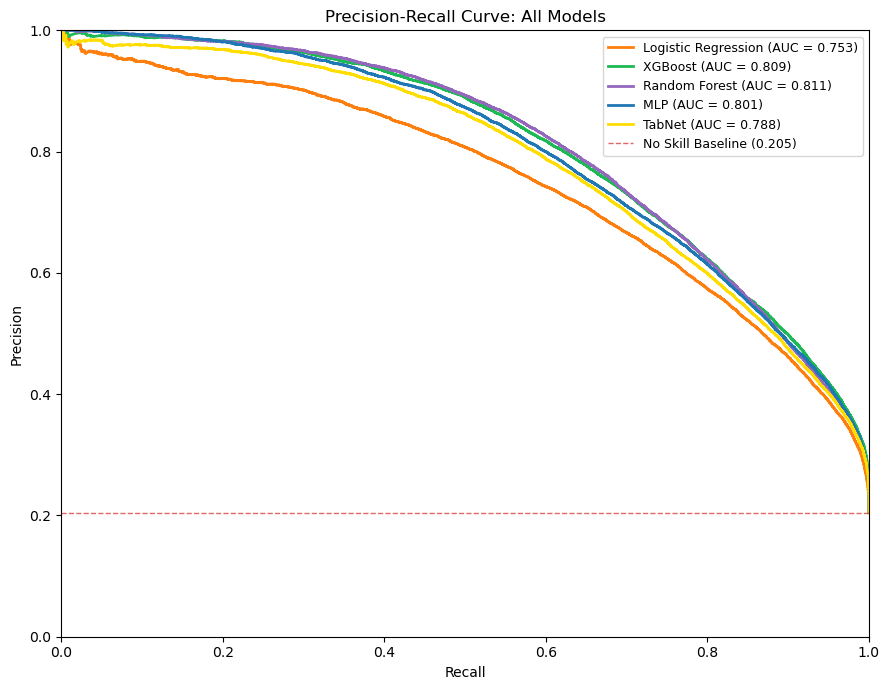

In [98]:
# Colors for PR and ROC curves: distinct colors for easy differentiation
graph_colors = {
    "Dummy":               "#D62728",  # red
    "Logistic Regression": "#FF7F0E",  # orange
    "TabNet":              "#FFDD00",  # yellow
    "MLP":                 "#1F77B4",  # blue
    "Random Forest":       "#9467BD",  # purple
    "XGBoost":             "#1DB954",  # Spotify green
}

# Exclude Dummy from PR curve
pr_curve_probas = {k: v for k, v in all_probas.items() if k != "Dummy"}

fig, ax = plt.subplots(figsize=(9, 7))

for model_name, proba in pr_curve_probas.items():
    precision, recall, _ = precision_recall_curve(y_test_np, proba)
    pr_auc = average_precision_score(y_test_np, proba)
    ax.plot(
        recall, precision,
        label=f"{model_name} (AUC = {pr_auc:.3f})",
        color=graph_colors[model_name],
        linewidth=2
    )

# No skill baseline
baseline = y_test_np.mean()
ax.axhline(
    y=baseline,
    color="#D62728",        # red to signal performance floor
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label=f"No Skill Baseline ({baseline:.3f})"
)

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall Curve: All Models")
ax.legend(fontsize=9, loc="upper right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig("pr_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

#### PR Curve Observations 
- All models maintain high precision at low recall, with precision beginning to drop as recall increases, reflecting the growing difficulty of identifying borderline hits.
- Random Forest and XGBoost are nearly indistinguishable throughout the curve, tracking closely together across all recall levels.
- MLP tracks closely with the tree-based models through mid-range recall but separates slightly at higher recall levels.
- TabNet sits below the tree-based models and MLP for most of the curve, consistent with its lower PR-AUC of 0.788.
- Logistic Regression is the most visibly separated from the top cluster, particularly in the mid-range recall region, before all models converge as recall approaches 1.0.
- All models remain well above the no skill baseline of 0.205 across the full recall range.

### 12.6 ROC Curve Comparison

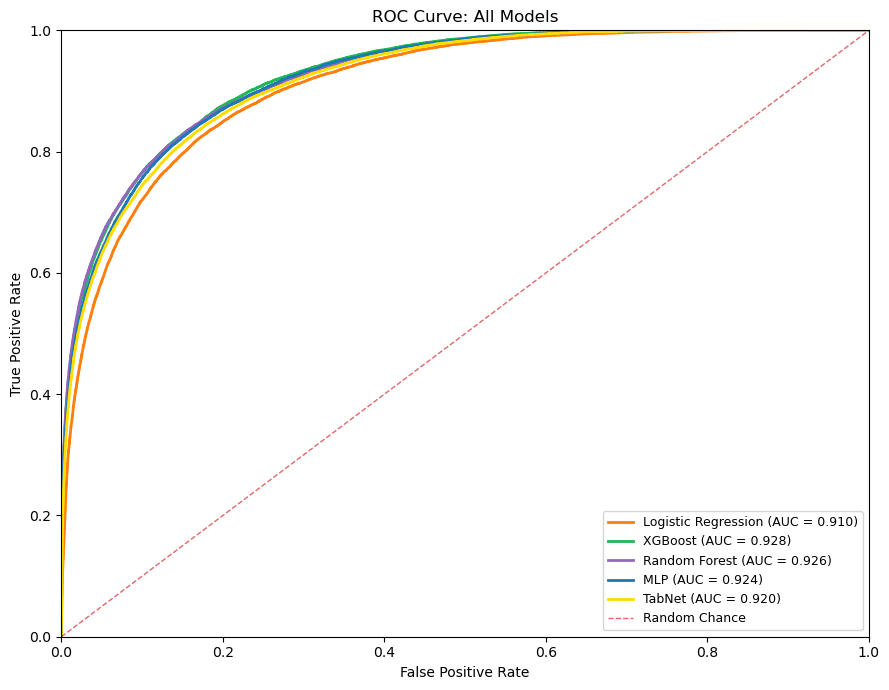

In [99]:
# Exclude Dummy from ROC curve as well
roc_curve_probas = {k: v for k, v in all_probas.items() if k != "Dummy"}

fig, ax = plt.subplots(figsize=(9, 7))

for model_name, proba in roc_curve_probas.items():
    fpr, tpr, _ = roc_curve(y_test_np, proba)
    roc_auc = roc_auc_score(y_test_np, proba)
    ax.plot(
        fpr, tpr,
        label=f"{model_name} (AUC = {roc_auc:.3f})",
        color=graph_colors[model_name],
        linewidth=2
    )

# Random chance baseline
ax.plot(
    [0, 1], [0, 1],
    color="#D62728",        # red to signal performance floor
    linestyle="--",
    linewidth=1,
    alpha=0.7,
    label="Random Chance"
)

ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve: All Models")
ax.legend(fontsize=9, loc="lower right")
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig("roc_curve_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

#### ROC Curve Observations 
- All models curve sharply upward at low false positive rates, indicating strong discriminative ability across the board and well above the random chance baseline.
- XGBoost and Random Forest are nearly indistinguishable, sitting at the top of the cluster with AUC scores of 0.928 and 0.926 respectively.
- MLP and TabNet track closely together through most of the curve, with AUC scores of 0.924 and 0.920.
- Logistic Regression is the most visibly separated from the top cluster, particularly in the low false positive rate region, consistent with its lower AUC of 0.910.
- All models converge as the false positive rate approaches 1.0, which is expected since every model eventually captures all true positives at the cost of all false positives.
- The tight clustering of the top four models confirms that ROC-AUC alone does not meaningfully differentiate between them, reinforcing PR-AUC as the more informative primary metric for this imbalanced dataset.

### 12.7 Model Selection
XGBoost was selected as the final model for the following reasons:

- **Performance**: XGBoost achieved a PR-AUC of 0.809, placing it within 0.002 of Random Forest (0.811) and ahead of all other models.
- **Training efficiency**: XGBoost hyperparameter tuning completed in approximately 40 minutes compared to over 9 hours for Random Forest, making it significantly more practical for iterative experimentation and future retraining.
- **Search space flexibility**: XGBoost's faster runtime allowed for a larger hyperparameter search (150 iterations, 5 folds) compared to Random Forest (8 iterations, 3 folds), suggesting its current results may not yet represent its true ceiling.
- **Scalability**: XGBoost's gradient boosting framework is well suited for large datasets and can be further optimized with additional tuning iterations.

### 12.8 Final Tuning
Given the marginal performance gap between XGBoost and Random Forest and XGBoost's substantial practical advantages, a final tuning run was conducted to determine whether additional iterations around the best parameters could close or eliminate the gap entirely.

#### 12.8.1 Hyperparameter Tuning
##### Define Parameter Space

In [100]:
xgb_param_distributions_v2 = {
    "model__n_estimators": [1800, 2500, 3000],        # more trees than v1; previous best was 1800, exploring higher
    "model__learning_rate": [0.05, 0.08, 0.1],        # shifted down from v1; more trees warrant smaller learning rate
    "model__max_depth": [10, 12, 15],                 # expanded upward from v1 best of 10; deeper trees may capture more complex patterns
    "model__min_child_weight": [1, 3],                # previous best was 1; testing slightly higher for regularization
    "model__gamma": [0.0, 0.1],                       # previous best was 0.1; narrowed around this value
    "model__subsample": [0.7, 0.8, 0.9],              # previous best was 0.8; searching around it
    "model__colsample_bytree": [0.5, 0.6, 0.7],       # previous best was 0.5; expanded slightly upward
    "model__reg_alpha": [0.05, 0.1, 0.5],             # previous best was 0.05; exploring slightly higher L1 regularization
    "model__reg_lambda": [3.0, 5.0, 8.0],             # previous best was 3.0; exploring higher L2 regularization
    "model__scale_pos_weight": [1.0],                 # locked in; no class weighting consistently outperformed weighted alternatives
    "preprocess__genre__max_features": [40000]        # locked in; best from previous tuning runs
}

##### Define CV Strategy

In [101]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

##### Configure `RandomizedSearchCV`


In [102]:
xgb_search_v2 = RandomizedSearchCV(
    estimator=xgb_pipeline_tuning,
    param_distributions=xgb_param_distributions_v2,
    n_iter=200,
    scoring="average_precision", # PR AUC
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    return_train_score=False
)

##### Run Hyperparameter Tuning and Log Results to MLflow

Due to the training time of approximately 382 minutes (~6.4 hours), the following cell has been commented out after the initial run. The tuned model is reloaded from the saved artifact in the following subsection.

In [103]:
'''with mlflow.start_run(run_name="xgb_random_search_tuning_v2"):
    mlflow.log_params({
        "model_name": "xgb",
        "split_type": "stratified",
        "search_type": "RandomizedSearchCV",
        "scoring": "average_precision",
        "cv_folds": 5,
        "n_iter": 200,
        "test_size": TEST_SIZE,
        "tfidf_min_df": GENRE_TFIDF_KW["min_df"],
        "tfidf_max_df": GENRE_TFIDF_KW["max_df"],
        "tfidf_ngram_range": str(GENRE_TFIDF_KW["ngram_range"]),
        "version": "v2_fine_tune"
    })
    start_time = time.time()
    xgb_search_v2.fit(X_train, y_train)
    end_time = time.time()
    tuning_minutes = (end_time - start_time) / 60
    mlflow.log_metric("tuning_minutes", float(tuning_minutes))
    print(f"Tuning took {tuning_minutes:.2f} minutes")

    best_xgb_model_v2 = xgb_search_v2.best_estimator_
    print("Best params:", xgb_search_v2.best_params_)
    mlflow.log_metric("best_cv_pr_auc", float(xgb_search_v2.best_score_))
    mlflow.log_params({f"best_{k}": v for k, v in xgb_search_v2.best_params_.items()})

    # Evaluate default threshold on validation
    val_default_df, val_default_details = evaluate_fitted_model(
        model=best_xgb_model_v2,
        X_eval=X_val,
        y_eval=y_val,
        threshold=DEFAULT_THRESHOLD,
        model_name="xgb_v2",
        split_name="val_default",
        verbose=True
    )
    row = val_default_df.iloc[0]
    mlflow.log_metrics({
        "val_pr_auc_default": float(row["pr_auc"]),
        "val_roc_auc_default": float(row["roc_auc"]),
        "val_weighted_f1_default": float(row["weighted_f1"]),
    })

    # Save local artifacts
    joblib.dump(xgb_search_v2, "xgb_random_search_v2.pkl")
    joblib.dump(best_xgb_model_v2, "xgb_best_model_v2.pkl")
    mlflow.log_artifact("xgb_random_search_v2.pkl")
    mlflow.log_artifact("xgb_best_model_v2.pkl")

    # Log CV results
    cv_results = pd.DataFrame(xgb_search_v2.cv_results_)
    cv_results.to_csv("xgb_cv_results_v2.csv", index=False)
    mlflow.log_artifact("xgb_cv_results_v2.csv")

    # Log model artifact
    mlflow.sklearn.log_model(
        sk_model=best_xgb_model_v2,
        name="xgb_tuned_model_v2",
        serialization_format="cloudpickle"
    )
    mlflow.set_tag("run_note", "XGBoost fine-tune v2: expanded grid around best params")'''

'with mlflow.start_run(run_name="xgb_random_search_tuning_v2"):\n    mlflow.log_params({\n        "model_name": "xgb",\n        "split_type": "stratified",\n        "search_type": "RandomizedSearchCV",\n        "scoring": "average_precision",\n        "cv_folds": 5,\n        "n_iter": 200,\n        "test_size": TEST_SIZE,\n        "tfidf_min_df": GENRE_TFIDF_KW["min_df"],\n        "tfidf_max_df": GENRE_TFIDF_KW["max_df"],\n        "tfidf_ngram_range": str(GENRE_TFIDF_KW["ngram_range"]),\n        "version": "v2_fine_tune"\n    })\n    start_time = time.time()\n    xgb_search_v2.fit(X_train, y_train)\n    end_time = time.time()\n    tuning_minutes = (end_time - start_time) / 60\n    mlflow.log_metric("tuning_minutes", float(tuning_minutes))\n    print(f"Tuning took {tuning_minutes:.2f} minutes")\n\n    best_xgb_model_v2 = xgb_search_v2.best_estimator_\n    print("Best params:", xgb_search_v2.best_params_)\n    mlflow.log_metric("best_cv_pr_auc", float(xgb_search_v2.best_score_))\n    mlf

##### Reload Tuned Model and Evaluate on Validation

In [104]:
xgb_search_v2 = joblib.load("xgb_random_search_v2.pkl")
best_xgb_model_v2 = joblib.load("xgb_best_model_v2.pkl")

print("Best params:", xgb_search_v2.best_params_)
print("Best CV PR-AUC:", xgb_search_v2.best_score_)

val_default_df, val_default_details = evaluate_fitted_model(
    model=best_xgb_model_v2,
    X_eval=X_val,
    y_eval=y_val,
    threshold=DEFAULT_THRESHOLD,
    model_name="xgb_v2",
    split_name="val_default",
    verbose=True
)

Best params: {'preprocess__genre__max_features': 40000, 'model__subsample': 0.9, 'model__scale_pos_weight': 1.0, 'model__reg_lambda': 3.0, 'model__reg_alpha': 0.05, 'model__n_estimators': 2500, 'model__min_child_weight': 1, 'model__max_depth': 12, 'model__learning_rate': 0.05, 'model__gamma': 0.1, 'model__colsample_bytree': 0.5}
Best CV PR-AUC: 0.8092143724503014
PR-AUC: 0.8148859390614911
ROC-AUC: 0.9297797179804008
Weighted F1: 0.8872929783392444
              precision  recall  f1-score     support
0                 0.909   0.961     0.934   84068.000
1                 0.805   0.626     0.705   21635.000
accuracy          0.893   0.893     0.893       0.893
macro avg         0.857   0.794     0.819  105703.000
weighted avg      0.888   0.893     0.887  105703.000
Confusion matrix:
 [[80797  3271]
 [ 8089 13546]]


##### Hyperparameter Tuning Observations
- Final tuning selected `n_estimators=2500`, `max_depth=12`, `learning_rate=0.05`, `subsample=0.9`, `colsample_bytree=0.5`, `min_child_weight=1`, `gamma=0.1`, `reg_alpha=0.05`, `reg_lambda=3.0`, and `scale_pos_weight=1.0`. The search favored a larger ensemble of deeper trees with a conservative learning rate, consistent with the general principle that more trees warrant smaller learning steps.
- PR-AUC of 0.815 indicates good ability to rank hits above non-hits, well above the 0.20 random baseline.
- ROC-AUC of 0.930 indicates exceptional overall separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.887 indicates the model performs very well at the default threshold of 0.5.
- Non-hit precision of 0.909 and recall of 0.961 are well balanced and strong, meaning the model correctly identifies the vast majority of non-hits with high accuracy.
- Hit precision of 0.805 and recall of 0.626 are moderately unbalanced. The model has good precision when predicting hits but only captures around 62.6% of actual hits at the default threshold, suggesting threshold tuning may help recover some hit recall.

#### 12.8.2 Decision Threshold Tuning


##### Run Decision Threshold Tuning and Log to MLflow

In [105]:
with mlflow.start_run(run_name="xgb_threshold_tuning_v2"):
    mlflow.log_params({
        "model_name": "xgb_v2",
        "tuning_type": "decision_threshold",
        "threshold_grid_start": 0.10,
        "threshold_grid_end": 0.90,
        "threshold_grid_step": 0.01,
        "selection_metric": "weighted_f1",
    })
    rows = []
    # Sweep on validation
    for t in THRESHOLDS:
        xgb_v2_thres_tuning_df, xgb_v2_thres_tuning_details = evaluate_fitted_model(
            model=best_xgb_model_v2,
            X_eval=X_val,
            y_eval=y_val,
            threshold=float(t),
            model_name="xgb_v2",
            split_name="val_threshold_tuning",
            verbose=False
        )
        rows.append(xgb_v2_thres_tuning_df.iloc[0].to_dict())
    xgb_v2_threshold_df = (
        pd.DataFrame(rows)
        .sort_values("weighted_f1", ascending=False)
        .reset_index(drop=True)
    )
    best_metric_row = xgb_v2_threshold_df.iloc[0]

    best_t = float(best_metric_row["threshold"])
    best_val_pr_auc = float(best_metric_row["pr_auc"])
    best_val_roc_auc = float(best_metric_row["roc_auc"])
    best_val_f1 = float(best_metric_row["weighted_f1"])
    print(f"Selected threshold: {best_t:.2f}")
    print(f"Best validation weighted F1: {best_val_f1:.6f}")

    # Evaluate final test at selected threshold
    xgb_v2_test_thres_tuning_df, xgb_v2_test_thres_tuning_details = evaluate_fitted_model(
        model=best_xgb_model_v2,
        X_eval=X_test,
        y_eval=y_test,
        threshold=best_t,
        model_name="xgb_v2",
        split_name="test_threshold_tuning",
        verbose=True
    )
    test_row = xgb_v2_test_thres_tuning_df.iloc[0]
    mlflow.log_param("selected_threshold", best_t)
    mlflow.log_metrics({
        "val_pr_auc_tuned": best_val_pr_auc,
        "val_roc_auc_tuned": best_val_roc_auc,
        "val_weighted_f1_tuned": best_val_f1,
        "test_pr_auc_tuned": float(test_row["pr_auc"]),
        "test_roc_auc_tuned": float(test_row["roc_auc"]),
        "test_weighted_f1_tuned": float(test_row["weighted_f1"]),
    })
    # Save and log sweep artifact
    xgb_v2_threshold_df.to_csv("xgb_v2_threshold_sweep.csv", index=False)
    mlflow.log_artifact("xgb_v2_threshold_sweep.csv")
    mlflow.set_tag("run_note", "XGBoost v2 decision threshold tuning")

Selected threshold: 0.41
Best validation weighted F1: 0.888426
PR-AUC: 0.811943515389153
ROC-AUC: 0.9285488519039231
Weighted F1: 0.8861098201405044
              precision  recall  f1-score     support
0                 0.920   0.941     0.930   84069.000
1                 0.748   0.682     0.714   21634.000
accuracy          0.888   0.888     0.888       0.888
macro avg         0.834   0.812     0.822  105703.000
weighted avg      0.885   0.888     0.886  105703.000
Confusion matrix:
 [[79107  4962]
 [ 6870 14764]]


##### Decision Threshold Tuning Observations
- PR-AUC of 0.812 indicates good ability to rank hits above non-hits, well above the 0.20 random baseline.
- ROC-AUC of 0.929 indicates exceptional overall separation between hits and non-hits across thresholds, though this remains optimistic due to the large negative class.
- Weighted F1 of 0.886 indicates the model performs very well at the selected threshold of 0.41.
- Non-hit precision of 0.920 and recall of 0.941 are both high and well balanced, meaning the model correctly identifies the vast majority of non-hits with high accuracy.
- Hit precision of 0.748 and recall of 0.682 are weaker than non-hit performance. The model captures 68.2% of actual hits and is correct 74.8% of the time when predicting a hit. The selected threshold of 0.41 is notably lower than the default of 0.50, suggesting the model was uncertain about a meaningful portion of songs in the 0.41 to 0.50 probability range, and lowering the threshold helped recover additional hit recall at a modest precision cost.

In [106]:
# Generate XGBoost v2 test probabilities
xgb_v2_proba_test = best_xgb_model_v2.predict_proba(X_test)[:, 1]

# Save
np.save("xgb_v2_test_proba.npy", xgb_v2_proba_test)
print("XGBoost v2 probabilities generated and saved!")

XGBoost v2 probabilities generated and saved!


#### 12.8.3 XGBoost v1 and XGBoost v2 Comparison
**XGBoost v1 vs v2 Post Decision Threshold Tuning**

| Metric | XGBoost v1 | XGBoost v2 |
|--------|------------|------------|
| PR-AUC | 0.809 | 0.812 |
| ROC-AUC | 0.928 | 0.929 |
| Weighted F1 | 0.886 | 0.886 |
| Non-hit Precision | 0.918 | 0.920 |
| Non-hit Recall | 0.945 | 0.941 |
| Hit Precision | 0.757 | 0.748 |
| Hit Recall | 0.671 | 0.682 |
| Threshold | 0.43 | 0.41 |
- PR-AUC improved marginally from 0.809 to 0.812, confirming that additional tuning extracted further signal from the data.
- ROC-AUC and Weighted F1 remained effectively unchanged, indicating overall model performance was already near its ceiling after v1.
- Non-hit precision improved slightly from 0.918 to 0.920, while non-hit recall decreased marginally from 0.945 to 0.941, a negligible tradeoff.
- The most meaningful change is in hit precision and recall. Hit precision decreased slightly from 0.757 to 0.748, while hit recall improved from 0.671 to 0.682. The lower selected threshold of 0.41 compared to v1's 0.43 reclassified songs with predicted probabilities between 0.41 and 0.42 as hits, recovering additional recall at a modest precision cost.
- The better model ultimately depends on the use case. Higher hit precision (v1) is preferable when false positives carry a high cost, such as in resource allocation decisions. Higher hit recall (v2) is preferable when missing actual hits is the greater concern, such as in discovery or recommendation contexts. For this project both versions are considered comparable, and v2 is selected as the final model based on a slight preference for capturing more hits.

### 12.9 Probability Calibration
Probability calibration assesses whether a model's predicted probabilities accurately reflect true outcome frequencies. A well calibrated model should assign a probability of 0.7 to a song only if approximately 70% of songs with that score are actually hits. A calibration curve plots mean predicted probability against the fraction of actual positives in each probability bin, with a perfectly calibrated model following the diagonal. XGBoost v2 is evaluated here to understand whether its predicted probabilities can be trusted as reliable confidence estimates beyond binary classification.

In [107]:
xgb_v2_proba_test = np.load("xgb_v2_test_proba.npy")

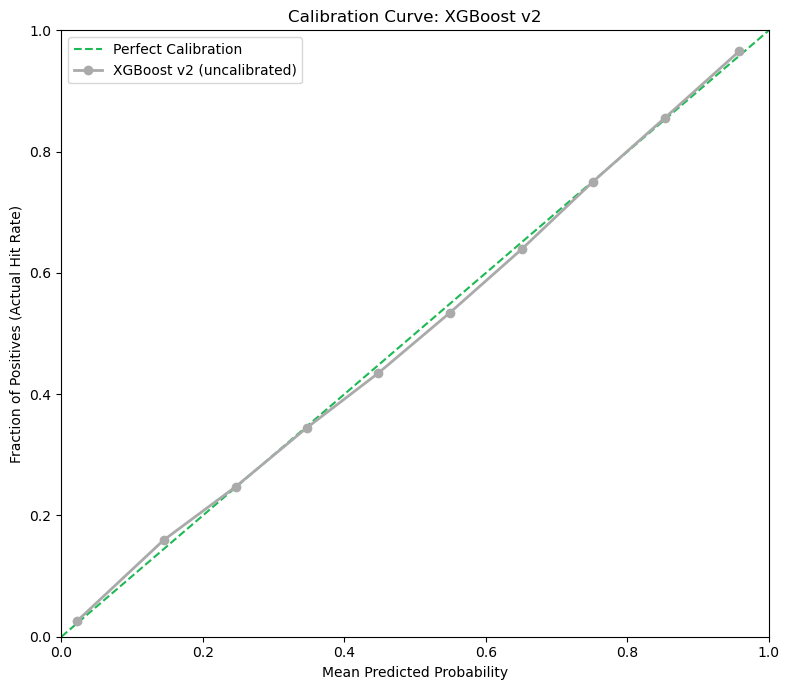

In [108]:
fig, ax = plt.subplots(figsize=(8, 7))

# Perfect calibration line
ax.plot([0, 1], [0, 1], linestyle="--", color="#1DB954", label="Perfect Calibration")

# XGBoost v2 calibration curve
fraction_of_positives, mean_predicted_value = calibration_curve(
    y_test_np,
    xgb_v2_proba_test,
    n_bins=10,
    strategy="uniform"
)

ax.plot(
    mean_predicted_value,
    fraction_of_positives,
    color="#AAAAAA",
    linewidth=2,
    marker="o",
    label="XGBoost v2 (uncalibrated)"
)

ax.set_xlabel("Mean Predicted Probability")
ax.set_ylabel("Fraction of Positives (Actual Hit Rate)")
ax.set_title("Calibration Curve: XGBoost v2")
ax.legend(fontsize=10)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig("calibration_curve_before.png", dpi=300, bbox_inches="tight")
plt.show()

**Observations**
- XGBoost v2 is exceptionally well calibrated, with predicted probabilities closely tracking the perfect calibration diagonal across the full probability range.
- At low predicted probabilities the model is slightly overconfident, assigning a small positive probability to songs that are overwhelmingly non-hits. This is a minor deviation and common in practice.
- At higher predicted probabilities the model remains well calibrated, with the curve staying close to the diagonal through the 0.8 to 0.9 range before converging at the top.
- Given the strong calibration, no post-hoc calibration adjustment such as Platt scaling or isotonic regression is necessary. The predicted probabilities can be interpreted directly as reliable confidence estimates.

### 12.10 Model Evaluation and Comparison Summary
- PR-AUC was used as the primary evaluation metric given the 80/20 class imbalance, with Weighted F1 serving as the secondary metric to capture overall classification performance at the selected threshold.
- Tree-based models outperformed both deep learning approaches and Logistic Regression across all metrics, with MLP and TabNet falling behind despite significantly longer training times.
- Given TabNet's underperformance relative to the broader model comparison, attention weight analysis was not pursued.
- Random Forest and XGBoost emerged as the strongest performers, achieving nearly identical PR-AUC scores of 0.811 and 0.809 respectively, with comparable performance across all other metrics.
- XGBoost was selected as the final model due to its comparable performance to Random Forest at a fraction of the training time, making it substantially more practical for iterative experimentation and future retraining.
- A final tuning run confirmed that additional improvement was possible, with PR-AUC increasing from 0.809 to 0.812 after an expanded search around the best parameters.
- The final choice between v1 and v2 depends on the deployment context. v1 offers slightly higher hit precision while v2 offers higher hit recall. XGBoost v2 was selected as the final model based on a preference for capturing more hits in discovery oriented contexts.
- Probability calibration confirmed that XGBoost v2's predicted probabilities closely track true hit rates across the full range, meaning the scores can be interpreted directly as reliable confidence estimates without further adjustment.

## 13. Model Interpretation
This section examines the behavior of XGBoost v2, the selected final model, to understand what it has learned and where it fails. Feature importance analysis is conducted using permutation importance and SHAP values to identify which signals drive predictions most strongly. Error analysis then investigates where the model struggles, with a focus on understanding systematic failure patterns rather than random noise. Together these analyses provide a fuller picture of model behavior beyond aggregate metrics.

### 13.1 Feature Importance
Understanding which features drive XGBoost v2's predictions is an important step in interpreting model behavior. Three approaches were explored: built-in gain importance, permutation importance, and SHAP values. 

Built-in gain importance was explored first but proved difficult to interpret in this context. Because genre is represented as a high-dimensional TF-IDF feature space, the gain scores were dominated by individual genre tokens such as "trance" and "progressive house" rather than reflecting the overall contribution of genre as a signal. This made it hard to draw meaningful conclusions about feature groups and the results are not included here.

Permutation importance was selected as the primary method because it operates on the raw input features before preprocessing, treating `genre_doc` as a single feature rather than thousands of individual tokens. This produces a much more interpretable view of which feature groups matter most. Importance is measured as the mean decrease in PR-AUC when each feature's values are randomly shuffled, with higher values indicating greater importance.

SHAP values are also included for the non-genre features to provide directional insight, showing not just how important each feature is, but whether higher values push predictions toward hits or away from them.

#### 13.1.1 Permutation Importance
Permutation importance measures how much a model's performance decreases when a feature's values are randomly shuffled, breaking any relationship between that feature and the target. A large drop in PR-AUC after shuffling indicates the feature carries meaningful signal, while a small drop suggests the model can perform well without it. This approach operates on raw input features before preprocessing, which is particularly useful here as it treats `genre_doc` as a single feature rather than thousands of individual TF-IDF tokens. Permutation importance is computed on the full test set of 105,703 tracks with 10 repeats per feature to produce stable estimates, using PR-AUC as the scoring metric consistent with the primary evaluation metric used throughout this project.

##### Compute Permutation Importance

In [109]:
perm = permutation_importance(
    best_xgb_model_v2,        
    X_test,
    y_test,
    n_repeats=10,                # shuffle each feature 10 times for stable estimates
    random_state=RANDOM_STATE,   # reproducibility
    n_jobs=-1,                   # use all available CPU cores
    scoring="average_precision"  # PR-AUC; consistent with primary evaluation metric
)

raw_feature_names = X_test.columns  # raw feature names before preprocessing

perm_df = (
    pd.DataFrame({
        "feature": raw_feature_names,
        "importance": perm.importances_mean,  # mean PR-AUC decrease across 10 repeats
        "std": perm.importances_std           # standard deviation across repeats; lower = more stable estimate
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(perm_df.head(20))

,feature,importance,std
0,release_year,0.322470,0.003335
1,artist_popularity_mean,0.208904,0.002562
2,genre_doc,0.148717,0.001054
3,log_artist_followers_mean,0.010581,0.000237
4,log_duration_min,0.006512,0.000266
5,loudness,0.004054,0.000181
6,artist_genres_max,0.003086,0.000276
7,instrumentalness,0.002953,0.000162
8,speechiness,0.002559,0.000267
9,danceability,0.002309,0.000225


##### Prepare Labels and Color Gradient

In [110]:
# Clean label map
perm_label_map = {
    "release_year": "Release Year",
    "artist_popularity_mean": "Artist Popularity (Mean)",
    "genre_doc": "Genre",
    "log_artist_followers_mean": "Artist Followers (Mean)",
    "log_duration_min": "Duration",
    "loudness": "Loudness",
    "liveness": "Liveness",
    "artist_genres_max": "Artist Genres (Max)",
    "danceability": "Danceability",
    "instrumentalness": "Instrumentalness",
    "acousticness": "Acousticness",
    "speechiness": "Speechiness",
    "log_n_artists": "Number of Artists",
    "valence": "Valence",
    "energy": "Energy",
    "tempo": "Tempo",
    "time_signature": "Time Signature",
    "has_genre_metadata": "Has Genre Metadata",
    "key": "Key",
    "mode": "Mode"
}

# Select top 5 and apply labels
plot_perm_df = perm_df.head(5).copy()
plot_perm_df["label"] = plot_perm_df["feature"].map(perm_label_map)
plot_perm_df = plot_perm_df.dropna(subset=["label"])

# Normalize permutation importance values for Spotify green color gradient
max_val = plot_perm_df["importance"].max()
min_val = plot_perm_df["importance"].min()

def get_color(val):
    ratio = (val - min_val) / (max_val - min_val)
    if ratio >= 0.75:
        return "#1DB954"   # highest impact
    elif ratio >= 0.50:
        return "#57C185"   # high impact
    elif ratio >= 0.25:
        return "#A8DFC0"   # moderate impact
    else:
        return "#DDEDE2"   # low impact

colors = [get_color(v) for v in plot_perm_df["importance"]]

##### Plot Top 5 Features by Permutation Importance

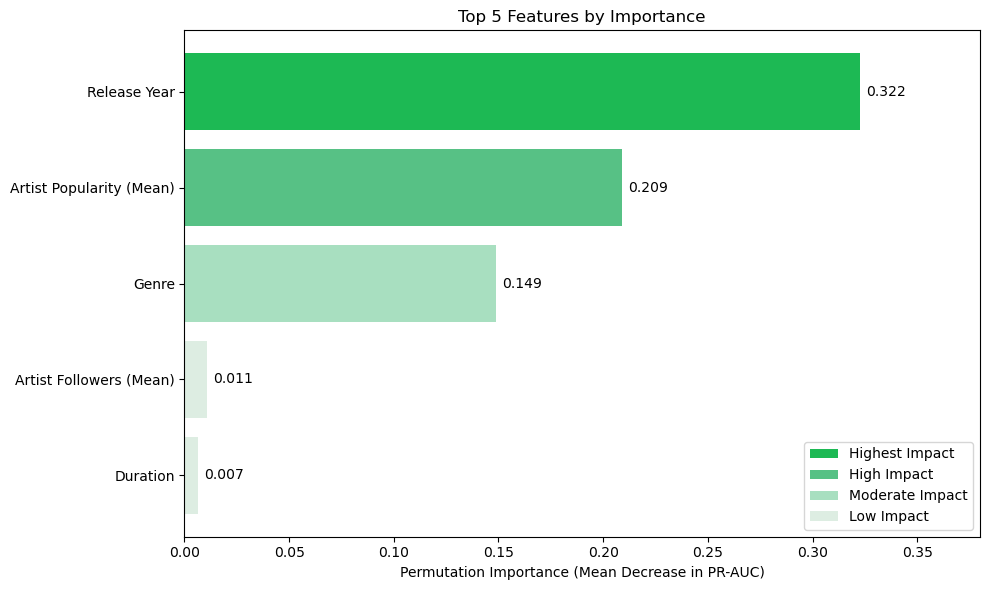

In [111]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    plot_perm_df["label"][::-1],
    plot_perm_df["importance"][::-1],
    color=colors[::-1]
)

# Annotate each bar with its value
for bar, val in zip(bars, plot_perm_df["importance"][::-1]):
    ax.text(
        bar.get_width() + 0.003,
        bar.get_y() + bar.get_height() / 2,
        f"{val:.3f}",
        va="center",
        ha="left",
        fontsize=10,
        color="#000000"
    )

ax.set_xlabel("Permutation Importance (Mean Decrease in PR-AUC)")
ax.set_title("Top 5 Features by Importance")
ax.set_xlim([0, 0.38])  # give room for annotations

legend_elements = [
    mpatches.Patch(facecolor="#1DB954", label="Highest Impact"),
    mpatches.Patch(facecolor="#57C185", label="High Impact"),
    mpatches.Patch(facecolor="#A8DFC0", label="Moderate Impact"),
    mpatches.Patch(facecolor="#DDEDE2", label="Low Impact")
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=10)

plt.tight_layout()
plt.savefig("permutation_importance_presentation.png", dpi=300, bbox_inches="tight")
plt.show()

##### Permutation Importance Observations
- Release year is by far the most important feature with a permutation importance of 0.322. The model relies heavily on release year as a proxy for popularity.
- Artist popularity mean is the second most important feature at 0.209, confirming that an artist's overall popularity is a strong predictor of whether an individual track becomes a hit, likely because popular artists have larger audiences and distribution advantages.
- Genre is third at 0.149, indicating that genre context adds meaningful signal beyond release year and artist popularity alone, even when treated as a single aggregated feature.
- There is a dramatic drop in importance after the top three features. Log artist followers drops to 0.011, and all remaining audio features fall below 0.005, suggesting that audio characteristics like danceability, energy, and tempo contribute relatively little to the model's predictions.
- The low importance of audio features is a notable finding. Despite being the most intuitive predictors of a song's appeal, they are largely overshadowed by contextual signals like release year and artist profile.
- Standard deviations are consistently low across all features, indicating that the importance estimates are stable and reliable across the 10 permutation repeats.

#### 13.1.2 SHAP
SHAP (SHapley Additive exPlanations) provides a more granular view of feature importance by assigning each feature a contribution value for every individual prediction. Unlike permutation importance which measures global feature impact, SHAP shows both the magnitude and direction of each feature's effect, indicating whether higher values push predictions toward hits or away from them. Because SHAP values become dominated by individual genre tokens when applied to the full feature space, the analysis is restricted to non-genre features to produce more interpretable results. A sample of 5,000 test observations is used for computational efficiency, which is sufficient for stable summary plots.

##### Prepare SHAP Data

In [112]:
# Extract and combine all feature names from preprocessing pipeline
# Required for mapping SHAP values back to interpretable feature names
preprocessor = best_xgb_model_v2.named_steps["preprocess"]

num_features = preprocessor.transformers_[0][2]                               # numeric features
cat_features = preprocessor.transformers_[1][1].get_feature_names_out(
    preprocessor.transformers_[1][2]                                          # categorical features
)
tfidf_features = preprocessor.transformers_[2][1].get_feature_names_out()     # genre TF-IDF features

all_feature_names = list(num_features) + list(cat_features) + list(tfidf_features)

print(f"Total features: {len(all_feature_names)}")

# Sample 5000 test observations for SHAP computation
# Full test set is too large for SHAP TreeExplainer to run efficiently
sample_idx = np.random.choice(len(X_test), size=5000, replace=False)
X_test_sample = X_test.iloc[sample_idx]

X_test_transformed = preprocessor.transform(X_test_sample)
if hasattr(X_test_transformed, "toarray"):
    X_test_transformed = X_test_transformed.toarray()

Total features: 3968


##### Compute SHAP Values

In [113]:
booster = best_xgb_model_v2.named_steps["model"].get_booster()
explainer = shap.TreeExplainer(booster)
shap_values = explainer.shap_values(X_test_transformed)

print("SHAP values computed! Shape:", shap_values.shape)

SHAP values computed! Shape: (5000, 3968)


##### Filter to Non-Genre Features and Plot SHAP Beeswarm

/var/folders/vw/dhc51d413kj_46yzm5569d740000gn/T/ipykernel_36856/1710635827.py:18: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


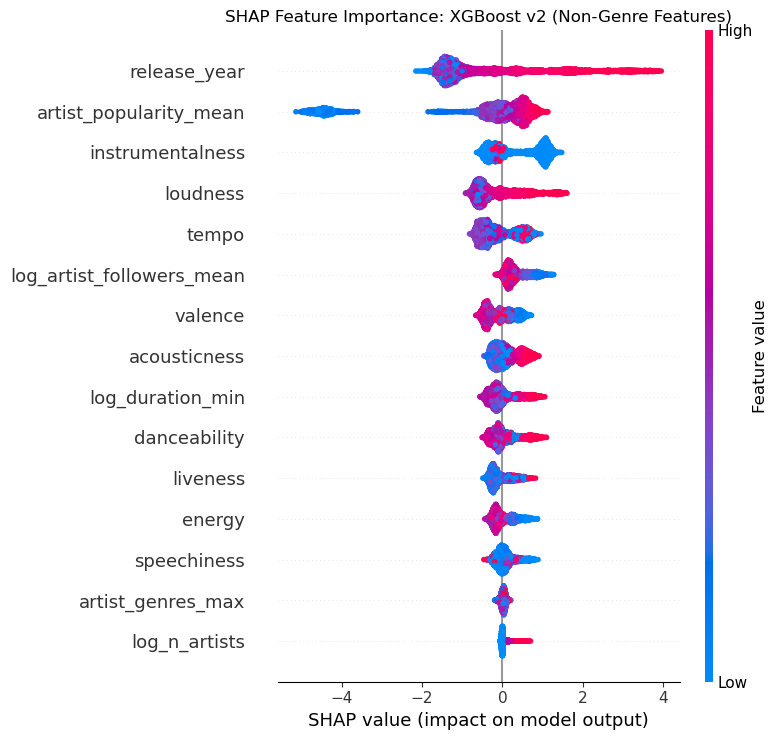

In [114]:
# Filter to non-genre features for cleaner plot
non_genre_features = [
    "release_year", "artist_popularity_mean", "log_artist_followers_mean",
    "danceability", "energy", "loudness", "acousticness", "instrumentalness",
    "speechiness", "valence", "tempo", "liveness", "log_duration_min",
    "log_n_artists", "artist_genres_max"
]

# Get indices of non-genre features
non_genre_idx = [i for i, f in enumerate(all_feature_names) if f in non_genre_features]

# Filter SHAP values and feature names
shap_values_filtered = shap_values[:, non_genre_idx]
X_test_filtered = X_test_transformed[:, non_genre_idx]
feature_names_filtered = [all_feature_names[i] for i in non_genre_idx]

# Plot
shap.summary_plot(
    shap_values_filtered,
    X_test_filtered,
    feature_names=feature_names_filtered,
    max_display=15,
    show=False
)

plt.title("SHAP Feature Importance: XGBoost v2 (Non-Genre Features)")
plt.tight_layout()
plt.savefig("shap_beeswarm_non_genre.png", dpi=300, bbox_inches="tight")
plt.show()

##### SHAP Observations 
- Release year has the strongest directional signal of all non-genre features. High values (recent tracks, red) push predictions strongly toward hits, with SHAP values extending beyond 4, while low values (older tracks, blue) push strongly away from hits. This reflects the temporal bias documented earlier where the model heavily associates recency with popularity.
- Artist popularity mean shows a clear asymmetric pattern. Very low values (blue cluster far left) create a strong negative pull on predictions, while high values (red) create a modest positive effect. Mid-range values vary around zero, suggesting artist popularity is more effective as a disqualifier for very unknown artists than as a strong positive signal.
- Instrumentalness shows a subtle directional effect. High values (red, more instrumental) have a small negative pull, while low values (blue, less instrumental) lean slightly positive, though the effect is modest and mixed enough that it is difficult to draw strong conclusions.
- Loudness shows that high values (red, louder tracks) push predictions positively toward hits, consistent with the trend of louder production in popular music.
- Most remaining audio features including tempo, valence, acousticness, danceability, liveness, energy and speechiness show tight distributions centered near zero, indicating limited directional impact compared to release year and artist context features.
- Log artist followers and log n artists both show modest positive SHAP values at lower feature values, suggesting these features contribute small positive effects at certain ranges but are not strong drivers of predictions overall.

### 13.2 Error Analysis

##### Reload Model and Probabilities

In [115]:
# Reload best model
best_xgb_model_v2 = joblib.load("xgb_best_model_v2.pkl")

# Reload probabilities
xgb_v2_proba_test = np.load("xgb_v2_test_proba.npy")

##### Generate Predictions and Identify Error Types

In [116]:
# Reload threshold sweep results to get selected threshold
xgb_v2_threshold_df = pd.read_csv("xgb_v2_threshold_sweep.csv")
xgb_v2_threshold = xgb_v2_threshold_df.loc[xgb_v2_threshold_df["weighted_f1"].idxmax(), "threshold"]

# Get predictions at selected threshold
y_pred_v2 = (xgb_v2_proba_test >= xgb_v2_threshold).astype(int)
y_test_np = np.asarray(y_test)

# Sanity check lengths
print(f"X_test length: {len(X_test)}, y_test length: {len(y_test_np)}")

# Identify error types
fn_mask = (y_test_np == 1) & (y_pred_v2 == 0)  # actual hits predicted as non-hits
fp_mask = (y_test_np == 0) & (y_pred_v2 == 1)  # actual non-hits predicted as hits
tp_mask = (y_test_np == 1) & (y_pred_v2 == 1)  # correctly identified hits
tn_mask = (y_test_np == 0) & (y_pred_v2 == 0)  # correctly identified non-hits

print(f"\nTotal hits in test set: {y_test_np.sum()}")
print(f"True positives (hits found): {tp_mask.sum()}")
print(f"True negatives (non-hits found): {tn_mask.sum()}")
print(f"False negatives (hits missed): {fn_mask.sum()}")
print(f"False positives (non-hits called hits): {fp_mask.sum()}")
print(f"\nFalse Negative rate: {fn_mask.sum() / y_test_np.sum():.1%}")

X_test length: 105703, y_test length: 105703

Total hits in test set: 21634
True positives (hits found): 14764
True negatives (non-hits found): 79107
False negatives (hits missed): 6870
False positives (non-hits called hits): 4962

False Negative rate: 31.8%


##### Extract Feature Values by Error Type

In [117]:
# Get the actual feature values for false negatives vs true positives
X_test_reset = X_test.reset_index(drop=True)

fn_df = X_test_reset[fn_mask].copy()
tp_df = X_test_reset[tp_mask].copy()
fp_df = X_test_reset[fp_mask].copy()
tn_df = X_test_reset[tn_mask].copy()

##### Compare Key Features Between Missed Hits and Found Hits

In [118]:
# Compare key features between missed hits and found hits
compare_features = [
    "release_year", "artist_popularity_mean", 
    "log_artist_followers_mean", "loudness",
    "danceability", "energy", "acousticness"
]

comparison_df = pd.DataFrame({
    "Found Hits (TP)": tp_df[compare_features].mean(),
    "Missed Hits (FN)": fn_df[compare_features].mean(),
    "Difference": fn_df[compare_features].mean() - tp_df[compare_features].mean()
}).round(3)

display(comparison_df)

,Found Hits (TP),Missed Hits (FN),Difference
release_year,2011.761,1994.238,-17.523
artist_popularity_mean,67.94,58.059,-9.881
log_artist_followers_mean,13.495,12.39,-1.105
loudness,-7.028,-9.293,-2.265
danceability,0.629,0.572,-0.057
energy,0.65,0.601,-0.049
acousticness,0.279,0.336,0.057


##### Visualize Found vs Missed Hits

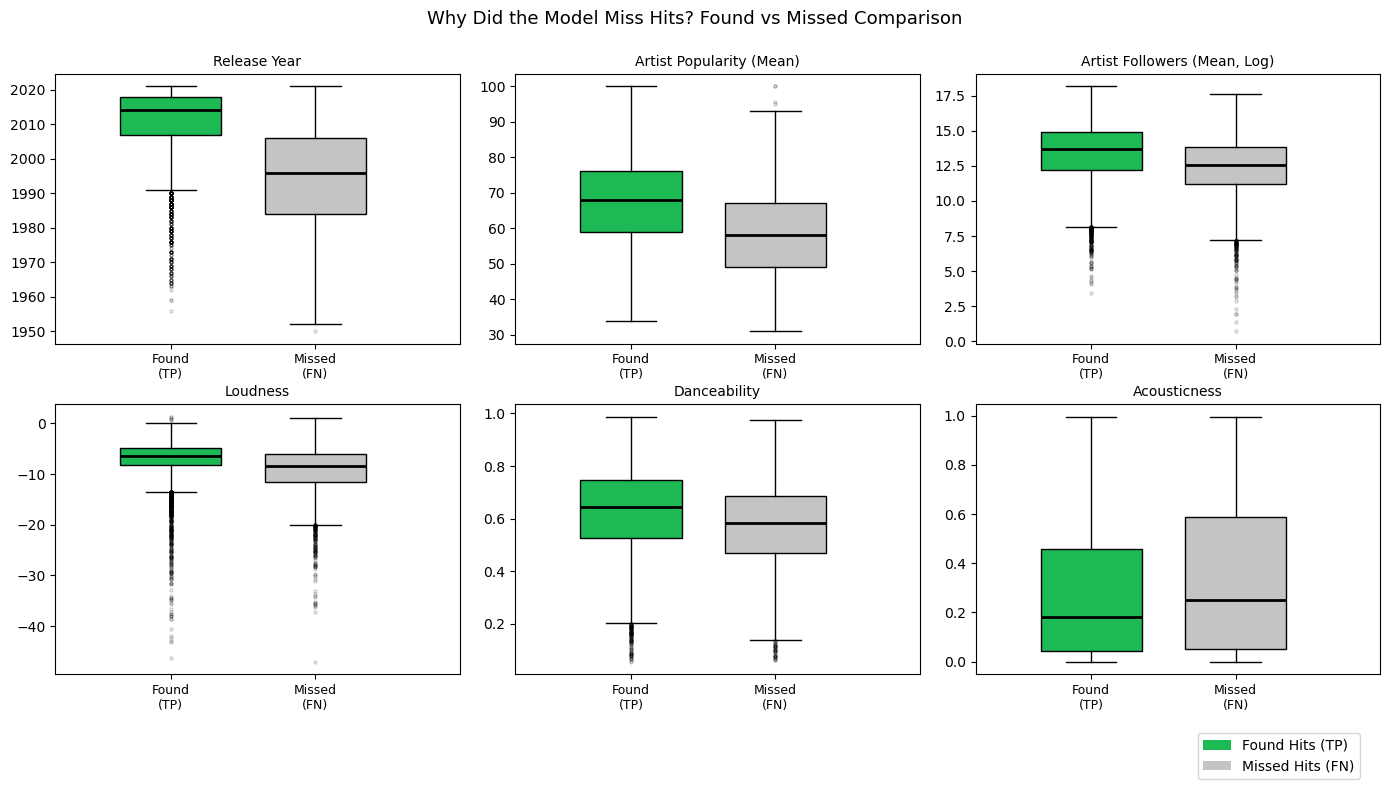

In [119]:
# Visualize False Negative Analysis
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

features_to_plot = [
    ("release_year", "Release Year"),
    ("artist_popularity_mean", "Artist Popularity (Mean)"),
    ("log_artist_followers_mean", "Artist Followers (Mean, Log)"),
    ("loudness", "Loudness"),
    ("danceability", "Danceability"),
    ("acousticness", "Acousticness"),
]

for ax, (feature, label) in zip(axes, features_to_plot):
    tp_vals = tp_df[feature].dropna()
    fn_vals = fn_df[feature].dropna()

    bp = ax.boxplot(
        [tp_vals, fn_vals],
        positions=[1, 1.5],
        widths=0.35,
        patch_artist=True,
        medianprops=dict(color="black", linewidth=2),
        whiskerprops=dict(color="black"),
        capprops=dict(color="black"),
        flierprops=dict(marker="o", color="black", alpha=0.2, markersize=2)
    )
    bp["boxes"][0].set_facecolor("#1DB954")
    bp["boxes"][1].set_facecolor("#C4C4C4")

    ax.set_title(label, fontsize=10)
    ax.set_xticks([1, 1.5])
    ax.set_xticklabels(["Found\n(TP)", "Missed\n(FN)"], fontsize=9)
    ax.set_xlim(0.6, 2.0)

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor="#1DB954", label="Found Hits (TP)"),
    Patch(facecolor="#C4C4C4", label="Missed Hits (FN)"),
]

plt.tight_layout()
plt.subplots_adjust(bottom=0.15,  top=0.9)  
fig.legend(handles=legend_elements, loc="lower right", bbox_to_anchor=(0.98, 0.01), fontsize=10)
fig.suptitle("Why Did the Model Miss Hits? Found vs Missed Comparison", fontsize=13)

plt.savefig("error_analysis_fn.png", dpi=300, bbox_inches="tight")
plt.show()

##### Visualize Hit Rates by Era

1950-1979: 1421 hits, 135 found, hit rate: 9.5%
1980-1999: 4034 hits, 1120 found, hit rate: 27.8%
2000-2009: 4843 hits, 3371 found, hit rate: 69.6%
2010-2021: 11336 hits, 10138 found, hit rate: 89.4%


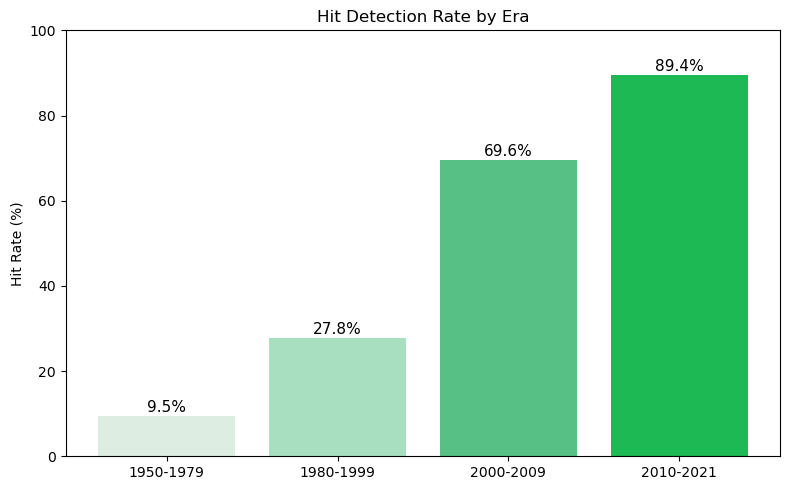

In [120]:
# Hit rates by era
eras = [(1950, 1979), (1980, 1999), (2000, 2009), (2010, 2021)]

eras_data = {}

for start, end in eras:
    era_mask = (X_test_reset["release_year"] >= start) & (X_test_reset["release_year"] <= end)
    era_hits = y_test_np[era_mask]
    era_preds = y_pred_v2[era_mask]
    
    total_hits = era_hits.sum()
    found_hits = ((era_hits == 1) & (era_preds == 1)).sum()
    hit_rate = (found_hits / total_hits * 100) if total_hits > 0 else 0
    
    era_label = f"{start}-{end}"
    eras_data[era_label] = round(hit_rate, 1)
    
    print(f"{era_label}: {total_hits} hits, {found_hits} found, hit rate: {hit_rate:.1f}%")

fig, ax = plt.subplots(figsize=(8, 5))  

bars = ax.bar(
    eras_data.keys(),
    eras_data.values(),
    color=["#DDEDE2", "#A8DFC0", "#57C185", "#1DB954"]
)

# Annotate bars
for bar, val in zip(bars, eras_data.values()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 1,
        f"{val}%",
        ha="center",
        fontsize=11,
        color="#000000"
    )

ax.set_ylabel("Hit Rate (%)")
ax.set_title("Hit Detection Rate by Era")
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig("miss_rate_by_era.png", dpi=300, bbox_inches="tight")
plt.show()

##### Error Analysis Observations
- The model misses 31.8% of actual hits (FN / total actual hits), with false negatives (6,870) outnumbering false positives (4,962), indicating the model is more likely to miss a hit than to incorrectly flag a non-hit.
- Comparing found hits and missed hits reveals a clear pattern. Missed hits are on average 17.5 years older, have lower artist popularity scores, are quieter, and are slightly less danceable and energetic, pointing to a systematic bias against older music.
- The era breakdown confirms this quantitatively. The model correctly identifies 89.4% of hits from 2010 to 2021, dropping to 69.6% for 2000 to 2009, 27.8% for 1980 to 1999, and just 9.5% for tracks from 1950 to 1979. The model is essentially unreliable for pre-1980 music.
- It is worth noting the distinction between songs that were hits at the time of release and songs that remain popular today. The model is predicting current streaming popularity, not historical chart performance. Older tracks in the dataset that score as hits likely represent songs with sustained or revived streaming relevance rather than a reflection of their original commercial success.
- The temporal bias is not a modeling failure but rather reflects what the model was trained to predict. Future work addressing this limitation is discussed in the limitations section.

### 13.3 Model Interpretation Summary
- Release year and artist popularity mean are the two most dominant predictors, accounting for the largest drops in PR-AUC when permuted. Genre follows as the third most important signal, while audio features contribute relatively little in comparison.
- The dominance of release year and artist context over audio features suggests the model is primarily learning who made the track and when, rather than what the track sounds like. This has important implications for the generalizability of the model.
- SHAP analysis confirms the directional relationships. Recent release years strongly push predictions toward hits, while older release years push strongly away. Very low artist popularity acts as a strong disqualifier, while high popularity has a modest positive effect. Most audio features show limited directional impact, clustering near zero SHAP values.
- Loudness is the most directionally meaningful audio feature, with higher loudness pushing predictions positively, consistent with modern production trends in popular music.
- Error analysis reveals a severe temporal bias. The model correctly identifies 89.4% of hits from 2010 to 2021 but only 9.5% of hits from 1950 to 1979, confirming it performs well on modern streaming era music and poorly on older tracks.
- The false negative rate of 31.8% is driven primarily by older, quieter, and less energetic tracks from artists with lower current popularity scores, suggesting the model conflates current streaming relevance with hit potential.
- Overall the model has learned a coherent and interpretable set of signals, but its effectiveness is largely bounded by the era of the music it is evaluating.

## 14. Limitations
- **Target variable definition**: A track is labeled a hit if its popularity score falls in the top 20% of the dataset. This threshold is an informed but ultimately arbitrary choice, and no universal industry definition of a hit exists. Different thresholds would yield different class distributions and potentially different model behavior.
- **Popularity score as a proxy**: Spotify's popularity score reflects streaming activity at a snapshot in time rather than historical chart performance. A track that was a genuine hit at release but has not maintained modern streaming relevance may be labeled as a non-hit, while a track that gained popularity through a recent revival or viral moment may be labeled as a hit regardless of its original reception.
- **Artist popularity and track popularity conflation**: Spotify's artist popularity score is partly derived from the popularity of an artist's tracks. This introduces potential circularity, where artist popularity may partially reflect the popularity of the very tracks being predicted.
- **Temporal bias**: Model performance varies significantly by era. The model correctly identifies 89.4% of hits from 2010 to 2021 but only 9.5% of hits from 1950 to 1979. This reflects the model learning patterns associated with modern streaming era music rather than timeless hit characteristics.
- **Dataset recency**: The dataset ends in 2021, limiting the model's ability to generalize to current music trends, evolving listener preferences, and new artists who have emerged since then.
- **Early experimentation not tracked**: Hyperparameter tuning runs conducted before MLflow was adopted are not reproducible from this notebook. Final search spaces were informed by these earlier runs but the full search history is not documented.
- **Genre representation**: Genre is represented through TF-IDF on genre tags, which treats genres as text tokens rather than structured hierarchical categories. This may not fully capture the nuanced relationships between genres and hit potential.

## 15. Conclusions and Future Work

### 15.1 Conclusions

This project set out to predict whether a Spotify track would be a hit, defined as falling in the top 20% of track popularity scores. The results demonstrate that meaningful predictive signal exists in the data, with the final XGBoost v2 model achieving a PR-AUC of 0.812 on the held-out test set, well above the 0.205 random baseline. However, several findings tempered what initially appeared to be strong performance.

Key conclusions from this project:

- **Hit prediction is genuinely difficult.** The arbitrary nature of the 20% popularity threshold, combined with a target variable that reflects a single point-in-time streaming snapshot rather than historical chart success, introduces fundamental noise into the prediction task. A more precise or tiered definition of hit status may yield cleaner results.
- **Tree-based models dominated.** XGBoost and Random Forest were the strongest performers across all metrics, outperforming both deep learning approaches and Logistic Regression. XGBoost was selected as the final model due to its comparable performance to Random Forest at a fraction of the training time.
- **MLP was the strongest deep learning model.** With proper tuning and the removal of class weighting, MLP came close to the tree-based models, demonstrating that well regularized feedforward networks can be competitive on clean tabular data.
- **TabNet did not justify its complexity.** Despite being purpose-built for tabular data, TabNet only marginally outperformed Logistic Regression, suggesting the dataset's clean and well structured features did not benefit from its attention mechanism.
- **The model is era-dependent.** Performance degrades significantly for older music, correctly identifying only 9.5% of hits from 1950 to 1979 compared to 89.4% for 2010 to 2021. Restricting the dataset to modern music would likely produce substantially better results.
- **Year-relative artist popularity features showed promise but were limited by multicollinearity.** Percentile and robust z-score versions of artist popularity relative to release year were engineered during EDA but dropped due to high correlation with the raw artist popularity mean, preventing a clean assessment of their independent contribution.
- **Artist context and recency dominate audio features.** Release year and artist popularity were the strongest predictors, with audio features contributing relatively little. This suggests the model is learning who made the track and when rather than what it sounds like.

### 15.2 Future Work

- **Temporal split evaluation**: Evaluate model performance using a temporal train/test split to better reflect real-world prediction, where the model would be trained on historical music and tested on future releases.
- **Modern music focus**: Restrict the dataset to tracks released after a certain year, such as 2000 or 2010, to reduce temporal bias and assess whether performance improves when the target variable is more consistent.
- **Artist popularity leakage analysis**: Remove or isolate artist popularity features to assess whether they introduce circularity and measure the true independent contribution of audio and genre signals.
- **Alternative hit definitions**: Explore tiered hit classifications such as mainstream, niche, and viral hits, or use chart appearance data as a more objective ground truth than the Spotify popularity score.
- **Temporal popularity analysis**: Investigate how track popularity changes over time to better distinguish between timeless hits, era-specific hits, and tracks with revived streaming relevance.
- **Year-relative artist popularity**: Revisit percentile and robust z-score versions of artist popularity relative to release year with more careful multicollinearity handling, such as variance inflation factor analysis or dimensionality reduction. These features may better capture era-adjusted artist prominence than raw popularity scores and could help reduce temporal bias.
- **Deployment as a scoring tool**: Deploy the final model as a scoring tool for evaluating new track releases, with a focus on recent music where the model performs most reliably.
- **Feature engineering for legacy music**: Develop features that better capture historical hit status for older tracks, such as chart history data or decade-level popularity normalization.